### Preprocessing labels to shrink them to create space between touching objects
Does not preserve the instances, automatically converts instance labels to semantic labels

Please use conda activate torch_env on SMohinta's Local PC: `Beast`

In [34]:
# Separate Script/Notebook for PREPROCESSING & SAVING

import zarr
import numpy as np
import os
import cv2
from tqdm import tqdm # For progress bar in Jupyter
try:
    from scipy.ndimage import binary_erosion, binary_fill_holes, zoom
except ImportError:
    print("Scipy not found. Some 3D preprocessing steps will be skipped or approximated in 2D.")

# --- Configuration for Preprocessing ---
ORIGINAL_DATA_ROOTS = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train"]
OUTPUT_PREPROCESSED_ROOT = "/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/preprocessed_train"
LABEL_TYPE = 'neuron' # 'neuron' or 'mito'

# Preprocessing parameters
APPLY_CLAHE = False
ERODE_LABELS_PIXELS = 2
FILL_HOLES_LABELS = True
# If you plan to train at a different resolution, specify target_resolution_nm here
# and apply it during preprocessing, saving the output at this resolution.
# For simplicity, if training at native resolution, this won't apply zoom.
ORIGINAL_RESOLUTION_NM = (8.0, 8.0, 8.0)
TARGET_RESOLUTION_NM_FOR_SAVE = (8.0, 8.0, 8.0) # E.g., if you want to save at 16nm^3 from 8nm^3

# Zarr chunking for output files (recommend matching patch_size or larger for efficiency)
OUTPUT_CHUNK_SIZE = (128, 128, 128) # Matching your patch size

# --- Preprocessing Functions (Re-used from EMDataset or adapted) ---
def _apply_clahe(image_data: np.ndarray):
    clahe = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8,8))
    if len(image_data.shape) == 3:
        clahe_processed_volume = np.zeros_like(image_data, dtype=np.float32)
        for z in range(image_data.shape[0]):
            temp_slice_uint8 = cv2.normalize(image_data[z,:,:], None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
            clahe_slice = clahe.apply(temp_slice_uint8)
            clahe_processed_volume[z,:,:] = clahe_slice.astype(np.float32)
        return clahe_processed_volume
    else:
        temp_image_uint8 = cv2.normalize(image_data, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
        return clahe.apply(temp_image_uint8).astype(np.float32)

def _apply_gaussian_blur(image_data: np.ndarray):
    if len(image_data.shape) == 3:
        processed_image = np.zeros_like(image_data)
        for z in range(image_data.shape[0]):
            processed_image[z,:,:] = cv2.GaussianBlur(src=image_data[z,:,:], ksize=(3,3), sigmaX=0.5)
        return processed_image
    else:
        return cv2.GaussianBlur(src=image_data, ksize=(3,3), sigmaX=0.5)

def _apply_erosion(label_data_binary: np.ndarray, pixels: int):
    if pixels <= 0: return label_data_binary
    try:
        return binary_erosion(label_data_binary, iterations=pixels).astype(np.int8)
    except NameError: # scipy.ndimage not imported
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (pixels * 2 + 1, pixels * 2 + 1))
        if len(label_data_binary.shape) == 3:
            eroded_volume = np.zeros_like(label_data_binary)
            for z in range(label_data_binary.shape[0]):
                eroded_volume[z, :, :] = cv2.erode(label_data_binary[z, :, :], kernel, iterations=1)
            return eroded_volume
        else:
            return cv2.erode(label_data_binary, kernel, iterations=1)

def _apply_hole_filling(label_data_binary: np.ndarray):
    try:
        return binary_fill_holes(label_data_binary).astype(np.int8)
    except NameError:
        if len(label_data_binary.shape) == 3:
            filled_volume = np.zeros_like(label_data_binary)
            for z in range(label_data_binary.shape[0]):
                filled_volume[z, :, :] = cv2.morphologyEx(label_data_binary[z, :, :], cv2.MORPH_CLOSE, np.ones((5,5),np.uint8))
            return filled_volume
        else:
            return cv2.morphologyEx(label_data_binary, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8))

def _apply_resampling(data: np.ndarray, current_res: tuple, target_res: tuple, is_label: bool):
    if current_res == target_res: return data

    scale_factors = (target_res[0] / current_res[0], target_res[1] / current_res[1], target_res[2] / current_res[2])
    new_shape = (int(data.shape[0] * scale_factors[0]), int(data.shape[1] * scale_factors[1]), int(data.shape[2] * scale_factors[2]))
    
    try:
        order = 0 if is_label else 1 # Nearest for labels, linear for images
        return zoom(data, scale_factors, order=order).astype(data.dtype)
    except NameError:
        print("Warning: Scipy not found for 3D resampling. Approximating with 2D slice-by-slice resizing.")
        resized_volume = np.zeros(new_shape, dtype=data.dtype)
        interp_method = cv2.INTER_NEAREST if is_label else cv2.INTER_AREA
        for z_idx in range(new_shape[0]):
            original_z_idx = int(z_idx / scale_factors[0])
            if original_z_idx < data.shape[0]:
                resized_slice = cv2.resize(data[original_z_idx,:,:], (new_shape[2], new_shape[1]), interpolation=interp_method)
                resized_volume[z_idx,:,:] = resized_slice
        return resized_volume

# --- Main Preprocessing Loop ---
print("Starting preprocessing and saving of Zarr files...")
os.makedirs(OUTPUT_PREPROCESSED_ROOT, exist_ok=True)

all_zarr_paths = []
for dir_path in ORIGINAL_DATA_ROOTS:
    all_zarr_paths.extend(glob.glob(os.path.join(dir_path, '*.zarr')))
    all_zarr_paths.extend([d for d in glob.glob(os.path.join(dir_path, '*')) if os.path.isdir(d) and '.zarr' not in d])

for zarr_path in tqdm(all_zarr_paths, desc="Processing Zarr Volumes"):
    try:
        original_zarr_group = zarr.open(zarr_path, mode='r')
        raw_array = original_zarr_group['volumes/raw']
        label_array = original_zarr_group[f'volumes/labels/{LABEL_TYPE}_ids']

        volume_name = os.path.basename(zarr_path)
        output_zarr_path = os.path.join(OUTPUT_PREPROCESSED_ROOT, volume_name)
        
        print(f"\nProcessing {volume_name}...")

        # Create output Zarr group
        output_zarr_group = zarr.open_group(output_zarr_path, mode='w')

        # Process and save RAW image data
        print("  Processing raw image data...")
        processed_image_volume = raw_array[:].astype(np.float32) # Load whole volume into memory for full processing

        if APPLY_CLAHE:
            processed_image_volume = _apply_clahe(processed_image_volume)
        processed_image_volume = _apply_gaussian_blur(processed_image_volume)
        processed_image_volume = (processed_image_volume - 127.5) / 127.5 # Normalize to [-1, 1]
        processed_image_volume = _apply_resampling(processed_image_volume, ORIGINAL_RESOLUTION_NM, TARGET_RESOLUTION_NM_FOR_SAVE, is_label=False)
        
        output_zarr_group.create_dataset('volumes/raw', 
                                         data=processed_image_volume, 
                                         chunks=OUTPUT_CHUNK_SIZE, 
                                         dtype=processed_image_volume.dtype, 
                                         compressor=zarr.Blosc())
        print("  Raw image data saved.")

        # Process and save LABEL data
        print("  Processing label data (instance-aware erosion)...")
        # Load whole label volume into memory (if feasible)
        original_label_volume_uint64 = label_array[:] 
        
        # Initialize an empty semantic mask for the output
        processed_label_volume_semantic = np.zeros(original_label_volume_uint64.shape, dtype=np.int8)

        # --- INSTANCE-AWARE EROSION ---
        # Iterate through each unique instance ID (excluding 0 for background)
        unique_instance_ids = np.unique(original_label_volume_uint64)
        unique_instance_ids = unique_instance_ids[unique_instance_ids != 0] # Remove background ID

        if ERODE_LABELS_PIXELS > 0 and len(unique_instance_ids) > 0:
            print(f"    Applying {ERODE_LABELS_PIXELS}-pixel erosion to {len(unique_instance_ids)} instances.")
            for instance_id in tqdm(unique_instance_ids, desc="Eroding instances"):
                # Create a binary mask for the current instance only
                instance_mask = (original_label_volume_uint64 == instance_id).astype(np.int8)
                
                # Erode the individual instance mask
                eroded_instance_mask = _apply_erosion(instance_mask, ERODE_LABELS_PIXELS)
                
                # Add the eroded instance back to the semantic volume.
                # Use OR operation to avoid overwriting if instances overlap after erosion (though unlikely)
                # or if an instance erodes into another.
                processed_label_volume_semantic = np.maximum(processed_label_volume_semantic, eroded_instance_mask)
        else:
            # If no erosion, just binarize directly
            processed_label_volume_semantic = (original_label_volume_uint64 != 0).astype(np.int8)
            if ERODE_LABELS_PIXELS <=0:
                print("    Skipping instance erosion (erode_labels_pixels <= 0).")
        
        # --- Hole Filling (applied to the combined semantic mask after optional erosion) ---
        if FILL_HOLES_LABELS:
            print("    Applying hole filling...")
            processed_label_volume_semantic = _apply_hole_filling(processed_label_volume_semantic)
        else:
            print("    Skipping hole filling (fill_holes_labels is False).")

        # --- Resampling (applied to the final semantic mask) ---
        processed_label_volume_semantic = _apply_resampling(
            processed_label_volume_semantic, ORIGINAL_RESOLUTION_NM, TARGET_RESOLUTION_NM_FOR_SAVE, is_label=True
        )

        output_zarr_group.create_dataset(f'volumes/labels/{LABEL_TYPE}_ids', 
                                         data=processed_label_volume_semantic, 
                                         chunks=OUTPUT_CHUNK_SIZE, 
                                         dtype=processed_label_volume_semantic.dtype, 
                                         compressor=zarr.Blosc())
        print("  Label data saved.")

    except Exception as e:
        print(f"Error processing volume {zarr_path}: {e}")

print("\nPreprocessing and saving complete.")

# --- AFTER RUNNING THIS SCRIPT ---
# You would then change your train.py (or Jupyter args for training) to point to:
# self.train_zarr_dirs = [OUTPUT_PREPROCESSED_ROOT]
# self.clahe = False # Since CLAHE is already applied and saved
# self.erode_labels_pixels = 0 # Since erosion is already applied and saved
# self.fill_holes_labels = False # Since hole filling is already applied and saved

Starting preprocessing and saving of Zarr files...



Processing Zarr Volumes:   0%|                            | 0/5 [00:00<?, ?it/s]


Processing hemi_x11051_y20992_z21948_C.zarr...
  Processing raw image data...
  Raw image data saved.
  Processing label data (instance-aware erosion)...
    Applying 2-pixel erosion to 86 instances.




Eroding instances:   0%|                                 | 0/86 [00:00<?, ?it/s]

Eroding instances:   1%|▎                        | 1/86 [00:00<01:08,  1.24it/s]

Eroding instances:   2%|▌                        | 2/86 [00:01<01:06,  1.27it/s]

Eroding instances:   3%|▊                        | 3/86 [00:02<01:04,  1.28it/s]

Eroding instances:   5%|█▏                       | 4/86 [00:03<01:03,  1.29it/s]

Eroding instances:   6%|█▍                       | 5/86 [00:03<01:02,  1.29it/s]

Eroding instances:   7%|█▋                       | 6/86 [00:04<01:02,  1.29it/s]

Eroding instances:   8%|██                       | 7/86 [00:05<01:01,  1.29it/s]

Eroding instances:   9%|██▎                      | 8/86 [00:06<01:00,  1.29it/s]

Eroding instances:  10%|██▌                      | 9/86 [00:06<00:59,  1.29it/s]

Eroding instances:  12%|██▊                     | 10/86 [00:07<00:58,  1.30it/s]

Eroding instances:  13%|███                     | 11/86 [00:08<00:57,  1.30it/s]

Eroding instan

    Applying hole filling...


...

  Label data saved.

Processing hemi_x11051_y22016_z21948_C.zarr...
  Processing raw image data...
  Raw image data saved.
  Processing label data (instance-aware erosion)...
    Applying 2-pixel erosion to 76 instances.




Eroding instances:   0%|                                 | 0/76 [00:00<?, ?it/s]

Eroding instances:   1%|▎                        | 1/76 [00:00<01:00,  1.24it/s]

Eroding instances:   3%|▋                        | 2/76 [00:01<00:57,  1.28it/s]

Eroding instances:   4%|▉                        | 3/76 [00:02<00:56,  1.29it/s]

Eroding instances:   5%|█▎                       | 4/76 [00:03<00:55,  1.30it/s]

Eroding instances:   7%|█▋                       | 5/76 [00:03<00:54,  1.30it/s]

Eroding instances:   8%|█▉                       | 6/76 [00:04<00:53,  1.30it/s]

Eroding instances:   9%|██▎                      | 7/76 [00:05<00:53,  1.29it/s]

Eroding instances:  11%|██▋                      | 8/76 [00:06<00:52,  1.30it/s]

Eroding instances:  12%|██▉                      | 9/76 [00:06<00:51,  1.30it/s]

Eroding instances:  13%|███▏                    | 10/76 [00:07<00:50,  1.30it/s]

Eroding instances:  14%|███▍                    | 11/76 [00:08<00:50,  1.30it/s]

Eroding instan

    Applying hole filling...



Processing Zarr Volumes: 100%|████████████████████| 5/5 [06:38<00:00, 79.73s/it]

  Label data saved.

Preprocessing and saving complete.


### Scripts for data loading, visualization, training and inference

In [1]:
import numpy as np
import torch
import glob
import cv2
import tifffile as tff # For reading TIFF files if any raw data is in TIFF
import nibabel as nib # For reading NIfTI files if any raw data is in NIfTI
import os
import zarr # Import zarr library
from typing import List, Tuple
from tqdm import tqdm

class EMDataset(torch.utils.data.Dataset):
    """
    A PyTorch Dataset for loading 3D EM volumes and their labels from Zarr files on-demand.
    Supports multiple Zarr files across directories, random patch extraction,
    and on-the-fly preprocessing including optional downsampling.
    """
    def __init__(self,
                 zarr_data_dirs: List[str],
                 label_type: str, # 'neuron' or 'mito'
                 patch_size: Tuple[int, int, int] = (32, 32, 32), # Isotropic patch size (Z, Y, X)
                 stride: Tuple[int, int, int] = (16, 16, 16),      # Isotropic stride (Z, Y, X)
                 subsample_frac: float = 1.0,
                 subsample_number: int = 0,
                 seed: int = 27,
                 clahe: bool = True,
                 original_resolution_nm: Tuple[float, float, float] = (8.0, 8.0, 8.0), # Native resolution of raw data (Z, Y, X)
                 target_resolution_nm: Tuple[float, float, float] = (8.0, 8.0, 8.0),  # Resolution to process/train at (Z, Y, X)
                 balance_patches: bool = True, # New parameter to enable balancing
                 min_positive_pixels: int = 100, # Minimum number of positive pixels for a patch to be considered 'positive'
                 expect_labels: bool = True #Set to False for inference without labels
                ):
        
        self.zarr_data_dirs = zarr_data_dirs
        self.label_type = label_type
        self.patch_size = patch_size
        self.stride = stride
        self.clahe_enabled = clahe
        self.original_resolution_nm = original_resolution_nm
        self.target_resolution_nm = target_resolution_nm
        self.expect_labels = expect_labels # Store the new parameter

        
        if self.clahe_enabled:
            self.clahe = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8,8))

        self._volume_metadata = [] # Stores info about each Zarr volume
        self._patch_global_indices = [] # (volume_idx, z_start_eff, y_start_eff, x_start_eff)

        # Discover all Zarr files and collect their metadata
        print("Discovering Zarr volumes...")
        for dir_path in self.zarr_data_dirs:
            # Assuming each subdirectory or .zarr file is a separate volume
            # glob.glob can be adjusted based on your exact directory structure
            zarr_paths = glob.glob(os.path.join(dir_path, '*.zarr')) # Assumes .zarr extension
            zarr_paths.extend([d for d in glob.glob(os.path.join(dir_path, '*')) if os.path.isdir(d) and '.zarr' not in d]) # Handles dir as zarr

            for zarr_path in zarr_paths:
                try:
                    temp_zarr_group = zarr.open(zarr_path, mode='r')

                    # Open Zarr to get shape, but don't hold the handle for multiprocessing safety
                    # Always check for 'volumes/raw'
                    if 'volumes/raw' not in temp_zarr_group:
                        raise KeyError("'volumes/raw' not found in Zarr group.")
                    raw_array_shape = temp_zarr_group['volumes/raw'].shape
                    
                    label_key_found = None
                    if self.expect_labels: # Only check for labels if expected
                        expected_label_key = f'volumes/labels/{self.label_type}_ids'
                        if expected_label_key not in temp_zarr_group:
                            raise KeyError(f"'{expected_label_key}' not found in Zarr group, but expect_labels is True.")
                        label_key_found = expected_label_key

                    self._volume_metadata.append({
                        'zarr_path': zarr_path,
                        'raw_key': 'volumes/raw',
                        'label_key': label_key_found, # Store None if labels not expected
                        'shape': raw_array_shape,
                        'zarr_handle': None
                    })
                    print(f"Found Zarr volume: {zarr_path} with shape {raw_array_shape}")
                except Exception as e:
                    print(f"Warning: Could not process {zarr_path}. Skipping. Error: {e}")
        
        if not self._volume_metadata:
            raise ValueError("No valid Zarr volumes found or accessible. Check paths and Zarr structure.")

        # Generate all possible patch indices across all volumes
        print("Calculating all possible patch indices...")
        for volume_idx, metadata in enumerate(self._volume_metadata):
            volume_patches = self._calculate_patches_for_volume(
                volume_shape=metadata['shape'],
                patch_size=self.patch_size,
                stride=self.stride,
                original_res=self.original_resolution_nm,
                target_res=self.target_resolution_nm
            )
            # Add volume_idx to each patch tuple
            self._patch_global_indices.extend([(volume_idx,) + p for p in volume_patches])
        
        # Apply subsampling if specified
        n_total_patches = len(self._patch_global_indices)
        if subsample_frac != 1.0 or subsample_number != 0:
            np.random.seed(seed)
            if subsample_frac != 1.0:
                num_to_select = int(np.floor(subsample_frac * n_total_patches))
                indices = np.random.choice(np.arange(n_total_patches), size=num_to_select, replace=False)
                self._patch_global_indices = [self._patch_global_indices[i] for i in indices]
            
            if subsample_number != 0:
                n_current_patches = len(self._patch_global_indices)
                num_to_select = min(subsample_number, n_current_patches)
                indices = np.random.choice(np.arange(n_current_patches), size=num_to_select, replace=False)
                self._patch_global_indices = [self._patch_global_indices[i] for i in indices]
            print(f"Subsampled to {len(self._patch_global_indices)} patches.")

        print(f"Dataset initialized with {len(self._patch_global_indices)} total patches.")
        
        # After self._patch_global_indices is populated and subsampled:
        self.balance_patches = balance_patches
        self.min_positive_pixels = min_positive_pixels
        self.patch_weights = None # Will store weights for WeightedRandomSampler

        # Only calculate patch positivity if labels are expected AND balancing is enabled
        if self.expect_labels and self.balance_patches: 
            print("Calculating patch positivity for balanced sampling...")
            self._calculate_patch_positivity() # This method relies on labels being present
            print("Patch positivity calculation complete.")
        elif self.balance_patches:
            print("Warning: Patch balancing is enabled but expect_labels is False. Balancing will be skipped.")
            
    def _calculate_patch_positivity(self):
        """
        Iterates through the dataset (without loading full patches into memory)
        to determine which patches contain positive labels.
        This will be used to generate weights for WeightedRandomSampler.
        It's only called if self.expect_labels is True and self.balance_patches is True.
        """
        positive_patch_indices = []
        negative_patch_indices = []

        # Temporarily store Zarr handles to avoid re-opening constantly during this pass
        # This is safe because this method is called once in __init__ before multiprocessing starts
        zarr_handles = [zarr.open(meta['zarr_path'], mode='r') for meta in self._volume_metadata]

        for i, (volume_idx, z_start_eff, y_start_eff, x_start_eff) in tqdm(enumerate(self._patch_global_indices), total=len(self._patch_global_indices)):
            metadata = self._volume_metadata[volume_idx]
            label_key = metadata['label_key']
            raw_volume_shape = metadata['shape']

            label_array = zarr_handles[volume_idx][label_key]

            # Calculate raw data coordinates for slicing
            scale_z_inv = self.original_resolution_nm[0] / self.target_resolution_nm[0]
            scale_y_inv = self.original_resolution_nm[1] / self.target_resolution_nm[1]
            scale_x_inv = self.original_resolution_nm[2] / self.target_resolution_nm[2]

            z_start_raw = int(z_start_eff * scale_z_inv)
            y_start_raw = int(y_start_eff * scale_y_inv)
            x_start_raw = int(x_start_eff * scale_x_inv)

            z_end_raw = int((z_start_eff + self.patch_size[0]) * scale_z_inv)
            y_end_raw = int((y_start_eff + self.patch_size[1]) * scale_y_inv)
            x_end_raw = int((x_start_eff + self.patch_size[2]) * scale_x_inv)

            # Ensure indices are within raw volume bounds
            z_end_raw = min(z_end_raw, raw_volume_shape[0])
            y_end_raw = min(y_end_raw, raw_volume_shape[1])
            x_end_raw = min(x_end_raw, raw_volume_shape[2])

            # Load only the label patch to check for positive pixels
            # Using .sum() on the boolean array is efficient for checking counts
            # We explicitly load as numpy to avoid Dask overhead if not needed, or
            # use .compute() if `label_array` is a Dask array.
            label_patch = label_array[z_start_raw:z_end_raw, y_start_raw:y_end_raw, x_start_raw:x_end_raw]

            # --- CRITICAL CHANGE FOR uint64 LABELS ---
            # Count positive pixels: simply count all non-zero pixels.
            # No need for float conversion or 0.5 threshold here.
            num_positive_in_patch = np.sum(label_patch != 0) # Count all non-zero pixels
            
            if num_positive_in_patch >= self.min_positive_pixels:
                positive_patch_indices.append(i)
            else:
                negative_patch_indices.append(i)

        if not positive_patch_indices:
            print("Warning: No positive patches found based on min_positive_pixels threshold.")
            self.patch_weights = torch.ones(len(self._patch_global_indices), dtype=torch.double)
            return

        print(f"Found {len(positive_patch_indices)} positive patches and {len(negative_patch_indices)} negative patches.")

        # --- CORRECTED WEIGHT ASSIGNMENT FOR PRIORITIZING LABELED PATCHES ---
        # Goal: Make sure batches contain more patches with actual labels.
        # This means patches with labels (positive_patch_indices) should have a HIGHER weight.
        # Patches with only background (negative_patch_indices) should have a LOWER weight.

        # Strategy: Set the weight of the *unlabeled* patches (minority of patches, by your count) to 1.0.
        # Then, scale the weight of the *labeled* patches (majority of patches) inversely proportional to their abundance,
        # ensuring they still get priority in sampling.

        if len(negative_patch_indices) > 0: # If there are any negative patches (unlabeled)
            # Base weight for patches with no labels (minority of patches identified)
            weight_for_unlabeled_patch = 1.0
            
            # Weight for patches with labels (majority of patches identified)
            # This ratio means labeled patches will be sampled (num_unlabeled / num_labeled) times less often than unlabeled patches
            # if we base the unlabeled weight at 1.0. This is still effectively downweighting.

            # Instead, let's assign higher weight to the "good" samples (those with labels)
            # And lower weight to the "bad" samples (those without labels).
            # The standard inverse frequency weighting for the sampler:
            # weight_i = 1.0 / frequency_of_class_of_sample_i

            # Let's say:
            # Class A = patches with labels (your `positive_patch_indices`, count = 1489)
            # Class B = patches without labels (your `negative_patch_indices`, count = 226)

            # We want to sample Class A (labeled) more.
            # So, Weight(Class A) > Weight(Class B).

            # A common strategy is to make Weight(Class A) = 1.0, and Weight(Class B) = (Count_A / Count_B) if Count_A < Count_B
            # Or make Weight(Class A) = (Count_B / Count_A) if Count_A > Count_B and Weight(Class B) = 1.0

            # Given your counts (Labeled: 1489, Unlabeled: 226), Labeled patches are the majority.
            # If we simply set Weight_Labeled = 1.0, and Weight_Unlabeled = 1.0, the sampler will pick 1489 Labeled for every 226 Unlabeled. This is good!

            # The issue with your previous output `positive patch weight: 0.15, negative patch weight: 1.00` was:
            # It implies `weight_positive = (Count_Negative / Count_Positive) * weight_negative_base`.
            # If `weight_negative_base = 1.0`, then `weight_positive = (226 / 1489) = 0.15`.
            # This makes the labeled patches LESS likely to be sampled than unlabeled ones.

            # To prioritize labeled patches for segmentation:
            weight_for_labeled_patch = 1.0 # Give base weight to the patches with labels
            weight_for_unlabeled_patch = float(len(negative_patch_indices)) / len(positive_patch_indices) # This ratio is < 1.0
            
            # This effectively makes the minority class (unlabeled patches) sampled less frequently,
            # ensuring the majority class (labeled patches) dominates the sampling.
            # E.g., for every 1.0 labeled patch effectively sampled, ~0.15 unlabeled patches are sampled.
            # This will result in your batches being *overwhelmingly full of labeled patches*.

            # If the above (weight_for_labeled_patch = 1.0, weight_for_unlabeled_patch = 0.15) is still too aggressive (too few background samples in batch)
            # You might want to assign equal weight to both, or slightly boost minority background if background context is crucial.
            # However, for learning to segment a small object, focusing on positive samples is key.

            self.patch_weights = torch.zeros(len(self._patch_global_indices), dtype=torch.double)
            for idx in positive_patch_indices: # Patches with labels
                self.patch_weights[idx] = weight_for_labeled_patch
            for idx in negative_patch_indices: # Patches with NO labels
                self.patch_weights[idx] = weight_for_unlabeled_patch

            print(f"Assigned weights (prioritizing labeled patches for segmentation):")
            print(f"  Labeled patch weight: {weight_for_labeled_patch:.2f}")
            print(f"  Unlabeled patch weight: {weight_for_unlabeled_patch:.2f}")

        else: # All patches have labels (len(negative_patch_indices) == 0)
            print("All identified patches contain labels. No specific balancing needed for patch selection.")
            self.patch_weights = torch.ones(len(self._patch_global_indices), dtype=torch.double)


    def _calculate_patches_for_volume(self, volume_shape, patch_size, stride, original_res, target_res):
        """
        Calculates the starting coordinates of patches in effective (target) resolution.
        """
        patches = []
        
        # Calculate scaling factors
        scale_z = original_res[0] / target_res[0]
        scale_y = original_res[1] / target_res[1]
        scale_x = original_res[2] / target_res[2]

        # Calculate effective volume dimensions after potential downsampling
        effective_z = int(volume_shape[0] / scale_z)
        effective_y = int(volume_shape[1] / scale_y)
        effective_x = int(volume_shape[2] / scale_x)

        # Ensure effective dimensions are at least patch_size
        if effective_z < patch_size[0] or effective_y < patch_size[1] or effective_x < patch_size[2]:
            print(f"Warning: Volume {volume_shape} is too small for patch size {patch_size} after scaling to {target_res}. Skipping volume.")
            return []

        for z in range(0, effective_z - patch_size[0] + 1, stride[0]):
            for y in range(0, effective_y - patch_size[1] + 1, stride[1]):
                for x in range(0, effective_x - patch_size[2] + 1, stride[2]):
                    patches.append((z, y, x))
        return patches

    def _preprocess_image(self, image_data: np.ndarray, current_resolution_nm: Tuple[float, float, float]):
        """
        Applies CLAHE, Gaussian blur, and normalizes the image data.
        Performs downsampling if current_resolution_nm is different from target_resolution_nm.
        """
        image_data = image_data.astype(np.float32)

        # Downsample if necessary
        if current_resolution_nm != self.target_resolution_nm:
            scale_factors = (
                self.target_resolution_nm[0] / current_resolution_nm[0], # Z
                self.target_resolution_nm[1] / current_resolution_nm[1], # Y
                self.target_resolution_nm[2] / current_resolution_nm[2]  # X
            )
            new_shape = (
                int(image_data.shape[0] * scale_factors[0]),
                int(image_data.shape[1] * scale_factors[1]),
                int(image_data.shape[2] * scale_factors[2])
            )
            # Use scipy.ndimage.zoom for proper 3D interpolation if available,
            # otherwise, iterate slices for cv2.resize (less ideal for 3D).
            # For this example, let's use a simple approach for 3D or assume 2D slices.
            # Given the context of EM, 3D interpolation is preferred.
            # If scipy is not available, you would need to add it to the environment.
            try:
                from scipy.ndimage import zoom
                image_data = zoom(image_data, scale_factors, order=1) # order=1 for linear interpolation
            except ImportError:
                print("Warning: scipy not found. Using slice-by-slice 2D resizing for downsampling. Install scipy for better 3D interpolation.")
                resized_image = np.zeros(new_shape, dtype=image_data.dtype)
                for z_idx in range(new_shape[0]):
                    original_z_idx = int(z_idx / scale_factors[0])
                    if original_z_idx < image_data.shape[0]:
                        resized_slice = cv2.resize(image_data[original_z_idx,:,:], 
                                                   (new_shape[2], new_shape[1]), 
                                                   interpolation=cv2.INTER_AREA)
                        resized_image[z_idx,:,:] = resized_slice
                image_data = resized_image
        
        # Apply CLAHE
        if self.clahe_enabled:
            # CLAHE needs 8-bit single channel. Apply slice by slice for 3D.
            if len(image_data.shape) == 3:
                clahe_processed_volume = np.zeros_like(image_data, dtype=np.float32)
                for z in range(image_data.shape[0]):
                    temp_slice_uint8 = cv2.normalize(image_data[z,:,:], None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
                    clahe_slice = self.clahe.apply(temp_slice_uint8)
                    clahe_processed_volume[z,:,:] = clahe_slice.astype(np.float32)
                image_data = clahe_processed_volume
            else: # Assume 2D
                temp_image_uint8 = cv2.normalize(image_data, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
                image_data = self.clahe.apply(temp_image_uint8).astype(np.float32)

        # Apply Gaussian blur (3D or slice-by-slice 2D)
        if len(image_data.shape) == 3:
            processed_image = np.zeros_like(image_data)
            for z in range(image_data.shape[0]):
                processed_image[z,:,:] = cv2.GaussianBlur(src=image_data[z,:,:], ksize=(3,3), sigmaX=0.5)
            image_data = processed_image
        elif len(image_data.shape) == 2:
            image_data = cv2.GaussianBlur(src=image_data, ksize=(3,3), sigmaX=0.5)

        # Normalize data to [-1, 1]
        image_data = (image_data - 127.5) / 127.5
        return image_data

    def _preprocess_label(self, label_data: np.ndarray, current_resolution_nm: Tuple[float, float, float]):
        """
        Resizes and binarizes label data.
        Performs downsampling if current_resolution_nm is different from target_resolution_nm.
        Handles uint64 instance/semantic labels by binarizing non-zero values.
        """
        # Convert to a common float type for resizing, but handle binarization before scaling
        # if the scaling interpolation can affect binary state.
        # For zoom with order=0 (nearest-neighbor), it preserves binary state well.

        # First, ensure it's binarized (0 or 1) based on non-zero IDs
        # Convert to bool, then to int8 for 0/1, avoiding float conversion for binarization logic
        label_data_binary = (label_data != 0).astype(np.int8) # Convert any non-zero ID to 1, zero to 0

        # Downsample if necessary (apply to the binary data directly)
        if current_resolution_nm != self.target_resolution_nm:
            scale_factors = (
                self.target_resolution_nm[0] / current_resolution_nm[0], # Z
                self.target_resolution_nm[1] / current_resolution_nm[1], # Y
                self.target_resolution_nm[2] / current_resolution_nm[2]  # X
            )
            new_shape = (
                int(label_data_binary.shape[0] * scale_factors[0]),
                int(label_data_binary.shape[1] * scale_factors[1]),
                int(label_data_binary.shape[2] * scale_factors[2])
            )
            try:
                from scipy.ndimage import zoom
                # Use order=0 (nearest-neighbor) for labels to preserve distinct 0/1 values
                label_data_binary = zoom(label_data_binary, scale_factors, order=0) 
            except ImportError:
                print("Warning: scipy not found. Using slice-by-slice 2D resizing for downsampling. Install scipy for better 3D interpolation.")
                resized_label = np.zeros(new_shape, dtype=label_data_binary.dtype)
                for z_idx in range(new_shape[0]):
                    original_z_idx = int(z_idx / scale_factors[0])
                    if original_z_idx < label_data_binary.shape[0]:
                        resized_slice = cv2.resize(label_data_binary[original_z_idx,:,:], 
                                                   (new_shape[2], new_shape[1]), 
                                                   interpolation=cv2.INTER_NEAREST) # Nearest neighbor for binary labels
                        resized_label[z_idx,:,:] = resized_slice
                label_data_binary = resized_label

        # The data is already binarized (0 or 1) by this point
        return label_data_binary.astype(np.int8) # Ensure final output is int8 (0 or 1)

    def __len__(self):
        return len(self._patch_global_indices)

    def __getitem__(self, idx):
        # Get the global index for the patch
        volume_idx, z_start_eff, y_start_eff, x_start_eff = self._patch_global_indices[idx]
        
        # Get metadata for the specific volume
        metadata = self._volume_metadata[volume_idx]
        zarr_path = metadata['zarr_path']
        raw_key = metadata['raw_key']
        # label_key will be None if self.expect_labels is False
        label_key = metadata['label_key'] 
        raw_volume_shape = metadata['shape']

        # Open the Zarr file within __getitem__ for multiprocessing safety
        zarr_group = zarr.open(zarr_path, mode='r')
        raw_array = zarr_group[raw_key]
        
        # Calculate raw data coordinates for slicing
        scale_z_inv = self.original_resolution_nm[0] / self.target_resolution_nm[0]
        scale_y_inv = self.original_resolution_nm[1] / self.target_resolution_nm[1]
        scale_x_inv = self.original_resolution_nm[2] / self.target_resolution_nm[2]

        z_start_raw = int(z_start_eff * scale_z_inv)
        y_start_raw = int(y_start_eff * scale_y_inv)
        x_start_raw = int(x_start_eff * scale_x_inv)
        
        z_end_raw = int((z_start_eff + self.patch_size[0]) * scale_z_inv)
        y_end_raw = int((y_start_eff + self.patch_size[1]) * scale_y_inv)
        x_end_raw = int((x_start_eff + self.patch_size[2]) * scale_x_inv)

        # Ensure indices are within raw volume bounds
        z_end_raw = min(z_end_raw, raw_volume_shape[0])
        y_end_raw = min(y_end_raw, raw_volume_shape[1])
        x_end_raw = min(x_end_raw, raw_volume_shape[2])

        # Extract raw image patch
        # .astype(np.uint8) ensures consistent type for preprocessing
        raw_image_patch = raw_array[z_start_raw:z_end_raw, y_start_raw:y_end_raw, x_start_raw:x_end_raw].astype(np.uint8)
        
        # Preprocess the extracted image patch
        processed_image_patch = self._preprocess_image(raw_image_patch, self.original_resolution_nm)
        
        # Crop to exact target patch size in case of rounding errors from scaling
        processed_image_patch = processed_image_patch[:self.patch_size[0], :self.patch_size[1], :self.patch_size[2]]

        # Convert to torch tensor and add channel dimension (C, Z, Y, X)
        re_X = torch.from_numpy(processed_image_patch).unsqueeze(0)

        # --- CRITICAL CHANGE: Conditionally load and process labels ---
        re_Y = None # Default to None
        if self.expect_labels:
            if label_key is None: # This should ideally not happen if expect_labels is True, based on __init__ logic
                raise RuntimeError("Label key is None while expect_labels is True. Dataset initialization issue.")
            
            raw_label_patch = zarr_group[label_key][z_start_raw:z_end_raw, y_start_raw:y_end_raw, x_start_raw:x_end_raw].astype(np.uint64)
            processed_label_patch = self._preprocess_label(raw_label_patch, self.original_resolution_nm)
            
            processed_label_patch = processed_label_patch[:self.patch_size[0], :self.patch_size[1], :self.patch_size[2]]
            re_Y = torch.from_numpy(processed_label_patch).unsqueeze(0)

        # Return (image, label) if labels expected, else (image,)
        if re_Y is not None:
            return re_X, re_Y
        else:
            return re_X


/home/samia/anaconda3/envs/torch_env/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Import necessary libraries
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import os
import zarr # Make sure zarr is installed: pip install zarr

# Assuming dataset.py is in the same directory, import EMDataset
# from dataset import EMDataset 

# Assuming you've installed scipy for 3D processing (recommended)
try:
    import scipy.ndimage
    print("Scipy is installed, 3D interpolation will be used for preprocessing.")
except ImportError:
    print("Scipy is NOT installed. Fallback to 2D slice-by-slice resizing for preprocessing.")

# --- Define the visualization function (copy the visualize_batch code here or in a .py file) ---

def visualize_batch(batch_X, batch_Y, num_samples_to_display=2, slice_to_display='middle',
                    find_prominent_slice=False, plot_all_labeled_slices=False):
    """
    Visualizes a batch of 3D EM data and their corresponding labels.
    Can find the most prominent slice or plot all slices containing labels.

    Args:
        batch_X (torch.Tensor): A batch of image data tensors (B, C, Z, Y, X).
        batch_Y (torch.Tensor): A batch of label data tensors (B, C, Z, Y, X).
        num_samples_to_display (int): How many samples from the batch to visualize.
        slice_to_display (str or int): 'middle' to display the middle Z-slice,
                                        or an integer Z-index to display a specific slice.
                                        Ignored if find_prominent_slice or plot_all_labeled_slices is True.
        find_prominent_slice (bool): If True, find and display the Z-slice with the most
                                     positive label pixels within each patch.
        plot_all_labeled_slices (bool): If True, plot all Z-slices within each patch
                                        that contain at least one positive label pixel.
                                        This overrides find_prominent_slice.
    """
    batch_size = batch_X.shape[0]
    display_count = min(num_samples_to_display, batch_size)

    print(f"Visualizing {display_count} samples from the batch. Batch shape: {batch_X.shape}")

    for i in range(display_count):
        img_3d = batch_X[i, 0].cpu().numpy()  # Remove batch and channel dim, move to CPU, to numpy
        label_3d = batch_Y[i, 0].cpu().numpy() # Remove batch and channel dim, move to CPU, to numpy

        # Denormalize image data from [-1, 1] to [0, 255] for display
        img_3d_denormalized = ((img_3d + 1) * 127.5).astype(np.uint8)

        # Determine which slices to display based on parameters
        z_dim = img_3d_denormalized.shape[0]
        slices_to_plot = []

        if plot_all_labeled_slices:
            # Find all slices that contain any label pixels
            for z_idx in range(z_dim):
                if np.sum(label_3d[z_idx, :, :]) > 0:
                    slices_to_plot.append(z_idx)
            if not slices_to_plot: # If no labeled slices, just show the middle one as fallback
                slices_to_plot.append(z_dim // 2)
                print(f"Sample {i+1}: No labeled slices found in this patch. Displaying middle slice.")
            else:
                print(f"Sample {i+1}: Displaying {len(slices_to_plot)} labeled slices.")
        elif find_prominent_slice:
            # Find the slice with the maximum number of positive pixels
            label_sums_per_slice = np.sum(label_3d, axis=(1, 2))
            if np.max(label_sums_per_slice) > 0:
                prominent_z_idx = np.argmax(label_sums_per_slice)
                slices_to_plot.append(prominent_z_idx)
                print(f"Sample {i+1}: Displaying most prominent slice (Z-slice: {prominent_z_idx}).")
            else: # If no labels at all in the patch (shouldn't happen with weighted sampling if labels exist)
                slices_to_plot.append(z_dim // 2)
                print(f"Sample {i+1}: No labels found in this patch. Displaying middle slice.")
        else:
            # Default behavior: use slice_to_display
            if slice_to_display == 'middle':
                z_slice_idx = z_dim // 2
            else:
                z_slice_idx = int(slice_to_display)
            z_slice_idx = max(0, min(z_slice_idx, z_dim - 1)) # Ensure index is valid
            slices_to_plot.append(z_slice_idx)
            print(f"Sample {i+1}: Displaying Z-slice: {z_slice_idx}.")

        # Plot the selected slices
        for plot_idx, z_slice_idx in enumerate(slices_to_plot):
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f"Sample {i+1} (Z-slice: {z_slice_idx}){' - Labeled Slice ' + str(plot_idx+1) if plot_all_labeled_slices and len(slices_to_plot) > 1 else ''}")

            # Display Image
            axes[0].imshow(img_3d_denormalized[z_slice_idx, :, :], cmap='gray')
            axes[0].set_title('Image')
            axes[0].axis('off')

            # Display Label
            # Use 'Reds' or a similar highly contrasting colormap for better visibility of sparse labels
            # Ensure vmin/vmax for binary labels
            axes[1].imshow(label_3d[z_slice_idx, :, :], cmap='Reds', vmin=0, vmax=1)
            axes[1].set_title('Label')
            axes[1].axis('off')

            plt.show()

    print("Batch visualization complete.")




Scipy is installed, 3D interpolation will be used for preprocessing.


In [28]:
# Reset background to zero

# File: engine/utils/utils.py (or a new file like engine/utils/zarr_cleaner.py)

# File: engine/utils/utils.py

import zarr
import numpy as np
import os
import glob
from tqdm import tqdm # For progress bar
from typing import List, Tuple

# Import GZip compressor
import zarr.storage
import zarr.codecs # Needed for zarr.GZip()

def clean_zarr_labels(
    input_zarr_dirs: List[str],
    output_base_dir: str,
    label_key: str, # e.g., 'volumes/labels/mito_ids' or 'volumes/labels/neuron_ids'
    sentinel_value: int = 18446744073709551613, # The large value to replace
    output_chunk_size: Tuple[int, int, int] = (128, 128, 128), # Recommended: match your patch_size
    overwrite_existing: bool = False
) -> List[str]:
    """
    Loads Zarr label data, replaces a specific large sentinel value with 0,
    and saves the cleaned data to new Zarr files using GZip compression.

    Args:
        input_zarr_dirs (list[str]): List of paths to directories containing input Zarr files.
        output_base_dir (str): Base directory where cleaned Zarr files will be saved.
        label_key (str): The internal key within the Zarr group pointing to the label array
                         (e.g., 'volumes/labels/mito_ids').
        sentinel_value (int): The specific large integer value to replace with 0.
        output_chunk_size (tuple): Chunking strategy for the output Zarr arrays.
                                   Recommend using your training patch size for efficiency.
        overwrite_existing (bool): If True, overwrite existing output Zarr files.

    Returns:
        list[str]: A list of paths to the newly created cleaned Zarr files.
    """
    os.makedirs(output_base_dir, exist_ok=True)
    cleaned_zarr_paths = []

    all_input_zarr_paths = []
    for dir_path in input_zarr_dirs:
        all_input_zarr_paths.extend(glob.glob(os.path.join(dir_path, '*.zarr')))
        all_input_zarr_paths.extend([d for d in glob.glob(os.path.join(dir_path, '*')) if os.path.isdir(d) and '.zarr' not in d])

    if not all_input_zarr_paths:
        print(f"No Zarr files found in input directories: {input_zarr_dirs}")
        return []

    print(f"Starting Zarr cleaning for label key: '{label_key}'")
    print(f"Replacing sentinel value: {sentinel_value}")

    # Define GZip compressor
    gzip_compressor = zarr.GZip()

    for input_zarr_path in tqdm(all_input_zarr_paths, desc="Cleaning Zarr Volumes"):
        volume_name = os.path.basename(input_zarr_path)
        output_zarr_path = os.path.join(output_base_dir, volume_name)

        if os.path.exists(output_zarr_path) and not overwrite_existing:
            print(f"  Skipping {volume_name}: Output already exists and overwrite_existing is False.")
            cleaned_zarr_paths.append(output_zarr_path)
            continue

        try:
            input_zarr_group = zarr.open(input_zarr_path, mode='r')
            
            if label_key not in input_zarr_group:
                print(f"  Warning: Label key '{label_key}' not found in {volume_name}. Skipping this volume.")
                continue
            
            original_label_array = input_zarr_group[label_key]
            
            raw_key = 'volumes/raw' # Standard raw data key
            
            output_zarr_group = zarr.open_group(output_zarr_path, mode='w')
            print(f"  Processing {volume_name}...")

            # Copy raw data (if it exists) to the new Zarr file
            if raw_key in input_zarr_group:
                print(f"    Copying raw data '{raw_key}'...")
                original_raw_array = input_zarr_group[raw_key]
                
                output_raw_array = output_zarr_group.create_dataset(
                    raw_key, 
                    shape=original_raw_array.shape, 
                    dtype=original_raw_array.dtype, 
                    chunks=original_raw_array.chunks, # Keep original chunking for raw data
                    compressor=gzip_compressor # Use GZip compressor
                )
                
                # Iterate over chunks and copy.
                if original_raw_array.nbytes < (4 * 1024**3): # E.g., < 4GB, load whole for faster copy
                    output_raw_array[:] = original_raw_array[:] # Load all into memory and copy
                else: # Copy chunk by chunk using manual slicing for very large arrays
                    raw_chunk_shape = original_raw_array.chunks
                    for z_start in range(0, original_raw_array.shape[0], raw_chunk_shape[0]):
                        z_end = min(z_start + raw_chunk_shape[0], original_raw_array.shape[0])
                        for y_start in range(0, original_raw_array.shape[1], raw_chunk_shape[1]):
                            y_end = min(y_start + raw_chunk_shape[1], original_raw_array.shape[1])
                            for x_start in range(0, original_raw_array.shape[2], raw_chunk_shape[2]):
                                x_end = min(x_start + raw_chunk_shape[2], original_raw_array.shape[2])
                                
                                chunk_slice = (slice(z_start, z_end), slice(y_start, y_end), slice(x_start, x_end))
                                output_raw_array[chunk_slice] = original_raw_array[chunk_slice]
                print(f"    Raw data copied.")


            # Process and save cleaned label data
            print(f"    Cleaning and saving label data '{label_key}'...")
            output_label_array = output_zarr_group.create_dataset(
                label_key, 
                shape=original_label_array.shape, 
                dtype=original_label_array.dtype, # Keep original dtype (uint64) for now
                chunks=output_chunk_size, 
                compressor=gzip_compressor # Use GZip compressor
            )

            # Iterate over chunks by manually computing slices
            label_chunk_shape = original_label_array.chunks # Use original label chunk shape for reading
            
            for z_start in range(0, original_label_array.shape[0], label_chunk_shape[0]):
                z_end = min(z_start + label_chunk_shape[0], original_label_array.shape[0])
                for y_start in range(0, original_label_array.shape[1], label_chunk_shape[1]):
                    y_end = min(y_start + label_chunk_shape[1], original_label_array.shape[1])
                    for x_start in range(0, original_label_array.shape[2], label_chunk_shape[2]):
                        x_end = min(x_start + label_chunk_shape[2], original_label_array.shape[2])
                        
                        chunk_slice = (slice(z_start, z_end), slice(y_start, y_end), slice(x_start, x_end))
                        chunk_data = original_label_array[chunk_slice]
                        
                        # Perform replacement on the chunk
                        cleaned_chunk = np.where(chunk_data == sentinel_value, 0, chunk_data)
                        
                        # Write the cleaned chunk to the output label array
                        output_label_array[chunk_slice] = cleaned_chunk
            
            print(f"    Label data cleaned and saved for {volume_name}.")
            cleaned_zarr_paths.append(output_zarr_path)

        except Exception as e:
            print(f"  Error processing {volume_name}: {e}")

    print("\nZarr cleaning process finished.")
    return cleaned_zarr_paths

# Define your input and output directories
input_train_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/test"]
output_cleaned_train_dir = "/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/test_cleaned"
label_key_to_clean = 'volumes/labels/neuron_ids' # Or 'volumes/labels/mito_ids'
sentinel_val = 18446744073709551613 # The specific value you want to replace

# Recommended: Match your training patch_size
output_chunk_size_for_cleaned_zarr = [128, 128, 128] 

# Call the cleaning function
cleaned_train_zarr_paths = clean_zarr_labels(
    input_zarr_dirs=input_train_zarr_dirs,
    output_base_dir=output_cleaned_train_dir,
    label_key=label_key_to_clean,
    sentinel_value=sentinel_val,
    output_chunk_size=output_chunk_size_for_cleaned_zarr,
    overwrite_existing=True # Set to True to re-run cleaning
)

print(f"\nCleaned Zarr files created at: {cleaned_train_zarr_paths}")

# Now, when you set up your EMDataset for training, point it to the cleaned data:
# train_zarr_dirs = [output_cleaned_train_dir] # Or use cleaned_train_zarr_paths directly if it's a list of files
# test_zarr_dirs (if applicable) = ["/path/to/your/test_data_cleaned"] # Clean test data too if needed

Starting Zarr cleaning for label key: 'volumes/labels/neuron_ids'
Replacing sentinel value: 18446744073709551613



Cleaning Zarr Volumes:   0%|                              | 0/1 [00:00<?, ?it/s]

  Processing fb-inner-groundtruth-with-context-x17342-y4052-z14332_clahed.zarr...
    Copying raw data 'volumes/raw'...
    Raw data copied.
    Cleaning and saving label data 'volumes/labels/neuron_ids'...



Cleaning Zarr Volumes: 100%|█████████████████████| 1/1 [04:06<00:00, 246.33s/it]

    Label data cleaned and saved for fb-inner-groundtruth-with-context-x17342-y4052-z14332_clahed.zarr.

Zarr cleaning process finished.

Cleaned Zarr files created at: ['/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/test_cleaned/fb-inner-groundtruth-with-context-x17342-y4052-z14332_clahed.zarr']


Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train/eb-outer-groundtruth-with-context-x20532-y3512-z14332_clahed.zarr with shape (776, 776, 776)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train/lobula-groundtruth-with-context-x3648-y12800-z29056_clahed.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train/pb-groundtruth-with-context-x8472-y2372-z9372_clahed.zarr with shape (776, 776, 776)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train/fb-outer-groundtruth-with-context-x13542-y2462-z14332_clahed.zarr with shape (776, 776, 776)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train/eb-inner-groundtruth-with

100%|███████████████████████████████████████| 5667/5667 [08:11<00:00, 11.54it/s]


Found 5667 positive patches and 0 negative patches.
All identified patches contain labels. No specific balancing needed for patch selection.
Patch positivity calculation complete.

--- Creating DataLoader with WeightedRandomSampler ---
DataLoader created with WeightedRandomSampler.

--- Getting and Visualizing a Batch ---
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 0: 2097152
Visualizing batch 0 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


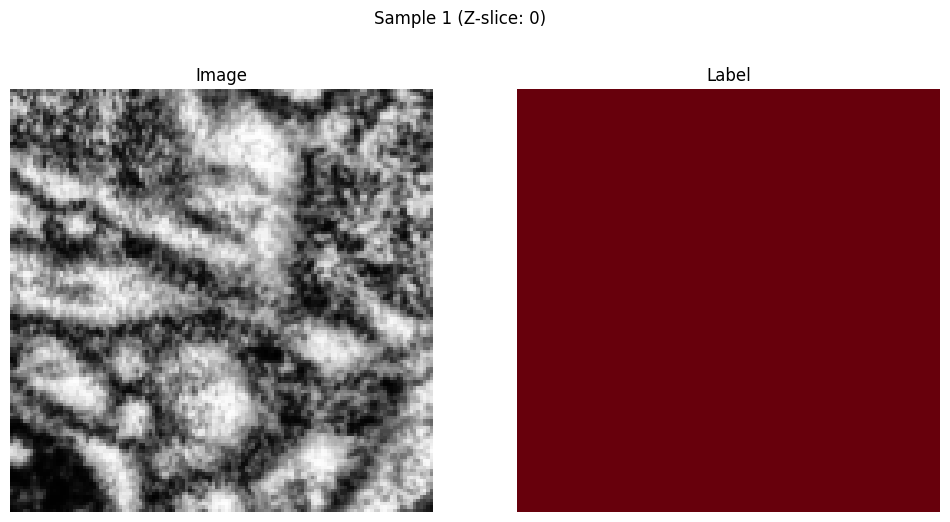

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 1: 2097152
Visualizing batch 1 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


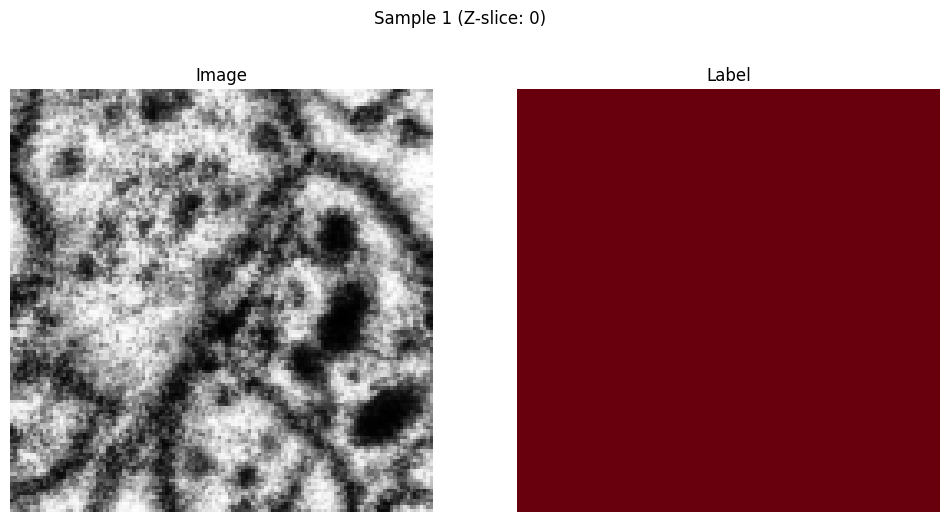

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 2: 2097152
Visualizing batch 2 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


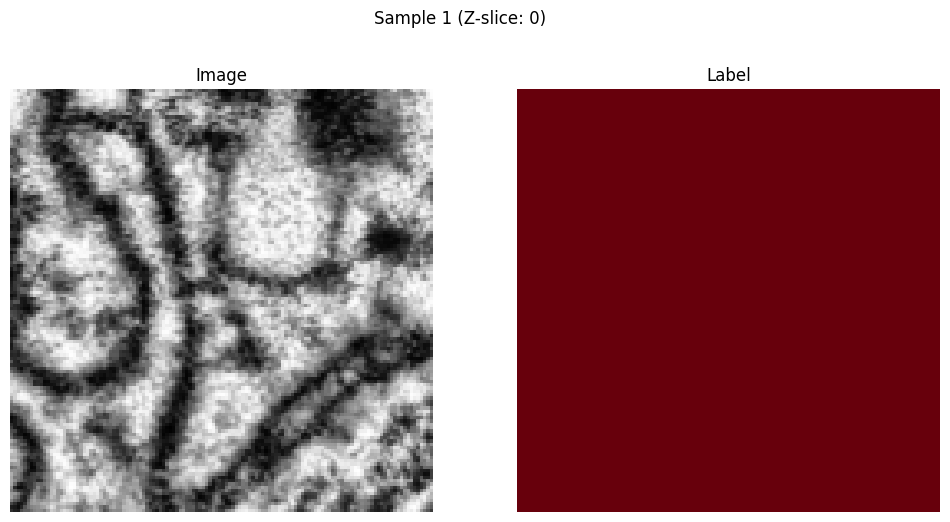

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 3: 2097152
Visualizing batch 3 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


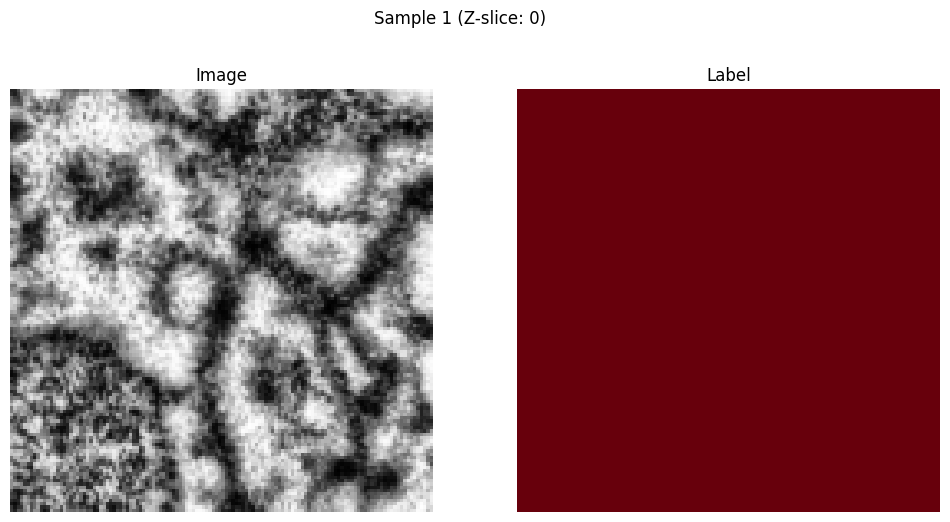

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 4: 2097152
Visualizing batch 4 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


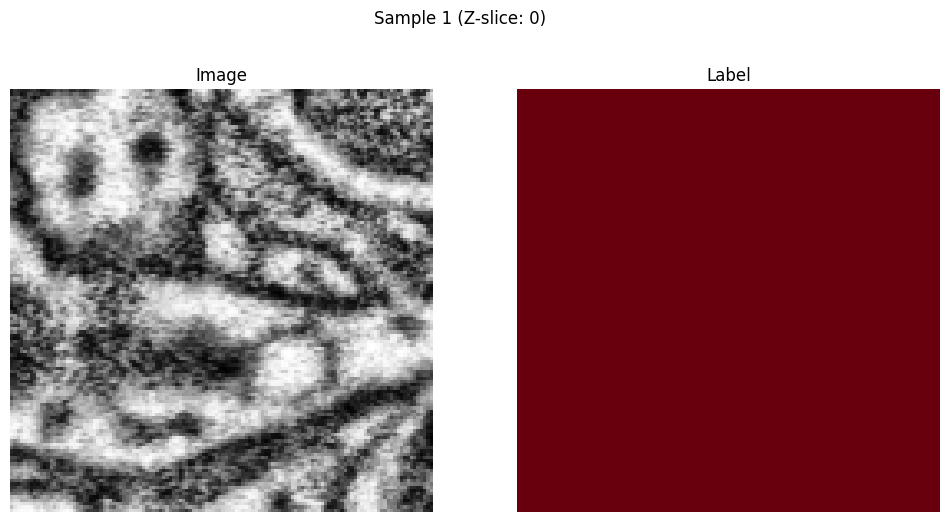

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 5: 2097152
Visualizing batch 5 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


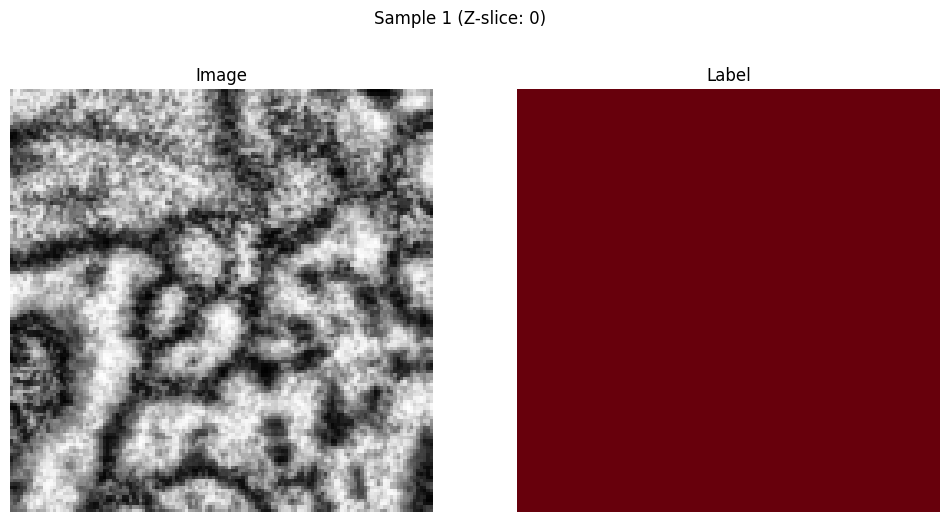

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 6: 2097152
Visualizing batch 6 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


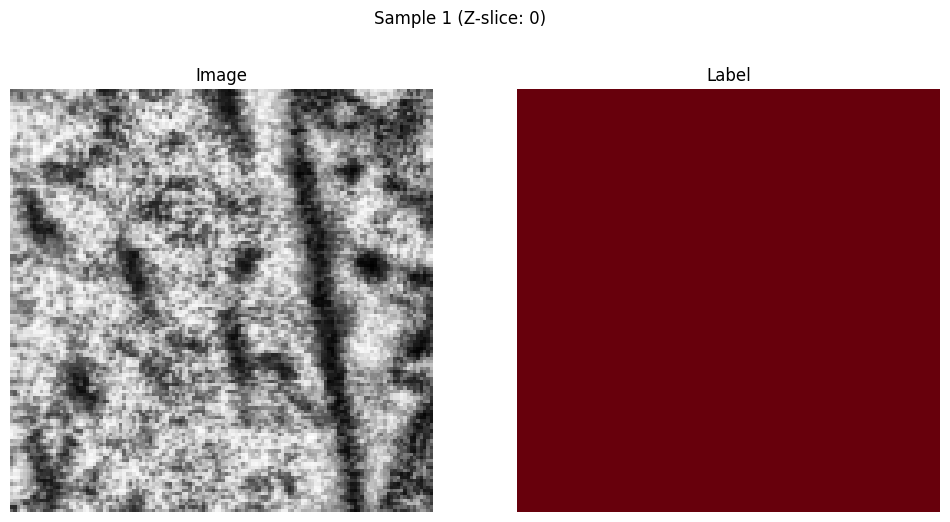

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 7: 2097152
Visualizing batch 7 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


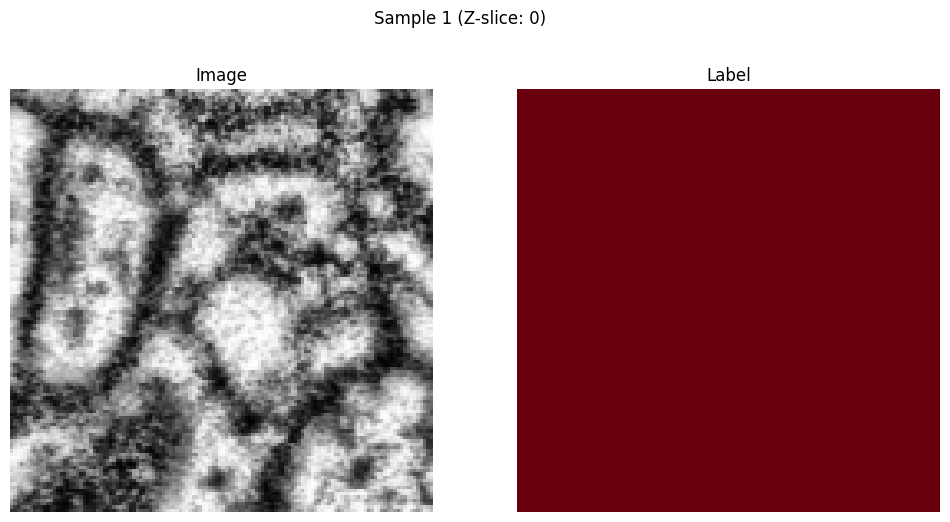

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 8: 2097152
Visualizing batch 8 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


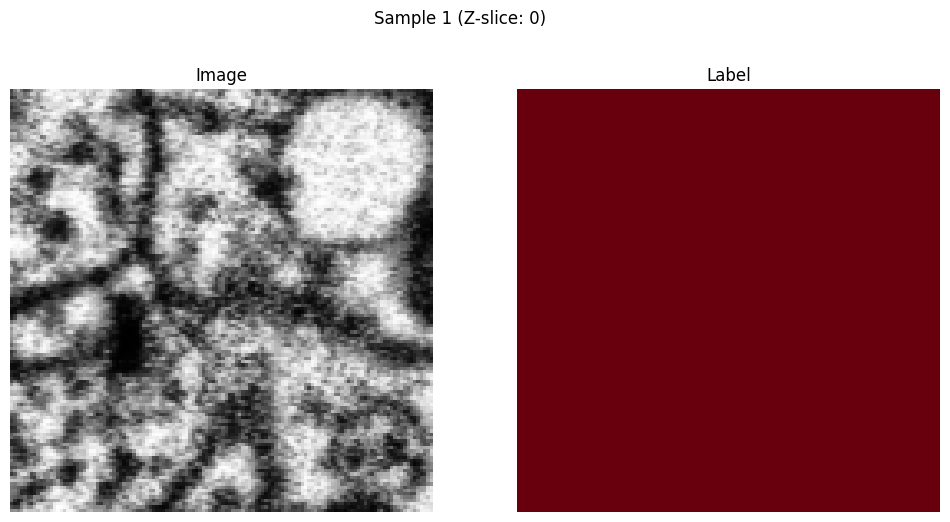

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 9: 2097152
Visualizing batch 9 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


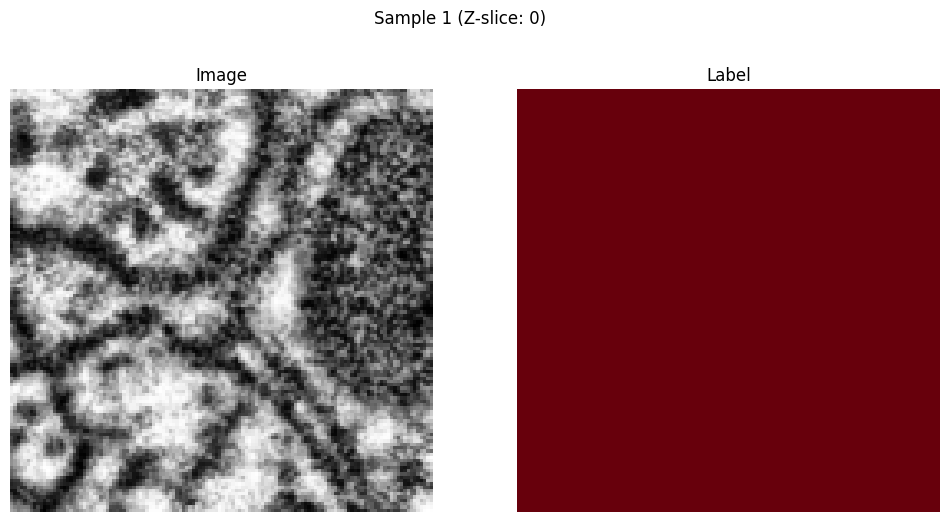

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 10: 2097152
Visualizing batch 10 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


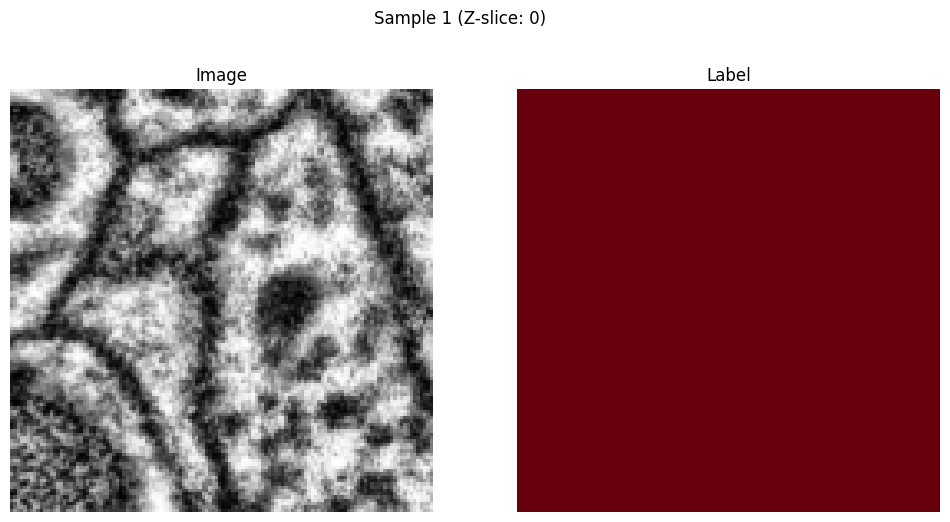

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 11: 2097152
Visualizing batch 11 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


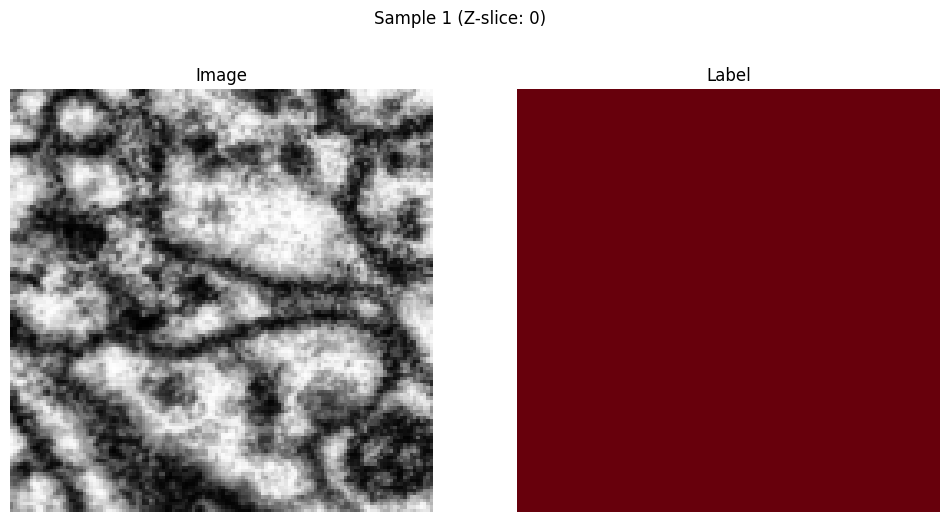

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 12: 2097152
Visualizing batch 12 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


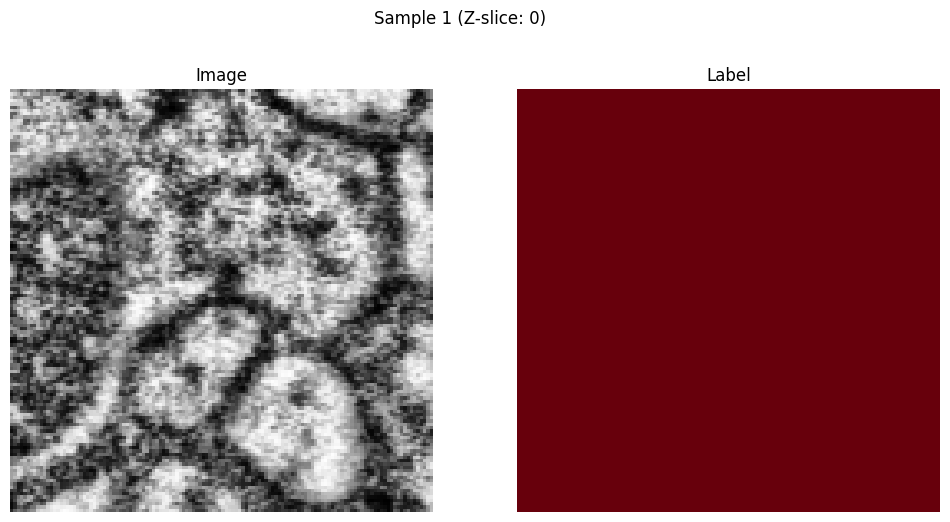

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 13: 2097152
Visualizing batch 13 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


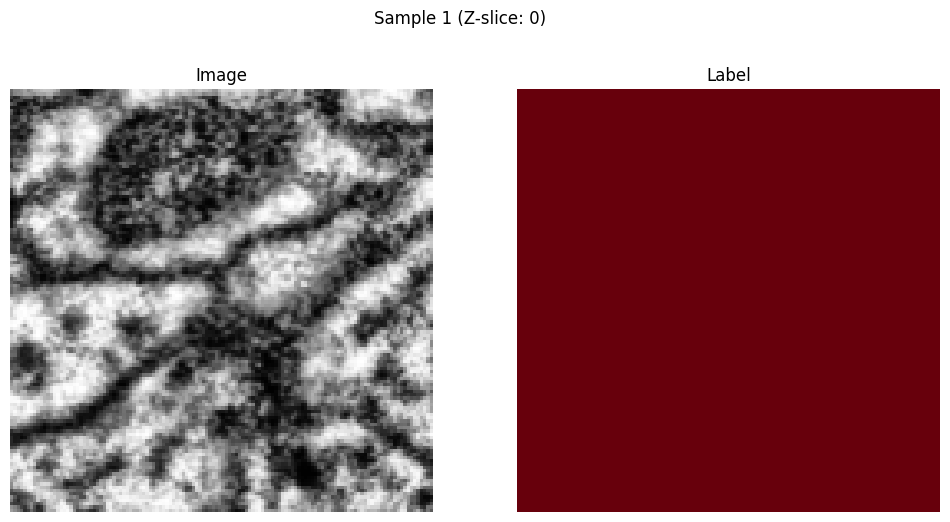

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 14: 2097152
Visualizing batch 14 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


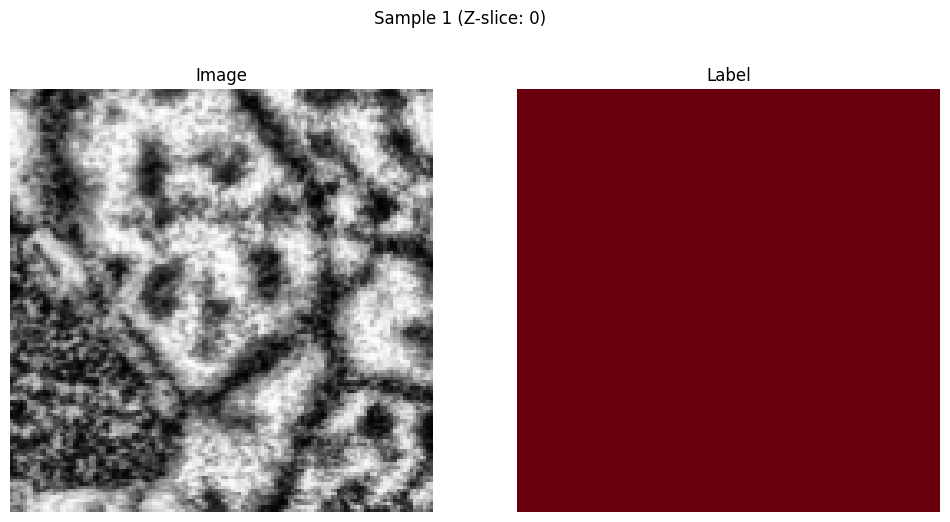

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 15: 2097152
Visualizing batch 15 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


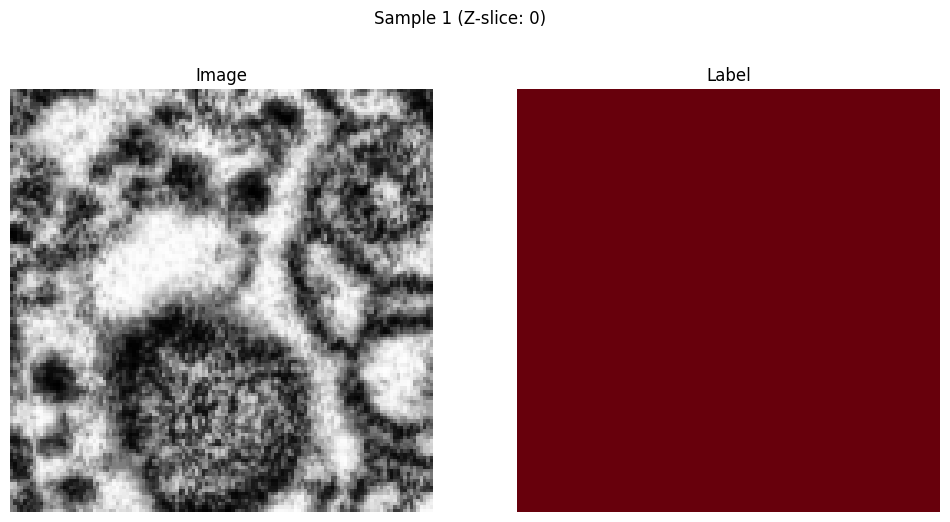

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 16: 2097152
Visualizing batch 16 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


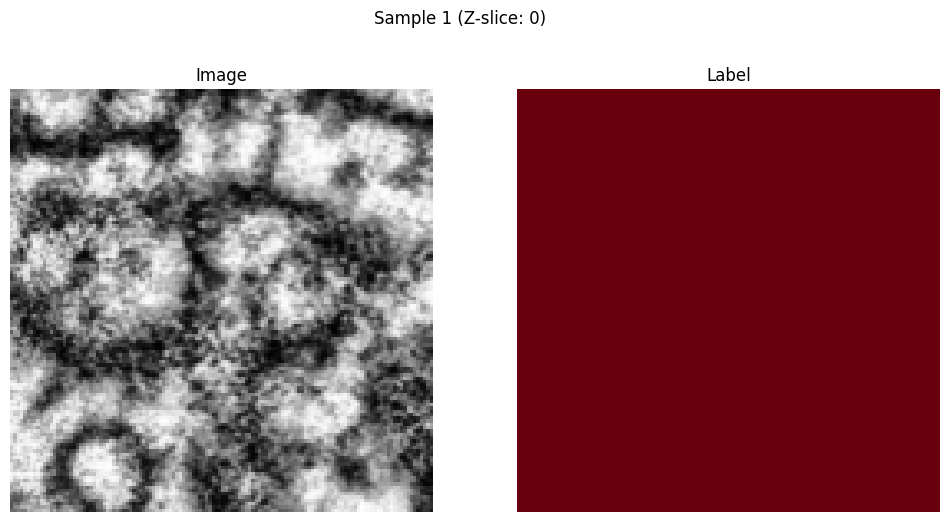

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 17: 2097152
Visualizing batch 17 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


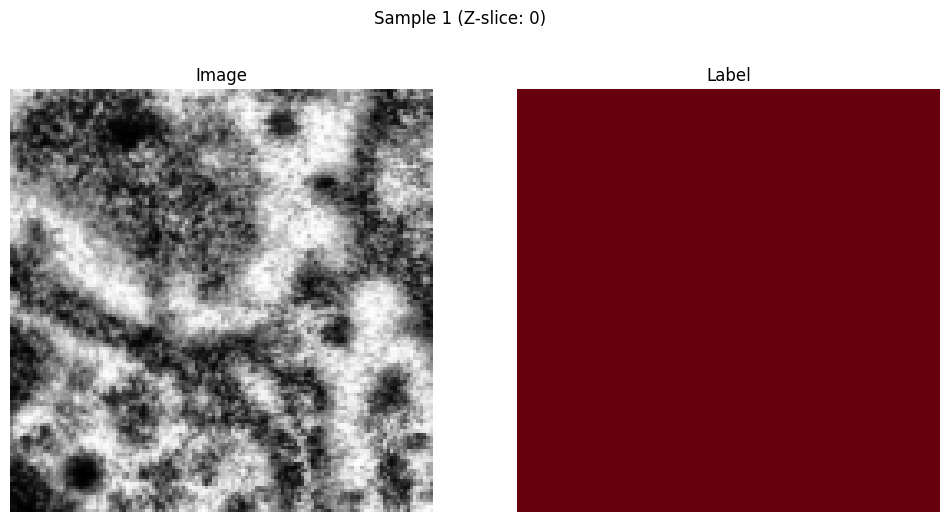

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 18: 2097152
Visualizing batch 18 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


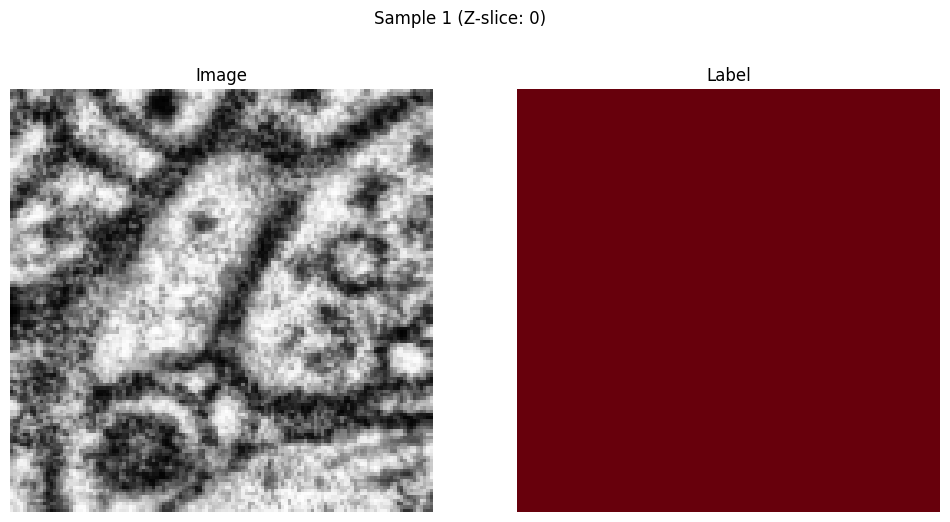

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 19: 2097152
Visualizing batch 19 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


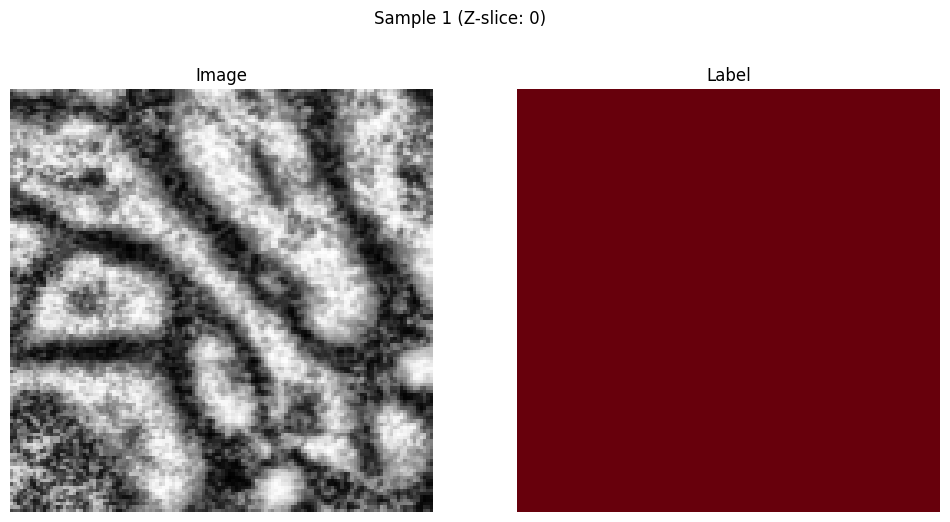

Batch visualization complete.
Successfully loaded a batch. Image batch shape: torch.Size([1, 1, 128, 128, 128]), Label batch shape: torch.Size([1, 1, 128, 128, 128])
sum of labels for batch 20: 2097152
Visualizing batch 20 (contains labels)...
Visualizing 1 samples from the batch. Batch shape: torch.Size([1, 1, 128, 128, 128])
Sample 1: Displaying most prominent slice (Z-slice: 0).


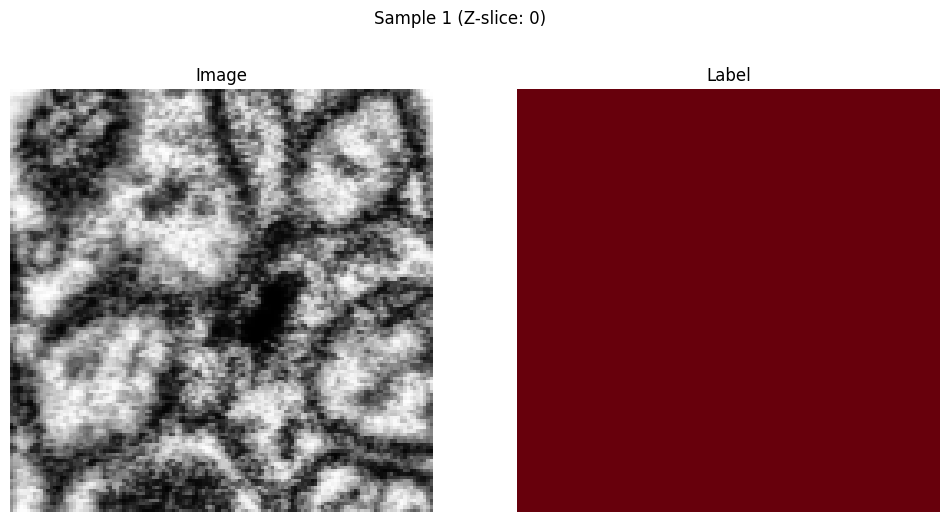

Batch visualization complete.


In [20]:
# Example of how you would use this in train.py:
from torch.utils.data import DataLoader, WeightedRandomSampler
# from dataset import EMDataset # Assuming you save the above class in dataset.py

# # Define your Zarr data directories (e.g., where your hemibrain_train_01.zarr, hemibrain_train_02.zarr are located)
# # Replace with your actual paths
train_zarr_dirs = ['/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_NEURONS_FOR_MITO/data_3d/train']
# test_zarr_dirs = ['/path/to/your/hemibrain_test_data_dir_1']

# # Instantiate the dataset for neuron labels
# # Assuming your hemibrain data is natively 8nm^3 isotropic, and you want to train at 8nm^3
train_neuron_dataset = EMDataset(
    zarr_data_dirs=train_zarr_dirs,
    label_type='neuron', # Or 'mito'
    patch_size=(128, 128, 128), # Example patch size for 8nm^3 data
    stride=(64,64,64),      # Example stride
    original_resolution_nm=(8.0, 8.0, 8.0),
    target_resolution_nm=(8.0, 8.0, 8.0), # Train at native resolution
    clahe=True,
    subsample_frac=1.0, # Use all available patches
    subsample_number=0,
    balance_patches=True, # <--- Set this to True to enable balancing
    min_positive_pixels=100 # <--- A small threshold, e.g., at least 10 foreground pixels
)


# test_neuron_dataset = EMDataset(
#     zarr_data_dirs=test_zarr_dirs,
#     label_type='neuron',
#     patch_size=(32, 32, 32),
#     stride=(16, 16, 16),
#     original_resolution_nm=(8.0, 8.0, 8.0),
#     target_resolution_nm=(8.0, 8.0, 8.0),
#     clahe=True
# )

# --- Create a DataLoader with WeightedRandomSampler ---
print("\n--- Creating DataLoader with WeightedRandomSampler ---")

# Ensure patch_weights are available
if train_neuron_dataset.balance_patches and train_neuron_dataset.patch_weights is not None:
    sampler = WeightedRandomSampler(
        weights=train_neuron_dataset.patch_weights,
        num_samples=len(train_neuron_dataset.patch_weights), # Sample for one epoch
        replacement=True # Allows sampling the same patch multiple times, common for imbalance
    )
    # When using a sampler, set shuffle=False in DataLoader as sampler handles order
    train_loader = DataLoader(train_neuron_dataset, batch_size=1, sampler=sampler, num_workers=0, pin_memory=True)
    print("DataLoader created with WeightedRandomSampler.")
else:
    # Fallback to regular DataLoader if balancing is off or weights not computed
    train_loader = DataLoader(train_neuron_dataset, batch_size=4, shuffle=True, num_workers=0, pin_memory=True)
    print("DataLoader created without WeightedRandomSampler (balancing not enabled or weights not computed).")


# # Create Test DataLoaders
# test_loader = DataLoader(test_neuron_dataset, batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

# --- 5. Get a batch and visualize ---
print("\n--- Getting and Visualizing a Batch ---")
# Iterate through the DataLoader to get one batch
# This will trigger the __getitem__ method of your EMDataset
try:
    for batch_idx, batch in enumerate(train_loader):
        sample_batch_X, sample_batch_Y = batch
        print(f"Successfully loaded a batch. Image batch shape: {sample_batch_X.shape}, Label batch shape: {sample_batch_Y.shape}")
        
        label_sum = sample_batch_Y.sum()
        print(f"sum of labels for batch {batch_idx}: {label_sum}")
        
        # Only visualize if there are any labels in the batch
        if label_sum > 0: # Ensure there's at least one positive pixel across the entire batch
            print(f"Visualizing batch {batch_idx} (contains labels)...")
            
            # Option 1: Find and plot the single most prominent slice
            visualize_batch(sample_batch_X, sample_batch_Y, num_samples_to_display=1, find_prominent_slice=True)
            
            # Option 2: Plot ALL slices within the patch that contain labels
            # Be careful with large patch_size if many slices have labels, it can generate many plots.
            # visualize_batch(sample_batch_X, sample_batch_Y, num_samples_to_display=1, plot_all_labeled_slices=True)

            # Option 3: Fallback to middle slice if you prefer, even with labels present
            # visualize_batch(sample_batch_X, sample_batch_Y, num_samples_to_display=1, slice_to_display='middle')

            # Break after visualizing one or two batches to avoid too many plots
            if batch_idx >= 20: # Adjust as needed (e.g., visualize first 2 batches)
                break 
        else:
            print(f"Batch {batch_idx} contains no visible labels (sum is 0). Skipping visualization.")
            # If you still get many batches with label_sum == 0 here,
            # it might indicate an issue with your `min_positive_pixels`
            # or the data itself, despite weighted sampling trying to help.

except Exception as e:
    print(f"Error loading or visualizing batch: {e}")
    print("Common issues: Incorrect Zarr paths, Zarr not chunked/formatted as expected, 'scipy' not installed for 3D zoom if resolutions differ, or multiprocessing issues with num_workers > 0.")
    print("Try setting num_workers=0 in DataLoader to debug if you suspect multiprocessing issues.")



In [15]:
# Count model parameters
def count_parameters(model):
    """
    Calculates the total number of trainable parameters in a PyTorch model.
    """
    # Sum the number of elements in each parameter tensor that requires gradients
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_parameters(model, model_name="Model"):
    """
    Prints the total number of parameters in a model in a human-readable format.
    """
    total_params = count_parameters(model)
    total_params =  total_params / (1024 * 1024)
    print(f"{model_name} has ~{total_params:,}M trainable parameters.")
    
    # Optionally, print parameters layer by layer for more detail
    # print("\nParameters by layer:")
    # for name, parameter in model.named_parameters():
    #     if parameter.requires_grad:
    #         print(f"  {name}: {parameter.numel():,} parameters")
    
    


In [16]:
# File: /rsunet.py
import torch.nn.functional as F
import torch.nn as nn
import torch


class ConvMod(nn.Module):
    """
    Convolution module for isotropic 3D data.
    """
    def __init__(self, in_channels, out_channels):
        super(ConvMod, self).__init__()
        
        # Isotropic convolutions - changed from (1,3,3) to (3,3,3)
        self.conv1 = nn.Conv3d(in_channels,  out_channels, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv3d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        # BatchNorm
        self.bn1 = nn.BatchNorm3d(out_channels, eps=1e-05, momentum=0.01)
        self.bn2 = nn.BatchNorm3d(out_channels, eps=1e-05, momentum=0.01)
        self.bn3 = nn.BatchNorm3d(out_channels, eps=1e-05, momentum=0.01)
        
        # Activation function
        self.activation = nn.ELU()
    
    def forward(self, x):
        # Conv 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation(x)
        skip = x
        
        # Conv 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activation(x)
        
        # Conv 3 with residual connection
        x = self.conv3(x)
        x = x + skip
        x = self.bn3(x)
        return self.activation(x)


class RSUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super(RSUNet, self).__init__()
        
        # Initial convolution - changed from (1,5,5) to (5,5,5) for isotropic
        self.conv0 = nn.Conv3d(in_ch, 28, kernel_size=5, padding=2)
        self.elu0 = nn.ELU()
        
        # Encoder path
        self.conv1 = ConvMod(28, 36)
        self.pool1 = nn.MaxPool3d(kernel_size=2, stride=2)  # Changed from (1,2,2) to 2
        
        self.conv2 = ConvMod(36, 48)
        self.pool2 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        self.conv3 = ConvMod(48, 64)
        self.pool3 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        self.conv4 = ConvMod(64, 80)
        self.pool4 = nn.MaxPool3d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.conv_bottleneck = ConvMod(80, 96)
        
        # Decoder path with proper channel matching
        self.up5 = nn.ConvTranspose3d(96, 80, kernel_size=2, stride=2)
        self.conv5 = ConvMod(80 + 64, 64)  # 80 from up5 + 64 from conv3
        
        self.up6 = nn.ConvTranspose3d(64, 48, kernel_size=2, stride=2)
        self.conv6 = ConvMod(48 + 48, 48)  # 48 from up6 + 48 from conv2
        
        self.up7 = nn.ConvTranspose3d(48, 36, kernel_size=2, stride=2)
        self.conv7 = ConvMod(36 + 36, 36)  # 36 from up7 + 36 from conv1
        
        self.up8 = nn.ConvTranspose3d(36, 28, kernel_size=2, stride=2)
        self.conv8 = ConvMod(28 + 28, 28)  # 28 from up8 + 28 from conv0
        
        # Final convolution - changed from (1,5,5) to (5,5,5)
        self.conv9 = nn.Conv3d(28, out_ch, kernel_size=5, padding=2)
        
        # Optional sigmoid activation
        self.sig0 = nn.Sigmoid()
        
    def _crop_and_concat(self, upsampled, skip):
        """
        Crop skip connection to match upsampled tensor size and concatenate.
        """
        # Get the target size from upsampled tensor
        target_size = upsampled.shape[2:]
        skip_size = skip.shape[2:]
        
        # Calculate cropping for each dimension
        crops = []
        for i in range(3):  # 3D
            diff = skip_size[i] - target_size[i]
            if diff > 0:
                start = diff // 2
                end = start + target_size[i]
                crops.append(slice(start, end))
            else:
                crops.append(slice(None))
        
        # Crop the skip connection
        skip_cropped = skip[:, :, crops[0], crops[1], crops[2]]
        
        # Concatenate along channel dimension
        return torch.cat([upsampled, skip_cropped], dim=1)
    
    def forward(self, x):
        # Encoder
        c0 = self.conv0(x)
        c0 = self.elu0(c0)
        
        c1 = self.conv1(c0)
        p1 = self.pool1(c1)
        
        c2 = self.conv2(p1)
        p2 = self.pool2(c2)
        
        c3 = self.conv3(p2)
        p3 = self.pool3(c3)
        
        c4 = self.conv4(p3)
        p4 = self.pool4(c4)
        
        # Bottleneck
        bottleneck = self.conv_bottleneck(p4)
        
        # Decoder with proper size matching
        up_5 = self.up5(bottleneck)
        c5 = self.conv5(self._crop_and_concat(up_5, c3))
        
        up_6 = self.up6(c5)
        c6 = self.conv6(self._crop_and_concat(up_6, c2))
        
        up_7 = self.up7(c6)
        c7 = self.conv7(self._crop_and_concat(up_7, c1))
        
        up_8 = self.up8(c7)
        c8 = self.conv8(self._crop_and_concat(up_8, c0))
        
        # Final output
        c9 = self.conv9(c8)
        
        # Return logits for BCEWithLogitsLoss
        return c9


# # Test function to verify the network works with 128^3 input
def test_network():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = RSUNet(in_ch=1, out_ch=1).to(device)
    
    # Test with batch size 1, 1 channel, 128x128x128
    test_input = torch.randn(1, 1, 128, 128, 128).to(device)
    
    # Print parameter count
    print_model_parameters(model, "RSUNet")
    
    with torch.no_grad():
        output = model(test_input)
        print(f"Input shape: {test_input.shape}")
        print(f"Output shape: {output.shape}")
        print("Network test passed!")
    
    return model

if __name__ == "__main__":
    model = test_network()

RSUNet has ~2.693535804748535M trainable parameters.
Input shape: torch.Size([1, 1, 128, 128, 128])
Output shape: torch.Size([1, 1, 128, 128, 128])
Network test passed!


In [5]:
# --- Loss Functions (from your original train.py) ---
import argparse
import numpy as np
import cv2
import os
from datetime import datetime

import torch.nn as nn
import torch
import torchmetrics
import torch.multiprocessing as mp
import torch.distributed as dist
from torch.utils.data import DataLoader, WeightedRandomSampler

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        sig00 = nn.Sigmoid()
        inputs = sig00(inputs)     
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        return 1 - dice


class DiceCE(nn.Module):
    def __init__(self):
        super(DiceCE, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none')
        self.dice_loss_fn = DiceLoss()

    def forward(self, inputs, targets, loss_weights, smooth=1):
        ce_loss_instance = nn.BCEWithLogitsLoss(pos_weight = torch.tensor(loss_weights).to(inputs.device))
        CE = ce_loss_instance(inputs, targets)

        DICE = self.dice_loss_fn(inputs, targets)

        return (CE + DICE)


# --- Main Training Function ---
def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    exp_name = args.exp_name
    if not os.path.isdir(str(exp_name)):
        os.makedirs(str(exp_name))
    
    print("\n--- Setting up Datasets and DataLoaders ---")
    
    train_dataset = EMDataset(
        zarr_data_dirs=args.train_zarr_dirs,
        label_type=args.label_type,
        patch_size=args.patch_size,
        stride=args.stride,
        original_resolution_nm=args.original_res,
        target_resolution_nm=args.target_res,
        clahe=args.clahe,
        subsample_frac=args.subsample_frac,
        subsample_number=args.subsample_number,
        seed=args.subsample_seed,
        balance_patches=args.balance_patches,
        min_positive_pixels=args.min_positive_pixels
    )

    if train_dataset.balance_patches and train_dataset.patch_weights is not None:
        sampler = WeightedRandomSampler(
            weights=train_dataset.patch_weights,
            num_samples=len(train_dataset.patch_weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, sampler=sampler, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created with WeightedRandomSampler.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created without WeightedRandomSampler (balancing not enabled or weights not computed).")

    test_loader = None
    if args.test_zarr_dirs:
        test_dataset = EMDataset(
            zarr_data_dirs=args.test_zarr_dirs,
            label_type=args.label_type,
            patch_size=args.patch_size,
            stride=args.stride,
            original_resolution_nm=args.original_res,
            target_resolution_nm=args.target_res,
            clahe=args.clahe,
            subsample_frac=1.0,
            subsample_number=0
        )
        test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers, pin_memory=True)
        print("Test DataLoader created.")
    else:
        print("No test dataset specified.")

    print("\n--- Initializing Model, Loss, and Optimizer ---")
    
    net = RSUNet(in_ch=1, out_ch=1)
    model = net.to(device)
    
    # Print parameter count
    print_model_parameters(model, "RSUNet")

    if args.model_loc:
        print(f"Loading model weights from: {args.model_loc}")
        try:
            model.load_state_dict(torch.load(args.model_loc, map_location=device))
            print("Successfully loaded entire model state_dict.")
        except RuntimeError as e:
            print(f"Could not load entire model state_dict. Attempting to load partial: {e}")
            state_dict = torch.load(args.model_loc, map_location=device)
            model_dict = model.state_dict()
            
            pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].shape == v.shape}
            
            if not pretrained_dict and any(k.startswith('module.') for k in state_dict.keys()):
                pretrained_dict = {k.replace('module.', ''): v for k, v in state_dict.items() if k.replace('module.', '') in model_dict and model_dict[k.replace('module.', '')].shape == v.shape}

            if args.freeze_encoder:
                print("Freezing encoder layers.")
                for name, param in model.named_parameters():
                    if any(enc_layer in name for enc_layer in ['conv0', 'conv1', 'pool1', 'conv2', 'pool2', 'conv3', 'pool3', 'conv4', 'pool4']):
                        param.requires_grad = False
            
            model_dict.update(pretrained_dict)
            model.load_state_dict(model_dict)
            print(f"Loaded {len(pretrained_dict)} matching layers from pretrained model.")


    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=args.learning_rate)
    
    criteria = DiceCE() 

    acc_metric = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric = torchmetrics.Precision(task='binary').to(device)
    tpr_metric = torchmetrics.Recall(task='binary').to(device)
    iou_metric = torchmetrics.JaccardIndex(task='binary').to(device)

    acc_metric_test = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric_test = torchmetrics.Precision(task='binary').to(device)
    tpr_metric_test = torchmetrics.Recall(task='binary').to(device)
    iou_metric_test = torchmetrics.JaccardIndex(task='binary').to(device)

    run_losses, test_losses = [], []
    run_TPRs, test_TPRs = [], []
    run_PPVs, test_PPVs = [], []
    run_accs, test_accs = [], []
    run_IOUs, test_IOUs = [], []
    
    start_epoch = 0 # Default starting epoch
    best_iou = 0.0
    
    if args.resume_checkpoint:
        if not os.path.exists(args.resume_checkpoint):
            print(f"Warning: Resume checkpoint '{args.resume_checkpoint}' not found. Starting from scratch.")
        else:
            print(f"Resuming training from checkpoint: {args.resume_checkpoint}")
            checkpoint = torch.load(args.resume_checkpoint, map_location=device)

            # Load model state
            model.load_state_dict(checkpoint['model_state_dict'])

            # Load optimizer state
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            # Restore epoch and best_iou
            start_epoch = checkpoint['epoch'] + 1 # Start from the next epoch
            best_iou = checkpoint.get('best_iou', 0.0) # Use .get() for backward compatibility

            print(f"Resumed from Epoch {start_epoch}, with best IoU: {best_iou:.4f}")
            # If you were tracking run_losses, test_losses etc. in the checkpoint, load them too
            # e.g., run_losses = checkpoint.get('run_losses', [])
            # test_losses = checkpoint.get('test_losses', [])
            # You'd need to save these in the checkpoint dict as well.
            run_losses = checkpoint.get('run_losses', [])
            test_losses = checkpoint.get('test_losses', [])
            


    print("\n========== BEGIN TRAINING LOOP ==========")
    start_time = datetime.now()

    for epoch in range(start_epoch, args.epochs):
        print(f"\n--- Epoch {epoch+1}/{args.epochs} ---")
        model.train()
        run_loss = 0.0

        if (epoch == 50 and args.hotstart):
            for g in optimizer.param_groups:
                g['lr'] = args.learning_rate_after_hotstart_50
            print(f"Learning rate changed to {args.learning_rate_after_hotstart_50} at epoch 50.")
        
        for g in optimizer.param_groups:
            print(f"Current learning rate: {g['lr']}")

        for batch_idx, (sample, labels) in enumerate(train_loader):
            sample = sample.to(device)
            labels = labels.to(device)

            if args.rotation_augs:
                for z0 in range(sample.size(0)):
                    rot_n = np.random.randint(low=0, high=4)
                    sample[z0,:,:,:,:] = torch.rot90(sample[z0,:,:,:,:], rot_n, dims=[2,3])
                    labels[z0,:,:,:,:] = torch.rot90(labels[z0,:,:,:,:], rot_n, dims=[2,3])
            
            if args.contrast_augs:
                for z0 in range(sample.size(0)):
                    rand_int1 = np.random.randint(low=0, high=4)
                    if rand_int1 != 0:
                        alpha = torch.rand(1).to(device) * 1.0 + 0.5
                        beta = torch.rand(1).to(device) * 1.0 - 0.5
                        sample[z0,:,:,:,:] = torch.clamp(sample[z0,:,:,:,:] * alpha + beta, -1, 1)

            optimizer.zero_grad()
            pred_logits = model(sample)
            
            loss = criteria(pred_logits, labels.float(), loss_weights=args.loss_weights)
            
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item()

            pred_probs = torch.sigmoid(pred_logits)
            pred_binary = (pred_probs >= 0.5).int()

            acc_metric.update(pred_binary, labels.int())
            ppv_metric.update(pred_binary, labels.int())
            tpr_metric.update(pred_binary, labels.int())
            iou_metric.update(pred_binary, labels.int())
            
            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}, "
                      f"Acc: {acc_metric.compute().item():.4f}, PPV: {ppv_metric.compute().item():.4f}, "
                      f"TPR: {tpr_metric.compute().item():.4f}, IoU: {iou_metric.compute().item():.4f}")
            
            if args.save_images and epoch in [0, 10, 20, 50, 100, 150] and (batch_idx + 1) % (len(train_loader) // 3 + 1) == 0:
                save_dir = os.path.join(exp_name, f"epoch_{epoch}", f"batch_{batch_idx}")
                os.makedirs(save_dir, exist_ok=True)
                
                pred_binary_np = pred_binary[0, 0].cpu().numpy() * 255
                labels_np = labels[0, 0].cpu().numpy() * 255
                sample_np = ((sample[0, 0].cpu().numpy() + 1) * 127.5).astype(np.uint8)

                for z_slice in [0, pred_binary_np.shape[0] // 2, pred_binary_np.shape[0] - 1]:
                    cv2.imwrite(os.path.join(save_dir, f"prediction_z{z_slice:03d}.png"), pred_binary_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"gt_z{z_slice:03d}.png"), labels_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"input_z{z_slice:03d}.png"), sample_np[z_slice, :, :])

        epoch_run_loss = run_loss / len(train_loader)
        epoch_run_acc = acc_metric.compute().item()
        epoch_run_tpr = tpr_metric.compute().item()
        epoch_run_ppv = ppv_metric.compute().item()
        epoch_run_iou = iou_metric.compute().item()

        run_losses.append(epoch_run_loss)
        run_accs.append(epoch_run_acc)
        run_TPRs.append(epoch_run_tpr)
        run_PPVs.append(epoch_run_ppv)
        run_IOUs.append(epoch_run_iou)
        
        print(f"\nEpoch {epoch+1} Training Summary:")
        print(f"  Avg Loss: {epoch_run_loss:.4f}, Avg Acc: {epoch_run_acc:.4f}, "
              f"Avg PPV: {epoch_run_ppv:.4f}, Avg TPR: {epoch_run_tpr:.4f}, Avg IoU: {epoch_run_iou:.4f}")

        acc_metric.reset()
        ppv_metric.reset()
        tpr_metric.reset()
        iou_metric.reset()

        if (epoch + 1) % args.eval_interval == 0 and test_loader:
            model.eval()
            test_loss = 0.0
            print("\n--- Starting Test Phase ---")
            with torch.no_grad():
                for batch_idx_test, (sample_test, labels_test) in enumerate(test_loader):
                    sample_test = sample_test.to(device)
                    labels_test = labels_test.to(device)

                    pred_logits_test = model(sample_test)
                    loss_test = criteria(pred_logits_test, labels_test.float(), loss_weights=args.loss_weights)
                    test_loss += loss_test.item()

                    pred_probs_test = torch.sigmoid(pred_logits_test)
                    pred_binary_test = (pred_probs_test >= 0.5).int()

                    acc_metric_test.update(pred_binary_test, labels_test.int())
                    ppv_metric_test.update(pred_binary_test, labels_test.int())
                    tpr_metric_test.update(pred_binary_test, labels_test.int())
                    iou_metric_test.update(pred_binary_test, labels_test.int())
                
                epoch_test_loss = test_loss / len(test_loader)
                epoch_test_acc = acc_metric_test.compute().item()
                epoch_test_tpr = tpr_metric_test.compute().item()
                epoch_test_ppv = ppv_metric_test.compute().item()
                epoch_test_iou = iou_metric_test.compute().item()

                test_losses.append(epoch_test_loss)
                test_accs.append(epoch_test_acc)
                test_TPRs.append(epoch_test_tpr)
                test_PPVs.append(epoch_test_ppv)
                test_IOUs.append(epoch_test_iou)
                
                # Every test save a checkpoint
                model_save_path = os.path.join(exp_name, f'test_epoch{(epoch + 1)}_iou{epoch_test_iou:.4f}.pth') # Renamed for clarity
            
                checkpoint_state = {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_iou': best_iou,
                    'run_losses': run_losses,
                    'test_losses': test_losses
                }
                torch.save(checkpoint_state, model_save_path) # Save best model as a full checkpoint
                print(f"Test model (checkpoint) saved at {model_save_path}")


                print(f"Epoch {epoch+1} Test Summary:")
                print(f"  Avg Loss: {epoch_test_loss:.4f}, Avg Acc: {epoch_test_acc:.4f}, "
                      f"Avg PPV: {epoch_test_ppv:.4f}, Avg TPR: {epoch_test_tpr:.4f}, Avg IoU: {epoch_test_iou:.4f}")
                
                if epoch_test_iou > best_iou:
#                     best_iou = epoch_test_iou
#                     model_save_path = os.path.join(exp_name, f'trained_model_epoch{epoch+1}_IoU{best_iou:.4f}.pth')
#                     torch.save(model.state_dict(), model_save_path)
#                     print(f"New best model saved at {model_save_path}")
                    best_iou = epoch_test_iou
                    model_save_path = os.path.join(exp_name, f'best_model_IoU{best_iou:.4f}.pth') # Renamed for clarity

                    # Save a comprehensive checkpoint for resuming
                    checkpoint_state = {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'best_iou': best_iou,
                        'run_losses': run_losses,
                        'test_losses': test_losses
                    }
                    torch.save(checkpoint_state, model_save_path) # Save best model as a full checkpoint
                    print(f"New best model (checkpoint) saved at {model_save_path}")

            acc_metric_test.reset()
            ppv_metric_test.reset()
            tpr_metric_test.reset()
            iou_metric_test.reset()

        # Save checkpoint models (e.g., at specific epochs)
        if ((epoch + 1) % args.ckpt_interval == 0) or (epoch + 1 == args.epochs): # Also save at final epoch
            checkpoint_path = os.path.join(exp_name, f'checkpoint_epoch_{epoch+1}.pth') # Renamed for clarity

            checkpoint_state = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_iou': best_iou, # Best IoU up to this point
            }
            torch.save(checkpoint_state, checkpoint_path)
            print(f"Checkpoint saved at {checkpoint_path}")

    print("\n========== TRAINING COMPLETE ==========")
    time_taken = datetime.now() - start_time
    print(f"Total training time: {time_taken}")

    np.save(os.path.join(exp_name, "run_losses.npy"), np.array(run_losses))
    np.save(os.path.join(exp_name, "test_losses.npy"), np.array(test_losses))
    np.save(os.path.join(exp_name, "run_accs.npy"), np.array(run_accs))
    np.save(os.path.join(exp_name, "test_accs.npy"), np.array(test_accs))
    np.save(os.path.join(exp_name, "run_TPRs.npy"), np.array(run_TPRs))
    np.save(os.path.join(exp_name, "test_TPRs.npy"), np.array(test_TPRs))
    np.save(os.path.join(exp_name, "run_PPVs.npy"), np.array(run_PPVs))
    np.save(os.path.join(exp_name, "test_PPVs.npy"), np.array(test_PPVs))
    np.save(os.path.join(exp_name, "run_IOUs.npy"), np.array(run_IOUs))
    np.save(os.path.join(exp_name, "test_IOUs.npy"), np.array(test_IOUs))
    print("Metrics saved.")


# --- Command-line Argument Parsing (Modified for Jupyter) ---
# Instead of parser.parse_args(), we'll create a dummy object or define args directly.
class Args:
    def __init__(self):
        self.exp_name = "mito_rsunet_from_scratch"
        self.train_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train"]
        self.test_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test"] # Or provide path for test set if available
        self.label_type = 'neuron'
        self.epochs = 100
        self.batch_size = 1 # Keep at 1 for now if visualizing, can increase for actual training
        self.patch_size = [128, 128, 128]
        self.stride = [64, 64, 64]
        self.original_res = [8.0, 8.0, 8.0]
        self.target_res = [8.0, 8.0, 8.0]
        self.clahe = True
        self.subsample_frac = 1.0
        self.subsample_number = 0
        self.subsample_seed = 27
        self.balance_patches = True # Crucial for balancing
        self.min_positive_pixels = 100 # Adjust based on your data visualization
        self.learning_rate = 0.002
        self.learning_rate_after_hotstart_50 = 0.002
        self.loss_type = 'DiceCE'
        self.loss_weights = 5.0 # Tune this based on pixel imbalance
        self.rotation_augs = True
        self.contrast_augs = True
        self.model_loc = None # No pretrained model for training from scratch
        self.freeze_encoder = False
        self.hotstart = False
        self.save_images = True # Set to True to save predicted images
        self.eval_interval = 5
        self.ckpt_interval = 25
        self.num_workers = 0 # Start with 0 for debugging in Jupyter. Increase for performance.
        self.resume_checkpoint = "/media/samia/DATA/PhD/codebases/MitoEM/mito_rsunet_from_scratch/checkpoint_epoch_1.pth" # Path to a checkpoint file to resume training from

args = Args()

# Call the training function
train(args)

Using device: cuda

--- Setting up Datasets and DataLoaders ---
Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y20992_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y21504_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x19676_y12227_z13244_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y17408_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y22016_z21948_C.zarr with shape (512, 512, 512)
Calculating all possible patch indices...
Dataset initialized with 1715 total patch

100%|███████████████████████████████████████| 1715/1715 [00:36<00:00, 47.13it/s]


Found 1489 positive patches and 226 negative patches.
Assigned weights (prioritizing labeled patches for segmentation):
  Labeled patch weight: 1.00
  Unlabeled patch weight: 0.15
Patch positivity calculation complete.
Train DataLoader created with WeightedRandomSampler.
Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test/hemi_x11051_y17920_z21948_clahe.zarr with shape (512, 512, 512)
Calculating all possible patch indices...
Dataset initialized with 343 total patches.
Calculating patch positivity for balanced sampling...


100%|█████████████████████████████████████████| 343/343 [00:06<00:00, 50.03it/s]


Found 343 positive patches and 0 negative patches.
All identified patches contain labels. No specific balancing needed for patch selection.
Patch positivity calculation complete.
Test DataLoader created.

--- Initializing Model, Loss, and Optimizer ---
Resuming training from checkpoint: /media/samia/DATA/PhD/codebases/MitoEM/mito_rsunet_from_scratch/checkpoint_epoch_1.pth
Resumed from Epoch 1, with best IoU: 0.0000

========== BEGIN TRAINING LOOP ==========

--- Epoch 2/100 ---
Current learning rate: 0.002
  Batch 20/1715 - Loss: 0.8539, Acc: 0.8845, PPV: 0.5064, TPR: 0.7838, IoU: 0.4444
  Batch 40/1715 - Loss: 1.4286, Acc: 0.8744, PPV: 0.4929, TPR: 0.7913, IoU: 0.4362
  Batch 60/1715 - Loss: 0.9462, Acc: 0.8804, PPV: 0.5271, TPR: 0.7959, IoU: 0.4643
  Batch 80/1715 - Loss: 0.8481, Acc: 0.8807, PPV: 0.5083, TPR: 0.8134, IoU: 0.4552
  Batch 100/1715 - Loss: 1.2960, Acc: 0.8874, PPV: 0.5075, TPR: 0.8114, IoU: 0.4540
  Batch 120/1715 - Loss: 0.6472, Acc: 0.8900, PPV: 0.5150, TPR: 0.8127, 

...

  Batch 140/1715 - Loss: 0.2445, Acc: 0.9861, PPV: 0.9092, TPR: 0.9710, IoU: 0.8851
  Batch 160/1715 - Loss: 0.1281, Acc: 0.9854, PPV: 0.9072, TPR: 0.9710, IoU: 0.8833
  Batch 180/1715 - Loss: 0.3446, Acc: 0.9852, PPV: 0.9071, TPR: 0.9715, IoU: 0.8836
  Batch 200/1715 - Loss: 0.1295, Acc: 0.9854, PPV: 0.9096, TPR: 0.9712, IoU: 0.8857
  Batch 220/1715 - Loss: 0.0916, Acc: 0.9856, PPV: 0.9088, TPR: 0.9715, IoU: 0.8852
  Batch 240/1715 - Loss: 0.2242, Acc: 0.9853, PPV: 0.9074, TPR: 0.9719, IoU: 0.8842
  Batch 260/1715 - Loss: 0.1933, Acc: 0.9853, PPV: 0.9084, TPR: 0.9717, IoU: 0.8850
  Batch 280/1715 - Loss: 0.3540, Acc: 0.9854, PPV: 0.9091, TPR: 0.9721, IoU: 0.8860
  Batch 300/1715 - Loss: 0.0965, Acc: 0.9853, PPV: 0.9090, TPR: 0.9722, IoU: 0.8860
  Batch 320/1715 - Loss: 0.2880, Acc: 0.9850, PPV: 0.9064, TPR: 0.9719, IoU: 0.8833
  Batch 340/1715 - Loss: 0.2007, Acc: 0.9844, PPV: 0.9041, TPR: 0.9715, IoU: 0.8807
  Batch 360/1715 - Loss: 0.3245, Acc: 0.9843, PPV: 0.9040, TPR: 0.9716, IoU:

  Batch 360/1715 - Loss: 0.1430, Acc: 0.9857, PPV: 0.9121, TPR: 0.9755, IoU: 0.8916
  Batch 380/1715 - Loss: 0.1669, Acc: 0.9857, PPV: 0.9112, TPR: 0.9754, IoU: 0.8907
  Batch 400/1715 - Loss: 0.1156, Acc: 0.9857, PPV: 0.9119, TPR: 0.9757, IoU: 0.8916
  Batch 420/1715 - Loss: 0.2817, Acc: 0.9857, PPV: 0.9115, TPR: 0.9756, IoU: 0.8912
  Batch 440/1715 - Loss: 0.1287, Acc: 0.9856, PPV: 0.9118, TPR: 0.9758, IoU: 0.8917
  Batch 460/1715 - Loss: 0.0824, Acc: 0.9857, PPV: 0.9118, TPR: 0.9757, IoU: 0.8916
  Batch 480/1715 - Loss: 0.0904, Acc: 0.9855, PPV: 0.9107, TPR: 0.9753, IoU: 0.8902
  Batch 500/1715 - Loss: 0.1570, Acc: 0.9855, PPV: 0.9106, TPR: 0.9754, IoU: 0.8902
  Batch 520/1715 - Loss: 0.1965, Acc: 0.9855, PPV: 0.9104, TPR: 0.9754, IoU: 0.8899
  Batch 540/1715 - Loss: 0.1414, Acc: 0.9856, PPV: 0.9107, TPR: 0.9754, IoU: 0.8902
  Batch 560/1715 - Loss: 0.3216, Acc: 0.9856, PPV: 0.9107, TPR: 0.9751, IoU: 0.8900
  Batch 580/1715 - Loss: 0.2627, Acc: 0.9854, PPV: 0.9100, TPR: 0.9745, IoU:

  Batch 580/1715 - Loss: 0.2208, Acc: 0.9778, PPV: 0.8796, TPR: 0.9570, IoU: 0.8461
  Batch 600/1715 - Loss: 0.1351, Acc: 0.9778, PPV: 0.8799, TPR: 0.9579, IoU: 0.8472
  Batch 620/1715 - Loss: 0.2789, Acc: 0.9780, PPV: 0.8811, TPR: 0.9581, IoU: 0.8485
  Batch 640/1715 - Loss: 0.1910, Acc: 0.9784, PPV: 0.8820, TPR: 0.9583, IoU: 0.8493
  Batch 660/1715 - Loss: 0.1108, Acc: 0.9784, PPV: 0.8818, TPR: 0.9587, IoU: 0.8495
  Batch 680/1715 - Loss: 0.2080, Acc: 0.9782, PPV: 0.8809, TPR: 0.9589, IoU: 0.8488
  Batch 700/1715 - Loss: 0.6247, Acc: 0.9782, PPV: 0.8809, TPR: 0.9589, IoU: 0.8489
  Batch 720/1715 - Loss: 0.8891, Acc: 0.9780, PPV: 0.8795, TPR: 0.9590, IoU: 0.8476
  Batch 740/1715 - Loss: 0.0823, Acc: 0.9781, PPV: 0.8801, TPR: 0.9591, IoU: 0.8482
  Batch 760/1715 - Loss: 0.2249, Acc: 0.9782, PPV: 0.8791, TPR: 0.9591, IoU: 0.8474
  Batch 780/1715 - Loss: 0.2440, Acc: 0.9783, PPV: 0.8792, TPR: 0.9594, IoU: 0.8477
  Batch 800/1715 - Loss: 0.2112, Acc: 0.9784, PPV: 0.8800, TPR: 0.9597, IoU:

  Batch 800/1715 - Loss: 0.0924, Acc: 0.9844, PPV: 0.9083, TPR: 0.9759, IoU: 0.8884
  Batch 820/1715 - Loss: 1.0310, Acc: 0.9843, PPV: 0.9083, TPR: 0.9760, IoU: 0.8884
  Batch 840/1715 - Loss: 0.1008, Acc: 0.9843, PPV: 0.9083, TPR: 0.9760, IoU: 0.8885
  Batch 860/1715 - Loss: 0.2696, Acc: 0.9843, PPV: 0.9085, TPR: 0.9760, IoU: 0.8887
  Batch 880/1715 - Loss: 0.1355, Acc: 0.9844, PPV: 0.9088, TPR: 0.9760, IoU: 0.8890
  Batch 900/1715 - Loss: 0.1465, Acc: 0.9843, PPV: 0.9085, TPR: 0.9761, IoU: 0.8888
  Batch 920/1715 - Loss: 0.1012, Acc: 0.9844, PPV: 0.9087, TPR: 0.9760, IoU: 0.8888
  Batch 940/1715 - Loss: 0.1022, Acc: 0.9843, PPV: 0.9089, TPR: 0.9762, IoU: 0.8892
  Batch 960/1715 - Loss: 0.1392, Acc: 0.9844, PPV: 0.9089, TPR: 0.9761, IoU: 0.8891
  Batch 980/1715 - Loss: 0.2387, Acc: 0.9844, PPV: 0.9090, TPR: 0.9762, IoU: 0.8893
  Batch 1000/1715 - Loss: 0.2001, Acc: 0.9845, PPV: 0.9090, TPR: 0.9761, IoU: 0.8892
  Batch 1020/1715 - Loss: 0.3116, Acc: 0.9845, PPV: 0.9091, TPR: 0.9761, Io

  Batch 1020/1715 - Loss: 0.1277, Acc: 0.9849, PPV: 0.9126, TPR: 0.9759, IoU: 0.8925
  Batch 1040/1715 - Loss: 0.1215, Acc: 0.9849, PPV: 0.9127, TPR: 0.9761, IoU: 0.8927
  Batch 1060/1715 - Loss: 0.1156, Acc: 0.9849, PPV: 0.9127, TPR: 0.9762, IoU: 0.8928
  Batch 1080/1715 - Loss: 0.1534, Acc: 0.9850, PPV: 0.9126, TPR: 0.9761, IoU: 0.8926
  Batch 1100/1715 - Loss: 0.2766, Acc: 0.9849, PPV: 0.9123, TPR: 0.9759, IoU: 0.8921
  Batch 1120/1715 - Loss: 0.4875, Acc: 0.9847, PPV: 0.9116, TPR: 0.9755, IoU: 0.8913
  Batch 1140/1715 - Loss: 0.2001, Acc: 0.9846, PPV: 0.9106, TPR: 0.9754, IoU: 0.8902
  Batch 1160/1715 - Loss: 0.1575, Acc: 0.9845, PPV: 0.9100, TPR: 0.9753, IoU: 0.8895
  Batch 1180/1715 - Loss: 0.1720, Acc: 0.9844, PPV: 0.9097, TPR: 0.9752, IoU: 0.8891
  Batch 1200/1715 - Loss: 0.1590, Acc: 0.9844, PPV: 0.9092, TPR: 0.9751, IoU: 0.8886
  Batch 1220/1715 - Loss: 0.4872, Acc: 0.9843, PPV: 0.9088, TPR: 0.9747, IoU: 0.8879
  Batch 1240/1715 - Loss: 0.1467, Acc: 0.9842, PPV: 0.9080, TPR: 

### Monai

In [42]:
# --- Main Training Function ---

import argparse
import numpy as np
import cv2
import os
from datetime import datetime

import torch.nn as nn
import torch
import torchmetrics
import torch.multiprocessing as mp
import torch.distributed as dist
from torch.utils.data import DataLoader, WeightedRandomSampler

# Additional imports for EMDataset
import glob
import zarr
try:
    import scipy.ndimage
except ImportError:
    print("Warning: scipy.ndimage not found. 3D image processing might fall back to 2D slice-by-slice operations.")

# --- NEW: Import MONAI UNet and ResidualUnit ---
from monai.networks.nets import UNet
from monai.networks.blocks import ResidualUnit # If you want to use ResidualUnit for custom blocks


def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    exp_name = args.exp_name
    if not os.path.isdir(str(exp_name)):
        os.makedirs(str(exp_name))
    
    print("\n--- Setting up Datasets and DataLoaders ---")
    
    train_dataset = EMDataset(
        zarr_data_dirs=args.train_zarr_dirs,
        label_type=args.label_type, # Targeting mitochondria
        patch_size=args.patch_size,
        stride=args.stride,
        original_resolution_nm=args.original_res,
        target_resolution_nm=args.target_res,
        clahe=args.clahe,
        subsample_frac=args.subsample_frac,
        subsample_number=args.subsample_number,
        seed=args.subsample_seed,
        balance_patches=args.balance_patches,
        min_positive_pixels=args.min_positive_pixels
    )

    if train_dataset.balance_patches and train_dataset.patch_weights is not None:
        sampler = WeightedRandomSampler(
            weights=train_dataset.patch_weights,
            num_samples=len(train_dataset.patch_weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, sampler=sampler, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created with WeightedRandomSampler.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created without WeightedRandomSampler (balancing not enabled or weights not computed).")

    test_loader = None
    if args.test_zarr_dirs:
        test_dataset = EMDataset(
            zarr_data_dirs=args.test_zarr_dirs,
            label_type=args.label_type,
            patch_size=args.patch_size,
            stride=args.stride,
            original_resolution_nm=args.original_res,
            target_resolution_nm=args.target_res,
            clahe=args.clahe,
            subsample_frac=1.0,
            subsample_number=0
        )
        test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers, pin_memory=True)
        print("Test DataLoader created.")
    else:
        print("No test dataset specified.")

    print("\n--- Initializing Model, Loss, and Optimizer ---")
    
    # --- CHANGE THIS SECTION FOR MONAI UNet ---
    # Determine the number of spatial dimensions (3 for 3D)
    spatial_dims = 3 
    # Input channels: 1 (grayscale EM images)
    in_channels = 1 
    # Output channels: 1 (binary segmentation: foreground/background)
    out_channels = 1 

    # MONAI UNet parameters:
    # `channels`: controls number of features maps at each level.
    # `strides`: controls spatial downsampling at each level (usually (2,2,2) for 3D).
    # `num_res_units`: number of residual units at each level if `adn_ordering` is 'adn'
    #                   or if `block_res` is True.
    # `norm`: normalization layer ('BATCH', 'INSTANCE', 'GROUP', None). 'BATCH' is common.
    # `adn_ordering`: activation, dropout, normalization order. Usually 'adn' or 'nad'.
    
    # Example MONAI UNet (similar structure to U-Net you have):
    # This roughly corresponds to your RSUNet's pooling levels.
    # RSUNet had 4 pooling levels, so 5 levels in total (input level + 4 downsamples).
    # Its channels were 28 -> 36 -> 48 -> 64 -> 80.
    # For MONAI, you typically specify `channels` and `strides` that define the levels.
    # `channels=(C_in, C_down1, C_down2, C_down3, C_bottleneck, C_up1, C_up2, C_up3, C_up4)`
    # The `strides` should match the pooling. E.g., for 4 pooling layers, 4 strides.
    
    # Let's try to match RSUNet's structure approximately:
    # Levels: L0 (input) -> L1 -> L2 -> L3 -> L4 (bottleneck)
    # Channels: 28 -> 36 -> 48 -> 64 -> 80 (bottleneck)
    # Strides: (2,2,2) for each downsampling.
    # So, `strides` should have length 4.
    # `channels` should have length 5 (number of levels).

    net = UNet(
        spatial_dims=spatial_dims,
        in_channels=in_channels,
        out_channels=out_channels,
        channels=(28, 36, 48, 64, 80), # Matching your RSUNet's channel progression
        strides=(2, 2, 2, 2),        # 4 downsampling steps, each by factor of 2
        kernel_size=3,               # Default kernel size for conv layers in UNet (3x3x3 for 3D)
        up_kernel_size=3,            # Default kernel size for transpose conv (2x2x2 for 3D)
        num_res_units=0,             # Set to 0 for standard UNet (no residual units beyond default blocks)
                                     # Set to 1 or 2 for a ResUNet type behavior (more residual blocks)
        norm='batch',                # Use BatchNorm
        dropout=0.1                  # No dropout
    )
    # If you want it to be more explicitly "ResUNet-like" in its blocks (beyond the Conv/Norm/Activations)
    # you might need to adjust `num_res_units` or explore other MONAI models like `DynUNet` or define custom blocks.
    # For now, this UNet with `norm='batch'` and `kernel_size=3` is a good isotropic baseline.

    model = net.to(device)
    
    # Print parameter count
    print_model_parameters(model, "Monai_UNet")

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=args.learning_rate)
    
    criteria = DiceCE() 

    acc_metric = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric = torchmetrics.Precision(task='binary').to(device)
    tpr_metric = torchmetrics.Recall(task='binary').to(device)
    iou_metric = torchmetrics.JaccardIndex(task='binary').to(device)

    acc_metric_test = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric_test = torchmetrics.Precision(task='binary').to(device)
    tpr_metric_test = torchmetrics.Recall(task='binary').to(device)
    iou_metric_test = torchmetrics.JaccardIndex(task='binary').to(device)

    run_losses, test_losses = [], []
    run_TPRs, test_TPRs = [], []
    run_PPVs, test_PPVs = [], []
    run_accs, test_accs = [], []
    run_IOUs, test_IOUs = [], []
    
    start_epoch = 0 # Default starting epoch
    best_iou = 0.0
    
    if args.resume_checkpoint:
        if not os.path.exists(args.resume_checkpoint):
            print(f"Warning: Resume checkpoint '{args.resume_checkpoint}' not found. Starting from scratch.")
        else:
            print(f"Resuming training from checkpoint: {args.resume_checkpoint}")
            checkpoint = torch.load(args.resume_checkpoint, map_location=device)

            # Load model state
            model.load_state_dict(checkpoint['model_state_dict'])

            # Load optimizer state
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

            # Restore epoch and best_iou
            start_epoch = checkpoint['epoch'] + 1 # Start from the next epoch
            best_iou = checkpoint.get('best_iou', 0.0) # Use .get() for backward compatibility

            print(f"Resumed from Epoch {start_epoch}, with best IoU: {best_iou:.4f}")
            # If you were tracking run_losses, test_losses etc. in the checkpoint, load them too
            # e.g., run_losses = checkpoint.get('run_losses', [])
            # test_losses = checkpoint.get('test_losses', [])
            # You'd need to save these in the checkpoint dict as well.
            run_losses = checkpoint.get('run_losses', [])
            test_losses = checkpoint.get('test_losses', [])

    print("\n========== BEGIN TRAINING LOOP ==========")
    start_time = datetime.now()

    for epoch in range(args.epochs):
        print(f"\n--- Epoch {epoch+1}/{args.epochs} ---")
        model.train()
        run_loss = 0.0

        if (epoch == 50 and args.hotstart):
            for g in optimizer.param_groups:
                g['lr'] = args.learning_rate_after_hotstart_50
            print(f"Learning rate changed to {args.learning_rate_after_hotstart_50} at epoch 50.")
        
        for g in optimizer.param_groups:
            print(f"Current learning rate: {g['lr']}")

        for batch_idx, (sample, labels) in enumerate(train_loader):
            sample = sample.to(device)
            labels = labels.to(device)

            if args.rotation_augs:
                for z0 in range(sample.size(0)):
                    rot_n = np.random.randint(low=0, high=4)
                    sample[z0,:,:,:,:] = torch.rot90(sample[z0,:,:,:,:], rot_n, dims=[2,3])
                    labels[z0,:,:,:,:] = torch.rot90(labels[z0,:,:,:,:], rot_n, dims=[2,3])
            
            if args.contrast_augs:
                for z0 in range(sample.size(0)):
                    rand_int1 = np.random.randint(low=0, high=4)
                    if rand_int1 != 0:
                        alpha = torch.rand(1).to(device) * 1.0 + 0.5
                        beta = torch.rand(1).to(device) * 1.0 - 0.5
                        sample[z0,:,:,:,:] = torch.clamp(sample[z0,:,:,:,:] * alpha + beta, -1, 1)

            optimizer.zero_grad()
            pred_logits = model(sample)
            
            loss = criteria(pred_logits, labels.float(), loss_weights=args.loss_weights)
            
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item()

            pred_probs = torch.sigmoid(pred_logits)
            pred_binary = (pred_probs >= 0.5).int()

            acc_metric.update(pred_binary, labels.int())
            ppv_metric.update(pred_binary, labels.int())
            tpr_metric.update(pred_binary, labels.int())
            iou_metric.update(pred_binary, labels.int())
            
            if (batch_idx + 1) % 20 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}, "
                      f"Acc: {acc_metric.compute().item():.4f}, PPV: {ppv_metric.compute().item():.4f}, "
                      f"TPR: {tpr_metric.compute().item():.4f}, IoU: {iou_metric.compute().item():.4f}")
            
            if args.save_images and epoch in [0, 10, 20, 50, 100, 150] and (batch_idx + 1) % (len(train_loader) // 3 + 1) == 0:
                save_dir = os.path.join(exp_name, f"epoch_{epoch}", f"batch_{batch_idx}")
                os.makedirs(save_dir, exist_ok=True)
                
                pred_binary_np = pred_binary[0, 0].cpu().numpy() * 255
                labels_np = labels[0, 0].cpu().numpy() * 255
                sample_np = ((sample[0, 0].cpu().numpy() + 1) * 127.5).astype(np.uint8)

                for z_slice in [0, pred_binary_np.shape[0] // 2, pred_binary_np.shape[0] - 1]:
                    cv2.imwrite(os.path.join(save_dir, f"prediction_z{z_slice:03d}.png"), pred_binary_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"gt_z{z_slice:03d}.png"), labels_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"input_z{z_slice:03d}.png"), sample_np[z_slice, :, :])

        epoch_run_loss = run_loss / len(train_loader)
        epoch_run_acc = acc_metric.compute().item()
        epoch_run_tpr = tpr_metric.compute().item()
        epoch_run_ppv = ppv_metric.compute().item()
        epoch_run_iou = iou_metric.compute().item()

        run_losses.append(epoch_run_loss)
        run_accs.append(epoch_run_acc)
        run_TPRs.append(epoch_run_tpr)
        run_PPVs.append(epoch_run_ppv)
        run_IOUs.append(epoch_run_iou)
        
        print(f"\nEpoch {epoch+1} Training Summary:")
        print(f"  Avg Loss: {epoch_run_loss:.4f}, Avg Acc: {epoch_run_acc:.4f}, "
              f"Avg PPV: {epoch_run_ppv:.4f}, Avg TPR: {epoch_run_tpr:.4f}, Avg IoU: {epoch_run_iou:.4f}")

        acc_metric.reset()
        ppv_metric.reset()
        tpr_metric.reset()
        iou_metric.reset()

        if (epoch + 1) % args.eval_interval == 0 and test_loader:
            model.eval()
            test_loss = 0.0
            print("\n--- Starting Test Phase ---")
            with torch.no_grad():
                for batch_idx_test, (sample_test, labels_test) in enumerate(test_loader):
                    sample_test = sample_test.to(device)
                    labels_test = labels_test.to(device)

                    pred_logits_test = model(sample_test)
                    loss_test = criteria(pred_logits_test, labels_test.float(), loss_weights=args.loss_weights)
                    test_loss += loss_test.item()

                    pred_probs_test = torch.sigmoid(pred_logits_test)
                    pred_binary_test = (pred_probs_test >= 0.5).int()

                    acc_metric_test.update(pred_binary_test, labels_test.int())
                    ppv_metric_test.update(pred_binary_test, labels_test.int())
                    tpr_metric_test.update(pred_binary_test, labels_test.int())
                    iou_metric_test.update(pred_binary_test, labels_test.int())
                
                epoch_test_loss = test_loss / len(test_loader)
                epoch_test_acc = acc_metric_test.compute().item()
                epoch_test_tpr = tpr_metric_test.compute().item()
                epoch_test_ppv = ppv_metric_test.compute().item()
                epoch_test_iou = iou_metric_test.compute().item()

                test_losses.append(epoch_test_loss)
                test_accs.append(epoch_test_acc)
                test_TPRs.append(epoch_test_tpr)
                test_PPVs.append(epoch_test_ppv)
                test_IOUs.append(epoch_test_iou)

                print(f"Epoch {epoch+1} Test Summary:")
                print(f"  Avg Loss: {epoch_test_loss:.4f}, Avg Acc: {epoch_test_acc:.4f}, "
                      f"Avg PPV: {epoch_test_ppv:.4f}, Avg TPR: {epoch_test_tpr:.4f}, Avg IoU: {epoch_test_iou:.4f}")
                
                if epoch_test_iou > best_iou:
#                     best_iou = epoch_test_iou
#                     model_save_path = os.path.join(exp_name, f'trained_model_epoch{epoch+1}_IoU{best_iou:.4f}.pth')
#                     torch.save(model.state_dict(), model_save_path)
#                     print(f"New best model saved at {model_save_path}")
                    best_iou = epoch_test_iou
                    model_save_path = os.path.join(exp_name, f'best_model_IoU{best_iou:.4f}.pth') # Renamed for clarity

                    # Save a comprehensive checkpoint for resuming
                    checkpoint_state = {
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'best_iou': best_iou,
                        'run_losses': run_losses,
                        'test_losses': test_losses
                    }
                    torch.save(checkpoint_state, model_save_path) # Save best model as a full checkpoint
                    print(f"New best model (checkpoint) saved at {model_save_path}")

            acc_metric_test.reset()
            ppv_metric_test.reset()
            tpr_metric_test.reset()
            iou_metric_test.reset()

#         if (epoch + 1) in [50, 75, 100]:
#             checkpoint_path = os.path.join(exp_name, f'trained_model_checkpoint_epoch{epoch+1}.pth')
#             torch.save(model.state_dict(), checkpoint_path)
#             print(f"Checkpoint model saved at {checkpoint_path}")
        if ((epoch + 1) % args.ckpt_interval == 0) or (epoch + 1 == args.epochs): # Also save at final epoch
            checkpoint_path = os.path.join(exp_name, f'checkpoint_epoch_{epoch+1}.pth') # Renamed for clarity

            checkpoint_state = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_iou': best_iou, # Best IoU up to this point
            }
            torch.save(checkpoint_state, checkpoint_path)
            print(f"Checkpoint saved at {checkpoint_path}")

    print("\n========== TRAINING COMPLETE ==========")
    time_taken = datetime.now() - start_time
    print(f"Total training time: {time_taken}")

    np.save(os.path.join(exp_name, "run_losses.npy"), np.array(run_losses))
    np.save(os.path.join(exp_name, "test_losses.npy"), np.array(test_losses))
    np.save(os.path.join(exp_name, "run_accs.npy"), np.array(run_accs))
    np.save(os.path.join(exp_name, "test_accs.npy"), np.array(test_accs))
    np.save(os.path.join(exp_name, "run_TPRs.npy"), np.array(run_TPRs))
    np.save(os.path.join(exp_name, "test_TPRs.npy"), np.array(test_TPRs))
    np.save(os.path.join(exp_name, "run_PPVs.npy"), np.array(run_PPVs))
    np.save(os.path.join(exp_name, "test_PPVs.npy"), np.array(test_PPVs))
    np.save(os.path.join(exp_name, "run_IOUs.npy"), np.array(run_IOUs))
    np.save(os.path.join(exp_name, "test_IOUs.npy"), np.array(test_IOUs))
    print("Metrics saved.")
    
    
# --- Command-line Argument Parsing (Modified for Jupyter) ---
class Args:
    def __init__(self):
        self.exp_name = "mito_monai_unet_from_scratch_2" # New experiment name for MONAI run
        self.train_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train"]
        self.test_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test"]
        self.label_type = 'neuron'
        self.epochs = 100
        self.batch_size = 1 # Keep at 1 for initial checks
        self.patch_size = [128, 128, 128]
        self.stride = [64, 64, 64]
        self.original_res = [8.0, 8.0, 8.0]
        self.target_res = [8.0, 8.0, 8.0]
        self.clahe = True
        self.subsample_frac = 1.0
        self.subsample_number = 0
        self.subsample_seed = 27
        self.balance_patches = True
        self.min_positive_pixels = 100
        self.learning_rate = 0.002
        self.learning_rate_after_hotstart_50 = 0.002
        self.loss_type = 'DiceCE'
        self.loss_weights = 5.0
        self.rotation_augs = True
        self.contrast_augs = True
        self.model_loc = None
        self.freeze_encoder = False
        self.hotstart = False
        self.save_images = True
        self.eval_interval = 5
        self.num_workers = 0

args = Args()

# Call the training function
train(args)

Using device: cuda

--- Setting up Datasets and DataLoaders ---
Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y20992_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y21504_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x19676_y12227_z13244_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y17408_z21948_C.zarr with shape (512, 512, 512)
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train/hemi_x11051_y22016_z21948_C.zarr with shape (512, 512, 512)
Calculating all possible patch indices...
Dataset initialized with 1715 total patch

100%|███████████████████████████████████████| 1715/1715 [00:31<00:00, 53.82it/s]


Found 1489 positive patches and 226 negative patches.
Assigned weights (prioritizing labeled patches for segmentation):
  Labeled patch weight: 1.00
  Unlabeled patch weight: 0.15
Patch positivity calculation complete.
Train DataLoader created with WeightedRandomSampler.
Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test/hemi_x11051_y17920_z21948_clahe.zarr with shape (512, 512, 512)
Calculating all possible patch indices...
Dataset initialized with 343 total patches.
Calculating patch positivity for balanced sampling...


100%|█████████████████████████████████████████| 343/343 [00:06<00:00, 54.55it/s]


Found 343 positive patches and 0 negative patches.
All identified patches contain labels. No specific balancing needed for patch selection.
Patch positivity calculation complete.
Test DataLoader created.

--- Initializing Model, Loss, and Optimizer ---

========== BEGIN TRAINING LOOP ==========

--- Epoch 1/100 ---
Current learning rate: 0.002
  Batch 20/1715 - Loss: 1.2729, Acc: 0.6804, PPV: 0.3083, TPR: 0.8209, IoU: 0.2889
  Batch 40/1715 - Loss: 1.6952, Acc: 0.7579, PPV: 0.3467, TPR: 0.8328, IoU: 0.3241
  Batch 60/1715 - Loss: 0.8153, Acc: 0.7878, PPV: 0.3668, TPR: 0.8138, IoU: 0.3384
  Batch 80/1715 - Loss: 1.3296, Acc: 0.7989, PPV: 0.3683, TPR: 0.8011, IoU: 0.3375
  Batch 100/1715 - Loss: 0.9046, Acc: 0.8121, PPV: 0.4055, TPR: 0.7901, IoU: 0.3660
  Batch 120/1715 - Loss: 1.5272, Acc: 0.8118, PPV: 0.4041, TPR: 0.8072, IoU: 0.3685
  Batch 140/1715 - Loss: 1.2335, Acc: 0.8199, PPV: 0.4137, TPR: 0.8129, IoU: 0.3777
  Batch 160/1715 - Loss: 1.1563, Acc: 0.8272, PPV: 0.4254, TPR: 0.8146

...

  Batch 360/1715 - Loss: 0.1840, Acc: 0.9862, PPV: 0.9151, TPR: 0.9761, IoU: 0.8951
  Batch 380/1715 - Loss: 0.0090, Acc: 0.9861, PPV: 0.9143, TPR: 0.9760, IoU: 0.8942
  Batch 400/1715 - Loss: 0.2360, Acc: 0.9860, PPV: 0.9131, TPR: 0.9754, IoU: 0.8926
  Batch 420/1715 - Loss: 0.1636, Acc: 0.9859, PPV: 0.9135, TPR: 0.9750, IoU: 0.8926
  Batch 440/1715 - Loss: 0.1213, Acc: 0.9860, PPV: 0.9133, TPR: 0.9754, IoU: 0.8927
  Batch 460/1715 - Loss: 0.2803, Acc: 0.9860, PPV: 0.9130, TPR: 0.9754, IoU: 0.8924
  Batch 480/1715 - Loss: 0.2162, Acc: 0.9862, PPV: 0.9127, TPR: 0.9752, IoU: 0.8920
  Batch 500/1715 - Loss: 0.3332, Acc: 0.9863, PPV: 0.9131, TPR: 0.9751, IoU: 0.8923
  Batch 520/1715 - Loss: 0.1095, Acc: 0.9864, PPV: 0.9130, TPR: 0.9750, IoU: 0.8922
  Batch 540/1715 - Loss: 0.1807, Acc: 0.9862, PPV: 0.9127, TPR: 0.9752, IoU: 0.8920
  Batch 560/1715 - Loss: 0.1109, Acc: 0.9863, PPV: 0.9130, TPR: 0.9752, IoU: 0.8923
  Batch 580/1715 - Loss: 0.1389, Acc: 0.9862, PPV: 0.9127, TPR: 0.9752, IoU:

  Batch 580/1715 - Loss: 0.1127, Acc: 0.9855, PPV: 0.9110, TPR: 0.9740, IoU: 0.8893
  Batch 600/1715 - Loss: 0.1242, Acc: 0.9855, PPV: 0.9109, TPR: 0.9740, IoU: 0.8893
  Batch 620/1715 - Loss: 0.0970, Acc: 0.9856, PPV: 0.9111, TPR: 0.9739, IoU: 0.8894
  Batch 640/1715 - Loss: 0.1406, Acc: 0.9856, PPV: 0.9112, TPR: 0.9740, IoU: 0.8896
  Batch 660/1715 - Loss: 0.1503, Acc: 0.9855, PPV: 0.9104, TPR: 0.9742, IoU: 0.8889
  Batch 680/1715 - Loss: 0.1936, Acc: 0.9854, PPV: 0.9104, TPR: 0.9744, IoU: 0.8891
  Batch 700/1715 - Loss: 0.1293, Acc: 0.9853, PPV: 0.9101, TPR: 0.9744, IoU: 0.8888
  Batch 720/1715 - Loss: 0.2732, Acc: 0.9852, PPV: 0.9105, TPR: 0.9747, IoU: 0.8895
  Batch 740/1715 - Loss: 0.1161, Acc: 0.9852, PPV: 0.9104, TPR: 0.9747, IoU: 0.8894
  Batch 760/1715 - Loss: 0.1135, Acc: 0.9852, PPV: 0.9108, TPR: 0.9749, IoU: 0.8899
  Batch 780/1715 - Loss: 0.1379, Acc: 0.9853, PPV: 0.9108, TPR: 0.9749, IoU: 0.8899
  Batch 800/1715 - Loss: 0.1844, Acc: 0.9852, PPV: 0.9109, TPR: 0.9748, IoU:

  Batch 800/1715 - Loss: 0.2009, Acc: 0.9858, PPV: 0.9162, TPR: 0.9778, IoU: 0.8975
  Batch 820/1715 - Loss: 0.1303, Acc: 0.9859, PPV: 0.9163, TPR: 0.9778, IoU: 0.8976
  Batch 840/1715 - Loss: 0.1287, Acc: 0.9859, PPV: 0.9161, TPR: 0.9778, IoU: 0.8975
  Batch 860/1715 - Loss: 0.3064, Acc: 0.9857, PPV: 0.9158, TPR: 0.9778, IoU: 0.8971
  Batch 880/1715 - Loss: 0.1717, Acc: 0.9857, PPV: 0.9159, TPR: 0.9778, IoU: 0.8972
  Batch 900/1715 - Loss: 0.1554, Acc: 0.9857, PPV: 0.9156, TPR: 0.9777, IoU: 0.8969
  Batch 920/1715 - Loss: 0.1404, Acc: 0.9857, PPV: 0.9154, TPR: 0.9776, IoU: 0.8966
  Batch 940/1715 - Loss: 0.1395, Acc: 0.9855, PPV: 0.9153, TPR: 0.9777, IoU: 0.8966
  Batch 960/1715 - Loss: 0.0609, Acc: 0.9855, PPV: 0.9153, TPR: 0.9778, IoU: 0.8967
  Batch 980/1715 - Loss: 0.1399, Acc: 0.9856, PPV: 0.9155, TPR: 0.9778, IoU: 0.8968
  Batch 1000/1715 - Loss: 1.0101, Acc: 0.9856, PPV: 0.9155, TPR: 0.9776, IoU: 0.8967
  Batch 1020/1715 - Loss: 0.0055, Acc: 0.9856, PPV: 0.9153, TPR: 0.9777, Io

  Batch 1020/1715 - Loss: 0.1332, Acc: 0.9860, PPV: 0.9141, TPR: 0.9761, IoU: 0.8941
  Batch 1040/1715 - Loss: 1.0278, Acc: 0.9860, PPV: 0.9141, TPR: 0.9761, IoU: 0.8941
  Batch 1060/1715 - Loss: 0.1277, Acc: 0.9861, PPV: 0.9143, TPR: 0.9761, IoU: 0.8943
  Batch 1080/1715 - Loss: 0.1640, Acc: 0.9861, PPV: 0.9143, TPR: 0.9761, IoU: 0.8943
  Batch 1100/1715 - Loss: 0.1955, Acc: 0.9861, PPV: 0.9143, TPR: 0.9757, IoU: 0.8940
  Batch 1120/1715 - Loss: 0.1337, Acc: 0.9859, PPV: 0.9133, TPR: 0.9756, IoU: 0.8929
  Batch 1140/1715 - Loss: 0.1279, Acc: 0.9859, PPV: 0.9132, TPR: 0.9754, IoU: 0.8926
  Batch 1160/1715 - Loss: 0.1585, Acc: 0.9858, PPV: 0.9131, TPR: 0.9751, IoU: 0.8923
  Batch 1180/1715 - Loss: 0.1598, Acc: 0.9857, PPV: 0.9126, TPR: 0.9752, IoU: 0.8919
  Batch 1200/1715 - Loss: 0.1796, Acc: 0.9856, PPV: 0.9126, TPR: 0.9752, IoU: 0.8919
  Batch 1220/1715 - Loss: 0.0933, Acc: 0.9856, PPV: 0.9125, TPR: 0.9752, IoU: 0.8918
  Batch 1240/1715 - Loss: 0.1186, Acc: 0.9856, PPV: 0.9126, TPR: 

  Batch 1240/1715 - Loss: 0.1560, Acc: 0.9856, PPV: 0.9157, TPR: 0.9774, IoU: 0.8967
  Batch 1260/1715 - Loss: 0.1645, Acc: 0.9856, PPV: 0.9157, TPR: 0.9774, IoU: 0.8967
  Batch 1280/1715 - Loss: 0.1390, Acc: 0.9856, PPV: 0.9157, TPR: 0.9774, IoU: 0.8967
  Batch 1300/1715 - Loss: 0.2143, Acc: 0.9856, PPV: 0.9156, TPR: 0.9774, IoU: 0.8966
  Batch 1320/1715 - Loss: 0.1486, Acc: 0.9856, PPV: 0.9157, TPR: 0.9774, IoU: 0.8967
  Batch 1340/1715 - Loss: 0.1143, Acc: 0.9856, PPV: 0.9159, TPR: 0.9774, IoU: 0.8969
  Batch 1360/1715 - Loss: 0.1249, Acc: 0.9856, PPV: 0.9158, TPR: 0.9775, IoU: 0.8969
  Batch 1380/1715 - Loss: 0.0757, Acc: 0.9857, PPV: 0.9159, TPR: 0.9774, IoU: 0.8970
  Batch 1400/1715 - Loss: 0.2118, Acc: 0.9857, PPV: 0.9161, TPR: 0.9774, IoU: 0.8971
  Batch 1420/1715 - Loss: 0.0077, Acc: 0.9858, PPV: 0.9161, TPR: 0.9775, IoU: 0.8972
  Batch 1440/1715 - Loss: 0.0982, Acc: 0.9858, PPV: 0.9163, TPR: 0.9775, IoU: 0.8973
  Batch 1460/1715 - Loss: 0.0678, Acc: 0.9858, PPV: 0.9163, TPR: 

### Inference with trained models
Currently only tested with models trained with monai Unet

In [19]:
"""Metrics from https://github.com/GanLab123/GCTransNet/blob/main/metrics.py

"""

import importlib

import numpy as np
import torch
from skimage import measure
from skimage.metrics import adapted_rand_error, peak_signal_noise_ratio, mean_squared_error

from pytorch3dunet.unet3d.losses import compute_per_channel_dice
from pytorch3dunet.unet3d.seg_metrics import AveragePrecision, Accuracy
from pytorch3dunet.unet3d.utils import get_logger, expand_as_one_hot, convert_to_numpy

logger = get_logger('EvalMetric')


class DiceCoefficient:
    """Computes Dice Coefficient.
    Generalized to multiple channels by computing per-channel Dice Score
    (as described in https://arxiv.org/pdf/1707.03237.pdf) and then simply taking the average.
    Input is expected to be probabilities instead of logits.
    This metric is mostly useful when channels contain the same semantic class (e.g. affinities computed with different offsets).
    DO NOT USE this metric when training with DiceLoss, otherwise the results will be biased towards the loss.
    """

    def __init__(self, epsilon=1e-6, **kwargs):
        self.epsilon = epsilon

    def __call__(self, input, target):
        # Average across channels in order to get the final score
        return torch.mean(compute_per_channel_dice(input, target, epsilon=self.epsilon))


class MeanIoU:
    """
    Computes IoU for each class separately and then averages over all classes.
    """

    def __init__(self, skip_channels=(), ignore_index=None, **kwargs):
        """
        :param skip_channels: list/tuple of channels to be ignored from the IoU computation
        :param ignore_index: id of the label to be ignored from IoU computation
        """
        self.ignore_index = ignore_index
        self.skip_channels = skip_channels

    def __call__(self, input, target):
        """
        :param input: 5D probability maps torch float tensor (NxCxDxHxW)
        :param target: 4D or 5D ground truth torch tensor. 4D (NxDxHxW) tensor will be expanded to 5D as one-hot
        :return: intersection over union averaged over all channels
        """
        assert input.dim() == 5

        n_classes = input.size()[1]

        if target.dim() == 4:
            target = expand_as_one_hot(target, C=n_classes, ignore_index=self.ignore_index)

        assert input.size() == target.size()

        per_batch_iou = []
        for _input, _target in zip(input, target):
            binary_prediction = self._binarize_predictions(_input, n_classes)

            if self.ignore_index is not None:
                # zero out ignore_index
                mask = _target == self.ignore_index
                binary_prediction[mask] = 0
                _target[mask] = 0

            # convert to uint8 just in case
            binary_prediction = binary_prediction.byte()
            _target = _target.byte()

            per_channel_iou = []
            for c in range(n_classes):
                if c in self.skip_channels:
                    continue

                per_channel_iou.append(self._jaccard_index(binary_prediction[c], _target[c]))

            assert per_channel_iou, "All channels were ignored from the computation"
            mean_iou = torch.mean(torch.tensor(per_channel_iou))
            per_batch_iou.append(mean_iou)

        return torch.mean(torch.tensor(per_batch_iou))

    def _binarize_predictions(self, input, n_classes):
        """
        Puts 1 for the class/channel with the highest probability and 0 in other channels. Returns byte tensor of the
        same size as the input tensor.
        """
        if n_classes == 1:
            # for single channel input just threshold the probability map
            result = input > 0.5
            return result.long()

        _, max_index = torch.max(input, dim=0, keepdim=True)
        return torch.zeros_like(input, dtype=torch.uint8).scatter_(0, max_index, 1)

    def _jaccard_index(self, prediction, target):
        """
        Computes IoU for a given target and prediction tensors
        """
        return torch.sum(prediction & target).float() / torch.clamp(torch.sum(prediction | target).float(), min=1e-8)


class AdaptedRandError:
    """
    A functor which computes an Adapted Rand error as defined by the SNEMI3D contest
    (http://brainiac2.mit.edu/SNEMI3D/evaluation).

    This is a generic implementation which takes the input, converts it to the segmentation image (see `input_to_segm()`)
    and then computes the ARand between the segmentation and the ground truth target. Depending on one's use case
    it's enough to extend this class and implement the `input_to_segm` method.

    Args:
        use_last_target (bool): if true, use the last channel from the target to compute the ARand, otherwise the first.
    """

    def __init__(self, use_last_target=False, ignore_index=None, **kwargs):
        self.use_last_target = use_last_target
        self.ignore_index = ignore_index

    def __call__(self, input, target):
        """
        Compute ARand Error for each input, target pair in the batch and return the mean value.

        Args:
            input (torch.tensor):  5D (NCDHW) output from the network
            target (torch.tensor): 5D (NCDHW) ground truth segmentation

        Returns:
            average ARand Error across the batch
        """

        # converts input and target to numpy arrays
        input, target = convert_to_numpy(input, target)
        if self.use_last_target:
            target = target[:, -1, ...]  # 4D
        else:
            # use 1st target channel
            target = target[:, 0, ...]  # 4D

        # ensure target is of integer type
        target = target.astype(np.int32)

        if self.ignore_index is not None:
            target[target == self.ignore_index] = 0

        per_batch_arand = []
        for _input, _target in zip(input, target):
            if np.all(_target == _target.flat[0]):  # skip ARand eval if there is only one label in the patch due to zero-division
                logger.info('Skipping ARandError computation: only 1 label present in the ground truth')
                per_batch_arand.append(0.)
                continue

            # convert _input to segmentation CDHW
            segm = self.input_to_segm(_input)
            assert segm.ndim == 4

            # compute per channel arand and return the minimum value
            per_channel_arand = [adapted_rand_error(_target, channel_segm)[0] for channel_segm in segm]
            per_batch_arand.append(np.min(per_channel_arand))

        # return mean arand error
        mean_arand = torch.mean(torch.tensor(per_batch_arand))
        logger.info(f'ARand: {mean_arand.item()}')
        return mean_arand

    def input_to_segm(self, input):
        """
        Converts input tensor (output from the network) to the segmentation image. E.g. if the input is the boundary
        pmaps then one option would be to threshold it and run connected components in order to return the segmentation.

        :param input: 4D tensor (CDHW)
        :return: segmentation volume either 4D (segmentation per channel)
        """
        # by deafult assume that input is a segmentation volume itself
        return input


class BoundaryAdaptedRandError(AdaptedRandError):
    """
    Compute ARand between the input boundary map and target segmentation.
    Boundary map is thresholded, and connected components is run to get the predicted segmentation
    """

    def __init__(self, thresholds=None, use_last_target=True, ignore_index=None, input_channel=None, invert_pmaps=True,
                 save_plots=False, plots_dir='.', **kwargs):
        super().__init__(use_last_target=use_last_target, ignore_index=ignore_index, save_plots=save_plots,
                         plots_dir=plots_dir, **kwargs)

        if thresholds is None:
            thresholds = [0.3, 0.4, 0.5, 0.6]
        assert isinstance(thresholds, list)
        self.thresholds = thresholds
        self.input_channel = input_channel
        self.invert_pmaps = invert_pmaps

    def input_to_segm(self, input):
        if self.input_channel is not None:
            input = np.expand_dims(input[self.input_channel], axis=0)

        segs = []
        for predictions in input:
            for th in self.thresholds:
                # threshold probability maps
                predictions = predictions > th

                if self.invert_pmaps:
                    # for connected component analysis we need to treat boundary signal as background
                    # assign 0-label to boundary mask
                    predictions = np.logical_not(predictions)

                predictions = predictions.astype(np.uint8)
                # run connected components on the predicted mask; consider only 1-connectivity
                seg = measure.label(predictions, background=0, connectivity=1)
                segs.append(seg)

        return np.stack(segs)


class GenericAdaptedRandError(AdaptedRandError):
    def __init__(self, input_channels, thresholds=None, use_last_target=True, ignore_index=None, invert_channels=None,
                 **kwargs):

        super().__init__(use_last_target=use_last_target, ignore_index=ignore_index, **kwargs)
        assert isinstance(input_channels, list) or isinstance(input_channels, tuple)
        self.input_channels = input_channels
        if thresholds is None:
            thresholds = [0.3, 0.4, 0.5, 0.6]
        assert isinstance(thresholds, list)
        self.thresholds = thresholds
        if invert_channels is None:
            invert_channels = []
        self.invert_channels = invert_channels

    def input_to_segm(self, input):
        # pick only the channels specified in the input_channels
        results = []
        for i in self.input_channels:
            c = input[i]
            # invert channel if necessary
            if i in self.invert_channels:
                c = 1 - c
            results.append(c)

        input = np.stack(results)

        segs = []
        for predictions in input:
            for th in self.thresholds:
                # run connected components on the predicted mask; consider only 1-connectivity
                seg = measure.label((predictions > th).astype(np.uint8), background=0, connectivity=1)
                segs.append(seg)

        return np.stack(segs)


class GenericAveragePrecision:
    def __init__(self, min_instance_size=None, use_last_target=False, metric='ap', **kwargs):
        self.min_instance_size = min_instance_size
        self.use_last_target = use_last_target
        assert metric in ['ap', 'acc']
        if metric == 'ap':
            # use AveragePrecision
            self.metric = AveragePrecision()
        else:
            # use Accuracy at 0.5 IoU
            self.metric = Accuracy(iou_threshold=0.5)

    def __call__(self, input, target):
        if target.dim() == 5:
            if self.use_last_target:
                target = target[:, -1, ...]  # 4D
            else:
                # use 1st target channel
                target = target[:, 0, ...]  # 4D

        input1 = input2 = input
        multi_head = isinstance(input, tuple)
        if multi_head:
            input1, input2 = input

        input1, input2, target = convert_to_numpy(input1, input2, target)

        batch_aps = []
        i_batch = 0
        # iterate over the batch
        for inp1, inp2, tar in zip(input1, input2, target):
            if multi_head:
                inp = (inp1, inp2)
            else:
                inp = inp1

            segs = self.input_to_seg(inp, tar)  # expects 4D
            assert segs.ndim == 4
            # convert target to seg
            tar = self.target_to_seg(tar)

            # filter small instances if necessary
            tar = self._filter_instances(tar)

            # compute average precision per channel
            segs_aps = [self.metric(self._filter_instances(seg), tar) for seg in segs]

            logger.info(f'Batch: {i_batch}. Max Average Precision for channel: {np.argmax(segs_aps)}')
            # save max AP
            batch_aps.append(np.max(segs_aps))
            i_batch += 1

        return torch.tensor(batch_aps).mean()

    def _filter_instances(self, input):
        """
        Filters instances smaller than 'min_instance_size' by overriding them with 0-index
        :param input: input instance segmentation
        """
        if self.min_instance_size is not None:
            labels, counts = np.unique(input, return_counts=True)
            for label, count in zip(labels, counts):
                if count < self.min_instance_size:
                    input[input == label] = 0
        return input

    def input_to_seg(self, input, target=None):
        raise NotImplementedError

    def target_to_seg(self, target):
        return target


class BlobsAveragePrecision(GenericAveragePrecision):
    """
    Computes Average Precision given foreground prediction and ground truth instance segmentation.
    """

    def __init__(self, thresholds=None, metric='ap', min_instance_size=None, input_channel=0, **kwargs):
        super().__init__(min_instance_size=min_instance_size, use_last_target=True, metric=metric)
        if thresholds is None:
            thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]
        assert isinstance(thresholds, list)
        self.thresholds = thresholds
        self.input_channel = input_channel

    def input_to_seg(self, input, target=None):
        input = input[self.input_channel]
        segs = []
        for th in self.thresholds:
            # threshold and run connected components
            mask = (input > th).astype(np.uint8)
            seg = measure.label(mask, background=0, connectivity=1)
            segs.append(seg)
        return np.stack(segs)


class BlobsBoundaryAveragePrecision(GenericAveragePrecision):
    """
    Computes Average Precision given foreground prediction, boundary prediction and ground truth instance segmentation.
    Segmentation mask is computed as (P_mask - P_boundary) > th followed by a connected component
    """

    def __init__(self, thresholds=None, metric='ap', min_instance_size=None, **kwargs):
        super().__init__(min_instance_size=min_instance_size, use_last_target=True, metric=metric)
        if thresholds is None:
            thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
        assert isinstance(thresholds, list)
        self.thresholds = thresholds

    def input_to_seg(self, input, target=None):
        # input = P_mask - P_boundary
        input = input[0] - input[1]
        segs = []
        for th in self.thresholds:
            # threshold and run connected components
            mask = (input > th).astype(np.uint8)
            seg = measure.label(mask, background=0, connectivity=1)
            segs.append(seg)
        return np.stack(segs)


class BoundaryAveragePrecision(GenericAveragePrecision):
    """
    Computes Average Precision given boundary prediction and ground truth instance segmentation.
    """

    def __init__(self, thresholds=None, min_instance_size=None, input_channel=0, **kwargs):
        super().__init__(min_instance_size=min_instance_size, use_last_target=True)
        if thresholds is None:
            thresholds = [0.3, 0.4, 0.5, 0.6]
        assert isinstance(thresholds, list)
        self.thresholds = thresholds
        self.input_channel = input_channel

    def input_to_seg(self, input, target=None):
        input = input[self.input_channel]
        segs = []
        for th in self.thresholds:
            seg = measure.label(np.logical_not(input > th).astype(np.uint8), background=0, connectivity=1)
            segs.append(seg)
        return np.stack(segs)


class PSNR:
    """
    Computes Peak Signal to Noise Ratio. Use e.g. as an eval metric for denoising task
    """

    def __init__(self, **kwargs):
        pass

    def __call__(self, input, target):
        input, target = convert_to_numpy(input, target)
        return peak_signal_noise_ratio(target, input)


class MSE:
    """
    Computes MSE between input and target
    """

    def __init__(self, **kwargs):
        pass

    def __call__(self, input, target):
        input, target = convert_to_numpy(input, target)
        return mean_squared_error(input, target)


def get_evaluation_metric(config):
    """
    Returns the evaluation metric function based on provided configuration
    :param config: (dict) a top level configuration object containing the 'eval_metric' key
    :return: an instance of the evaluation metric
    """

    def _metric_class(class_name):
        m = importlib.import_module('pytorch3dunet.unet3d.metrics')
        clazz = getattr(m, class_name)
        return clazz

    assert 'eval_metric' in config, 'Could not find evaluation metric configuration'
    metric_config = config['eval_metric']
    metric_class = _metric_class(metric_config['name'])
    return metric_class(**metric_config)

ModuleNotFoundError: No module named 'pytorch3dunet'

In [18]:
# Inference Configuration and Execution

# --- Inference Configuration ---
class InferenceArgs:
    def __init__(self):
        # Path to the trained model weights (.pth file)
        self.model_path = "/media/samia/DATA/PhD/codebases/MitoEM/mito_rsunet_from_scratch/best_model_IoU0.8577.pth" # <--- IMPORTANT: Update this path!
        
        # Directory containing test Zarr files (can be multiple)
        self.test_zarr_dirs = ["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test/"] # <--- IMPORTANT: Update this path!
        self.label_type = 'neuron' # The type of label the model was trained for

        # Model and Dataset parameters (must match training)
        self.patch_size = [128, 128, 128] # Z Y X
        self.stride = [64, 64, 64]       # Z Y X (for inference tiling)
        self.original_res = [8.0, 8.0, 8.0]
        self.target_res = [8.0, 8.0, 8.0] # Prediction will be at this resolution
        self.clahe = False # Must match training preprocessing
        self.batch_size = 1 # Keep at 1 for simplicity in merging, or handle batch merging logic
        self.num_workers = 0 # Use 0 for debugging, can increase for speed

        # Output settings
        self.output_dir = "inference_results_rsunet"
        self.output_filename = "merged_predictions_hemi" #merged_predictions_AL_crop_octo
        self.output_format = "tiff" # "zarr" or "tiff"

# Instantiate inference arguments
infer_args = InferenceArgs()

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output directory
os.makedirs(infer_args.output_dir, exist_ok=True)

# --- Load Model ---
print("\n--- Loading Model for Inference ---")
# Instantiate the model (must match the architecture used for training)
# If you used RSUNet:
model = RSUNet(in_ch=1, out_ch=1).to(device)
# If you used MONAI UNet:
# model = UNet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=1,
#     channels=(28, 36, 48, 64, 80), # Matching your RSUNet's channel progression
#     strides=(2, 2, 2, 2),        # 4 downsampling steps, each by factor of 2
#     kernel_size=3,               # Default kernel size for conv layers in UNet (3x3x3 for 3D)
#     up_kernel_size=3,            # Default kernel size for transpose conv (2x2x2 for 3D)
#     num_res_units=0,             # Set to 0 for standard UNet (no residual units beyond default blocks)
#                                  # Set to 1 or 2 for a ResUNet type behavior (more residual blocks)
#     norm='batch',                # Use BatchNorm
#     dropout=0.1                  # No dropout
# ).to(device)

# Load trained weights
if not os.path.exists(infer_args.model_path):
    raise FileNotFoundError(f"Model weights not found at: {infer_args.model_path}")
    
checkpoint = torch.load(infer_args.model_path, map_location=device)
# Load model state
model.load_state_dict(checkpoint['model_state_dict'])
# model.load_state_dict(torch.load(infer_args.model_path, map_location=device))
model.eval() # Set model to evaluation mode
print(f"Model loaded from {infer_args.model_path} and set to evaluation mode.")

# --- Setup Test Dataset and DataLoader ---
print("\n--- Setting up Test Dataset and DataLoader ---")
test_dataset = EMDataset(
    zarr_data_dirs=infer_args.test_zarr_dirs,
    label_type=infer_args.label_type,
    patch_size=infer_args.patch_size,
    stride=infer_args.stride, # Use same stride as training for consistent patching
    original_resolution_nm=infer_args.original_res,
    target_resolution_nm=infer_args.target_res,
    clahe=infer_args.clahe,
    subsample_frac=1.0, # Predict on all test patches
    subsample_number=0,
    balance_patches=False, # No need for balancing during inference
    min_positive_pixels=0, # No need for min_positive_pixels during inference
    expect_labels=False  # For infering on volumes with no labels
)
test_loader = DataLoader(test_dataset, batch_size=infer_args.batch_size, shuffle=False, num_workers=infer_args.num_workers, pin_memory=True)
print(f"Test DataLoader created with {len(test_dataset)} patches.")

# --- Prepare Output Volume ---
print("\n--- Preparing Output Volume ---")
# Get the shape of the *first* test Zarr volume to pre-allocate output
# Assuming all test Zarr volumes are of the same shape and are processed sequentially
if not test_dataset._volume_metadata:
    raise ValueError("No test Zarr volumes found for inference.")

first_volume_metadata = test_dataset._volume_metadata[0]
full_volume_shape_raw = first_volume_metadata['shape'] # Z, Y, X of the raw Zarr volume

# Calculate the effective shape of the output volume at target_res
scale_z = infer_args.original_res[0] / infer_args.target_res[0]
scale_y = infer_args.original_res[1] / infer_args.target_res[1]
scale_x = infer_args.original_res[2] / infer_args.target_res[2]

output_volume_shape = (
    int(full_volume_shape_raw[0] / scale_z),
    int(full_volume_shape_raw[1] / scale_y),
    int(full_volume_shape_raw[2] / scale_x)
)
print(f"Predicted output volume shape (at target resolution): {output_volume_shape}")

# Initialize an empty NumPy array for the full prediction volume
# Use float32 to store probabilities/logits before binarization, or uint8 for binary output
full_prediction_volume = np.zeros(output_volume_shape, dtype=np.float32)
# Keep track of how many predictions contributed to each pixel for averaging overlaps
overlap_count_volume = np.zeros(output_volume_shape, dtype=np.uint8) 

# --- Run Inference and Merge Predictions ---
print("\n--- Running Inference and Merging Predictions ---")
start_inference_time = datetime.now()

with torch.no_grad():
    for batch_idx, sample_batch_X in enumerate(test_loader): # <--- CHANGE: Only expect sample_batch_X
        # If batch_size > 1 and dataset returns (image,) for multiple images, 
        # sample_batch_X would be a list of tensors. If batch_size=1, it's a single tensor.
        # Ensure it's a tensor if num_workers > 0 and batch_size > 1
        # For batch_size=1, next(iter(dataloader)) directly gives the tensor, no need for tuple unpacking
        if isinstance(sample_batch_X, list): # If DataLoader returns a list (e.g., if batch_size > 1 and only one item is returned by __getitem__)
            sample_batch_X = sample_batch_X[0] # Take the first (and only) item from the list

        sample_batch_X = sample_batch_X.to(device)

        # Get prediction (logits)
        pred_logits = model(sample_batch_X)
        pred_probs = torch.sigmoid(pred_logits) # Convert logits to probabilities (0-1)
        
        # Move prediction to CPU and convert to NumPy
        pred_probs_np = pred_probs.squeeze(0).squeeze(0).cpu().numpy() # Remove batch and channel dims

        # Get the original patch coordinates (in effective resolution)
        # This requires accessing the _patch_global_indices from the dataset
        # Since DataLoader shuffles, we need to get the original index from the sampler
        # For sequential loader, batch_idx directly maps to _patch_global_indices
        volume_idx, z_start_eff, y_start_eff, x_start_eff = test_dataset._patch_global_indices[batch_idx]

        # Calculate end coordinates for pasting
        z_end_eff = z_start_eff + infer_args.patch_size[0]
        y_end_eff = y_start_eff + infer_args.patch_size[1]
        x_end_eff = x_start_eff + infer_args.patch_size[2]

        # Paste prediction into the full volume
        # For simplicity, we're just adding. For true averaging, you'd need to divide by overlap_count_volume later.
        # For now, this is a simple "sum and then binarize" approach for overlaps.
        full_prediction_volume[z_start_eff:z_end_eff, y_start_eff:y_end_eff, x_start_eff:x_end_eff] += pred_probs_np
        overlap_count_volume[z_start_eff:z_end_eff, y_start_eff:y_end_eff, x_start_eff:x_end_eff] += 1

        if (batch_idx + 1) % 100 == 0:
            print(f"Processed {batch_idx+1}/{len(test_loader)} patches.")

# Final averaging for overlapping regions
# Avoid division by zero where overlap_count_volume is 0 (i.e., regions not covered by any patch)
# This assumes full coverage of the volume. If not, these regions will remain 0.
full_prediction_volume = np.divide(full_prediction_volume, overlap_count_volume, 
                                   out=np.zeros_like(full_prediction_volume), 
                                   where=overlap_count_volume!=0)

# Binarize the final prediction volume (0 or 1)
final_binary_prediction = (full_prediction_volume >= 0.5).astype(np.uint8)

end_inference_time = datetime.now()
print(f"Inference and merging complete. Time taken: {end_inference_time - start_inference_time}")

# --- Save Merged Prediction ---
output_path = os.path.join(infer_args.output_dir, infer_args.output_filename)

if infer_args.output_format == "zarr":
    # Save as Zarr
    zarr_output_path = output_path + ".zarr"
    print(f"Saving merged prediction to Zarr: {zarr_output_path}")
    # Create a new Zarr array
    zarr.save_array(zarr_output_path, final_binary_prediction, chunks=infer_args.patch_size, compressor=zarr.Blosc())
    print("Zarr saved successfully.")
elif infer_args.output_format == "tiff":
    # Save as multi-page TIFF
    tiff_output_path = output_path + ".tif"
    print(f"Saving merged prediction to TIFF: {tiff_output_path}")
    tff.imwrite(tiff_output_path, final_binary_prediction)
    print("TIFF saved successfully.")
else:
    print(f"Unsupported output format: {infer_args.output_format}. Prediction not saved.")

print("Inference script finished.")


Using device: cuda

--- Loading Model for Inference ---
Model loaded from /media/samia/DATA/PhD/codebases/MitoEM/mito_rsunet_from_scratch/best_model_IoU0.8577.pth and set to evaluation mode.

--- Setting up Test Dataset and DataLoader ---
Discovering Zarr volumes...
Found Zarr volume: /media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/test/hemi_x11051_y17920_z21948_clahe.zarr with shape (512, 512, 512)
Calculating all possible patch indices...
Dataset initialized with 343 total patches.
Test DataLoader created with 343 patches.

--- Preparing Output Volume ---
Predicted output volume shape (at target resolution): (512, 512, 512)

--- Running Inference and Merging Predictions ---
Processed 100/343 patches.
Processed 200/343 patches.
Processed 300/343 patches.
Inference and merging complete. Time taken: 0:00:56.805487
Saving merged prediction to TIFF: inference_results_rsunet/merged_predictions_hemi.tif
TIFF saved successfully.
Inference script finished.


### Post process to get from semantic to instances

In [31]:
import numpy as np
# Useful utils for post-processing
from scipy import ndimage
from skimage.morphology import remove_small_objects, dilation

def binarize_and_median(pred, size=(7, 7, 7), thres=0.8):
    """First binarize the prediction with a given threshold, and
    then conduct median filtering to reduce noise.
    """
    pred = (pred > thres).astype(np.uint8)
    pred = ndimage.median_filter(pred, size=size)
    return pred


def remove_small_instances(segm, thres_small=128, mode='background'):
    """Remove small spurious instances.
    """
    assert mode in ['background', 'neighbor']

    if mode == 'background':
        return remove_small_objects(segm, thres_small)

    seg_idx = np.unique(segm)[1:]
    for idx in seg_idx:
        temp = (segm == idx).astype(np.uint8)
        if temp.sum() < thres_small:
            temp_dilated = dilation(temp, np.ones((1, 3, 3)))
            diff = temp_dilated - temp
            diff_mask = segm.copy()
            diff_mask[np.where(diff == 0)] = 0
            touch_idx, counts = np.unique(diff_mask, return_counts=True)

            if len(touch_idx) > 1 and touch_idx[0] == 0:
                touch_idx = touch_idx[1:]
                counts = counts[1:]

            segm[np.where(segm == idx)] = touch_idx[np.argmax(counts)]

    return segm

In [36]:
import sys
import os
import numpy as np
import zarr
import tifffile as tff
from skimage.measure import label, regionprops
from skimage.segmentation import relabel_sequential
from skimage.transform import resize
from skimage.morphology import remove_small_objects
from tqdm import tqdm
from typing import Tuple
from collections import defaultdict

def remove_small_instances(segm, thres_small, mode='background'):
    """Remove small instances from segmentation."""
    if mode == 'background':
        return remove_small_objects(segm, min_size=thres_small, connectivity=1)
    else:
        # For 'neighbor' mode, replace small objects with nearest neighbor
        cleaned = remove_small_objects(segm, min_size=thres_small, connectivity=1)
        # This is a simplified version - full implementation would need nearest neighbor assignment
        return cleaned

def binary_connected(volume_chunk_01, thres_binary=0.5, thres_small=128, 
                     scale_factors=(1.0, 1.0, 1.0), remove_small_mode='background'):
    """Convert binary foreground probability map to instance masks via connected components."""
    if volume_chunk_01.ndim != 3:
        raise ValueError(f"Input volume_chunk_01 must be 3D. Got shape {volume_chunk_01.shape}")

    # Binarize if input is probabilities
    foreground = (volume_chunk_01 > thres_binary).astype(np.uint8)
    
    # Connected component labeling
    segm = label(foreground, connectivity=1)
    segm = remove_small_instances(segm, thres_small, remove_small_mode)

    # Apply scaling if needed
    if not all(x == 1.0 for x in scale_factors):
        target_size = (int(foreground.shape[0] * scale_factors[0]),
                       int(foreground.shape[1] * scale_factors[1]),
                       int(foreground.shape[2] * scale_factors[2]))
        segm = resize(segm, target_size, order=0, anti_aliasing=False, preserve_range=True)
    
    return segm.astype(np.uint32)

class GlobalLabelManager:
    """Manages consistent global labeling across chunks."""
    
    def __init__(self):
        self.next_global_id = 1
        self.local_to_global = {}  # Maps (chunk_id, local_label) -> global_label
        self.global_equivalences = {}  # Maps global_label -> canonical_global_label
        
    def get_canonical_label(self, global_label):
        """Get the canonical (root) label for a global label."""
        if global_label not in self.global_equivalences:
            return global_label
        
        # Path compression
        root = global_label
        while root in self.global_equivalences:
            root = self.global_equivalences[root]
        
        # Update all nodes in path to point directly to root
        current = global_label
        while current in self.global_equivalences and self.global_equivalences[current] != root:
            next_node = self.global_equivalences[current]
            self.global_equivalences[current] = root
            current = next_node
            
        return root
    
    def merge_labels(self, global_label1, global_label2):
        """Merge two global labels."""
        root1 = self.get_canonical_label(global_label1)
        root2 = self.get_canonical_label(global_label2)
        
        if root1 != root2:
            # Merge smaller ID into larger ID for consistency
            if root1 < root2:
                self.global_equivalences[root2] = root1
            else:
                self.global_equivalences[root1] = root2
    
    def assign_global_labels(self, chunk_id, local_labels):
        """Assign global labels to local labels in a chunk."""
        global_labels = {}
        
        for local_label in local_labels:
            if local_label == 0:  # Background
                global_labels[local_label] = 0
                continue
                
            key = (chunk_id, local_label)
            if key not in self.local_to_global:
                self.local_to_global[key] = self.next_global_id
                self.next_global_id += 1
            
            global_labels[local_label] = self.local_to_global[key]
        
        return global_labels

def get_overlap_regions(chunk_shape, overlap):
    """Define overlap regions for boundary matching."""
    z_size, y_size, x_size = chunk_shape
    oz, oy, ox = overlap
    
    regions = {}
    
    # Face regions for matching with adjacent chunks
    if oz > 0:
        regions['z_front'] = (slice(0, oz), slice(None), slice(None))
        regions['z_back'] = (slice(z_size - oz, z_size), slice(None), slice(None))
    
    if oy > 0:
        regions['y_front'] = (slice(None), slice(0, oy), slice(None))
        regions['y_back'] = (slice(None), slice(y_size - oy, y_size), slice(None))
    
    if ox > 0:
        regions['x_front'] = (slice(None), slice(None), slice(0, ox))
        regions['x_back'] = (slice(None), slice(None), slice(x_size - ox, x_size))
    
    return regions

def match_boundary_labels(current_labels, previous_labels, threshold=0.5):
    """Match labels across chunk boundaries based on overlap."""
    matches = []
    
    # Get unique labels (excluding background)
    current_unique = np.unique(current_labels[current_labels > 0])
    previous_unique = np.unique(previous_labels[previous_labels > 0])
    
    if len(current_unique) == 0 or len(previous_unique) == 0:
        return matches
    
    # For each current label, find best matching previous label
    for curr_label in current_unique:
        curr_mask = (current_labels == curr_label)
        
        best_prev_label = 0
        best_overlap_ratio = 0
        
        for prev_label in previous_unique:
            prev_mask = (previous_labels == prev_label)
            
            # Calculate overlap
            intersection = np.sum(curr_mask & prev_mask)
            union = np.sum(curr_mask | prev_mask)
            
            if union > 0:
                overlap_ratio = intersection / union
                if overlap_ratio > best_overlap_ratio and overlap_ratio > threshold:
                    best_overlap_ratio = overlap_ratio
                    best_prev_label = prev_label
        
        if best_prev_label > 0:
            matches.append((curr_label, best_prev_label))
    
    return matches

def convert_semantic_to_instances_chunked(
    input_file_path: str,
    output_dir: str,
    output_format: str = "zarr",
    chunk_size: Tuple[int, int, int] = (128, 128, 128),
    overlap: Tuple[int, int, int] = (16, 16, 16),
    method: str = "binary_connected",
    thres_foreground: float = 0.5,
    thres_small_instances: int = 128,
    scale_factors: Tuple[float, float, float] = (1.0, 1.0, 1.0),
    remove_small_mode: str = 'background'
):
    """
    Convert semantic segmentation to instance masks with proper chunked processing.
    """
    os.makedirs(output_dir, exist_ok=True)
    output_filename_base = os.path.splitext(os.path.basename(input_file_path))[0]
    output_filepath = os.path.join(output_dir, f"{output_filename_base}_instances.{output_format}")

    print(f"Loading semantic prediction from: {input_file_path}")
    
    # Load input data
    if input_file_path.endswith('.zarr'):
        input_data = zarr.open(input_file_path, mode='r')
        volume_shape = input_data.shape
    elif input_file_path.endswith(('.tif', '.tiff')):
        # For large TIFF files, use memory mapping
        input_data = tff.memmap(input_file_path, mode='r')
        volume_shape = input_data.shape
    else:
        raise ValueError(f"Unsupported input format: {input_file_path}")

    if method != "binary_connected":
        raise NotImplementedError(f"Method '{method}' not supported.")

    print(f"Volume shape: {volume_shape}")
    print(f"Output will be saved to: {output_filepath}")
    print(f"Processing with chunk size: {chunk_size}, overlap: {overlap}")

    # Initialize output
    if output_format == "zarr":
        output_data = zarr.open(
            output_filepath,
            mode='w',
            shape=volume_shape,
            dtype=np.uint32,
            chunks=chunk_size,
            compressor=zarr.GZip()
        )
    else:
        print("Warning: TIFF output requires loading full volume into memory.")
        output_data = np.zeros(volume_shape, dtype=np.uint32)

    # Initialize global label manager
    label_manager = GlobalLabelManager()
    
    # Calculate chunk positions
    step_z = max(1, chunk_size[0] - overlap[0])
    step_y = max(1, chunk_size[1] - overlap[1])
    step_x = max(1, chunk_size[2] - overlap[2])

    z_positions = list(range(0, volume_shape[0], step_z))
    y_positions = list(range(0, volume_shape[1], step_y))
    x_positions = list(range(0, volume_shape[2], step_x))

    # Adjust last positions to cover entire volume
    if z_positions[-1] + chunk_size[0] < volume_shape[0]:
        z_positions.append(max(0, volume_shape[0] - chunk_size[0]))
    if y_positions[-1] + chunk_size[1] < volume_shape[1]:
        y_positions.append(max(0, volume_shape[1] - chunk_size[1]))
    if x_positions[-1] + chunk_size[2] < volume_shape[2]:
        x_positions.append(max(0, volume_shape[2] - chunk_size[2]))

    total_chunks = len(z_positions) * len(y_positions) * len(x_positions)
    print(f"Processing {total_chunks} chunks...")

    # Store boundary data for matching
    boundary_data = {}

    chunk_count = 0
    for z_idx, z_start in enumerate(z_positions):
        for y_idx, y_start in enumerate(y_positions):
            for x_idx, x_start in enumerate(x_positions):
                
                # Calculate chunk bounds
                z_end = min(z_start + chunk_size[0], volume_shape[0])
                y_end = min(y_start + chunk_size[1], volume_shape[1])
                x_end = min(x_start + chunk_size[2], volume_shape[2])
                
                # Extract chunk
                chunk_slice = (slice(z_start, z_end), slice(y_start, y_end), slice(x_start, x_end))
                semantic_chunk = np.array(input_data[chunk_slice])
                
                # Process chunk to get local instance labels
                local_instances = binary_connected(
                    semantic_chunk,
                    thres_binary=thres_foreground,
                    thres_small=thres_small_instances,
                    scale_factors=scale_factors,
                    remove_small_mode=remove_small_mode
                )
                
                # Get unique local labels
                local_labels = np.unique(local_instances)
                local_labels = local_labels[local_labels > 0]  # Exclude background
                
                if len(local_labels) == 0:
                    # No instances in this chunk
                    output_data[chunk_slice] = 0
                    chunk_count += 1
                    continue
                
                # Assign initial global labels
                chunk_id = (z_idx, y_idx, x_idx)
                global_label_map = label_manager.assign_global_labels(chunk_id, local_labels)
                
                # Check boundaries with previous chunks and merge labels
                overlap_regions = get_overlap_regions(local_instances.shape, overlap)
                
                # Check Z boundary (previous z-chunk)
                if z_idx > 0 and 'z_front' in overlap_regions:
                    prev_chunk_id = (z_idx - 1, y_idx, x_idx)
                    if prev_chunk_id in boundary_data:
                        current_boundary = local_instances[overlap_regions['z_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['z_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            curr_global = global_label_map[curr_local]
                            prev_global = boundary_data[prev_chunk_id]['global_map'][prev_local]
                            label_manager.merge_labels(curr_global, prev_global)
                
                # Check Y boundary (previous y-chunk)
                if y_idx > 0 and 'y_front' in overlap_regions:
                    prev_chunk_id = (z_idx, y_idx - 1, x_idx)
                    if prev_chunk_id in boundary_data:
                        current_boundary = local_instances[overlap_regions['y_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['y_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            curr_global = global_label_map[curr_local]
                            prev_global = boundary_data[prev_chunk_id]['global_map'][prev_local]
                            label_manager.merge_labels(curr_global, prev_global)
                
                # Check X boundary (previous x-chunk)
                if x_idx > 0 and 'x_front' in overlap_regions:
                    prev_chunk_id = (z_idx, y_idx, x_idx - 1)
                    if prev_chunk_id in boundary_data:
                        current_boundary = local_instances[overlap_regions['x_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['x_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            curr_global = global_label_map[curr_local]
                            prev_global = boundary_data[prev_chunk_id]['global_map'][prev_local]
                            label_manager.merge_labels(curr_global, prev_global)
                
                # Apply final global labels with canonical mapping
                final_instances = np.zeros_like(local_instances)
                for local_label in local_labels:
                    global_label = global_label_map[local_label]
                    canonical_label = label_manager.get_canonical_label(global_label)
                    final_instances[local_instances == local_label] = canonical_label
                
                # Write to output
                output_data[chunk_slice] = final_instances
                
                # Store boundary data for future chunks
                boundary_data[chunk_id] = {
                    'global_map': global_label_map,
                }
                
                # Store boundary regions if they exist
                if 'z_back' in overlap_regions:
                    boundary_data[chunk_id]['z_back'] = final_instances[overlap_regions['z_back']]
                if 'y_back' in overlap_regions:
                    boundary_data[chunk_id]['y_back'] = final_instances[overlap_regions['y_back']]
                if 'x_back' in overlap_regions:
                    boundary_data[chunk_id]['x_back'] = final_instances[overlap_regions['x_back']]
                
                chunk_count += 1
                if chunk_count % 10 == 0:
                    print(f"Processed {chunk_count}/{total_chunks} chunks")

    # Save TIFF if needed
    if output_format == "tiff":
        tff.imwrite(output_filepath, output_data.astype(np.uint32))
    
    print(f"Conversion complete! Output saved to: {output_filepath}")
    print(f"Total unique instances: {label_manager.next_global_id - 1}")



Exception ignored in: <function tqdm.__del__ at 0x7307407aa0d0>
Traceback (most recent call last):
  File "/home/samia/anaconda3/envs/torch_env/lib/python3.8/site-packages/tqdm/std.py", line 1162, in __del__
    self.close()
  File "/home/samia/anaconda3/envs/torch_env/lib/python3.8/site-packages/tqdm/notebook.py", line 288, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


Loading semantic prediction from: /media/samia/DATA/PhD/codebases/MitoEM/inference_results/merged_predictions_hemi_test.tif
Volume shape: (512, 512, 512)
Output will be saved to: instance_results/merged_predictions_hemi_test_instances.tiff
Processing with chunk size: (128, 128, 128), overlap: (16, 16, 16)
Processing 125 chunks...


KeyError: 2

In [38]:
import sys
import os
import numpy as np
import zarr
import tifffile as tff
from skimage.measure import label, regionprops
from skimage.segmentation import relabel_sequential
from skimage.transform import resize
from skimage.morphology import remove_small_objects
from typing import Tuple
from collections import defaultdict

def remove_small_instances(segm, thres_small, mode='background'):
    """Remove small instances from segmentation."""
    if mode == 'background':
        return remove_small_objects(segm, min_size=thres_small, connectivity=1)
    else:
        # For 'neighbor' mode, replace small objects with nearest neighbor
        cleaned = remove_small_objects(segm, min_size=thres_small, connectivity=1)
        # This is a simplified version - full implementation would need nearest neighbor assignment
        return cleaned

def binary_connected(volume_chunk_01, thres_binary=0.5, thres_small=128, 
                     scale_factors=(1.0, 1.0, 1.0), remove_small_mode='background'):
    """Convert binary foreground probability map to instance masks via connected components."""
    if volume_chunk_01.ndim != 3:
        raise ValueError(f"Input volume_chunk_01 must be 3D. Got shape {volume_chunk_01.shape}")

    # Binarize if input is probabilities
    foreground = (volume_chunk_01 > thres_binary).astype(np.uint8)
    
    # Connected component labeling
    segm = label(foreground, connectivity=1)
    segm = remove_small_instances(segm, thres_small, remove_small_mode)

    # Apply scaling if needed
    if not all(x == 1.0 for x in scale_factors):
        target_size = (int(foreground.shape[0] * scale_factors[0]),
                       int(foreground.shape[1] * scale_factors[1]),
                       int(foreground.shape[2] * scale_factors[2]))
        segm = resize(segm, target_size, order=0, anti_aliasing=False, preserve_range=True)
    
    return segm.astype(np.uint32)

class GlobalLabelManager:
    """Manages consistent global labeling across chunks."""
    
    def __init__(self):
        self.next_global_id = 1
        self.local_to_global = {}  # Maps (chunk_id, local_label) -> global_label
        self.global_equivalences = {}  # Maps global_label -> canonical_global_label
        
    def get_canonical_label(self, global_label):
        """Get the canonical (root) label for a global label."""
        if global_label not in self.global_equivalences:
            return global_label
        
        # Path compression
        root = global_label
        while root in self.global_equivalences:
            root = self.global_equivalences[root]
        
        # Update all nodes in path to point directly to root
        current = global_label
        while current in self.global_equivalences and self.global_equivalences[current] != root:
            next_node = self.global_equivalences[current]
            self.global_equivalences[current] = root
            current = next_node
            
        return root
    
    def merge_labels(self, global_label1, global_label2):
        """Merge two global labels."""
        root1 = self.get_canonical_label(global_label1)
        root2 = self.get_canonical_label(global_label2)
        
        if root1 != root2:
            # Merge smaller ID into larger ID for consistency
            if root1 < root2:
                self.global_equivalences[root2] = root1
            else:
                self.global_equivalences[root1] = root2
    
    def assign_global_labels(self, chunk_id, local_labels):
        """Assign global labels to local labels in a chunk."""
        global_labels = {}
        
        for local_label in local_labels:
            if local_label == 0:  # Background
                global_labels[local_label] = 0
                continue
                
            key = (chunk_id, local_label)
            if key not in self.local_to_global:
                self.local_to_global[key] = self.next_global_id
                self.next_global_id += 1
            
            global_labels[local_label] = self.local_to_global[key]
        
        return global_labels

def get_overlap_regions(chunk_shape, overlap):
    """Define overlap regions for boundary matching."""
    z_size, y_size, x_size = chunk_shape
    oz, oy, ox = overlap
    
    regions = {}
    
    # Face regions for matching with adjacent chunks
    if oz > 0:
        regions['z_front'] = (slice(0, oz), slice(None), slice(None))
        regions['z_back'] = (slice(z_size - oz, z_size), slice(None), slice(None))
    
    if oy > 0:
        regions['y_front'] = (slice(None), slice(0, oy), slice(None))
        regions['y_back'] = (slice(None), slice(y_size - oy, y_size), slice(None))
    
    if ox > 0:
        regions['x_front'] = (slice(None), slice(None), slice(0, ox))
        regions['x_back'] = (slice(None), slice(None), slice(x_size - ox, x_size))
    
    return regions

def match_boundary_labels(current_labels, previous_labels, threshold=0.5):
    """Match labels across chunk boundaries based on overlap."""
    matches = []
    
    # Get unique labels (excluding background)
    current_unique = np.unique(current_labels[current_labels > 0])
    previous_unique = np.unique(previous_labels[previous_labels > 0])
    
    if len(current_unique) == 0 or len(previous_unique) == 0:
        return matches
    
    # For each current label, find best matching previous label
    for curr_label in current_unique:
        curr_mask = (current_labels == curr_label)
        
        best_prev_label = 0
        best_overlap_ratio = 0
        
        for prev_label in previous_unique:
            prev_mask = (previous_labels == prev_label)
            
            # Calculate overlap
            intersection = np.sum(curr_mask & prev_mask)
            union = np.sum(curr_mask | prev_mask)
            
            if union > 0:
                overlap_ratio = intersection / union
                if overlap_ratio > best_overlap_ratio and overlap_ratio > threshold:
                    best_overlap_ratio = overlap_ratio
                    best_prev_label = prev_label
        
        if best_prev_label > 0:
            matches.append((curr_label, best_prev_label))
    
    return matches

def convert_semantic_to_instances_chunked(
    input_file_path: str,
    output_dir: str,
    output_format: str = "zarr",
    chunk_size: Tuple[int, int, int] = (128, 128, 128),
    overlap: Tuple[int, int, int] = (16, 16, 16),
    method: str = "binary_connected",
    thres_foreground: float = 0.5,
    thres_small_instances: int = 128,
    scale_factors: Tuple[float, float, float] = (1.0, 1.0, 1.0),
    remove_small_mode: str = 'background'
):
    """
    Convert semantic segmentation to instance masks with proper chunked processing.
    """
    os.makedirs(output_dir, exist_ok=True)
    output_filename_base = os.path.splitext(os.path.basename(input_file_path))[0]
    output_filepath = os.path.join(output_dir, f"{output_filename_base}_instances.{output_format}")

    print(f"Loading semantic prediction from: {input_file_path}")
    
    # Load input data
    if input_file_path.endswith('.zarr'):
        input_data = zarr.open(input_file_path, mode='r')
        volume_shape = input_data.shape
    elif input_file_path.endswith(('.tif', '.tiff')):
        # For large TIFF files, use memory mapping
        input_data = tff.memmap(input_file_path, mode='r')
        volume_shape = input_data.shape
    else:
        raise ValueError(f"Unsupported input format: {input_file_path}")

    if method != "binary_connected":
        raise NotImplementedError(f"Method '{method}' not supported.")

    print(f"Volume shape: {volume_shape}")
    print(f"Output will be saved to: {output_filepath}")
    print(f"Processing with chunk size: {chunk_size}, overlap: {overlap}")

    # Initialize output
    if output_format == "zarr":
        output_data = zarr.open(
            output_filepath,
            mode='w',
            shape=volume_shape,
            dtype=np.uint32,
            chunks=chunk_size,
            compressor=zarr.GZip()
        )
    else:
        print("Warning: TIFF output requires loading full volume into memory.")
        output_data = np.zeros(volume_shape, dtype=np.uint32)

    # Initialize global label manager
    label_manager = GlobalLabelManager()
    
    # Calculate chunk positions
    step_z = max(1, chunk_size[0] - overlap[0])
    step_y = max(1, chunk_size[1] - overlap[1])
    step_x = max(1, chunk_size[2] - overlap[2])

    z_positions = list(range(0, volume_shape[0], step_z))
    y_positions = list(range(0, volume_shape[1], step_y))
    x_positions = list(range(0, volume_shape[2], step_x))

    # Adjust last positions to cover entire volume
    if z_positions[-1] + chunk_size[0] < volume_shape[0]:
        z_positions.append(max(0, volume_shape[0] - chunk_size[0]))
    if y_positions[-1] + chunk_size[1] < volume_shape[1]:
        y_positions.append(max(0, volume_shape[1] - chunk_size[1]))
    if x_positions[-1] + chunk_size[2] < volume_shape[2]:
        x_positions.append(max(0, volume_shape[2] - chunk_size[2]))

    total_chunks = len(z_positions) * len(y_positions) * len(x_positions)
    print(f"Processing {total_chunks} chunks...")

    # Store boundary data for matching
    boundary_data = {}

    chunk_count = 0
    for z_idx, z_start in enumerate(z_positions):
        for y_idx, y_start in enumerate(y_positions):
            for x_idx, x_start in enumerate(x_positions):
                
                # Calculate chunk bounds
                z_end = min(z_start + chunk_size[0], volume_shape[0])
                y_end = min(y_start + chunk_size[1], volume_shape[1])
                x_end = min(x_start + chunk_size[2], volume_shape[2])
                
                # Extract chunk
                chunk_slice = (slice(z_start, z_end), slice(y_start, y_end), slice(x_start, x_end))
                semantic_chunk = np.array(input_data[chunk_slice])
                
                # Process chunk to get local instance labels
                local_instances = binary_connected(
                    semantic_chunk,
                    thres_binary=thres_foreground,
                    thres_small=thres_small_instances,
                    scale_factors=scale_factors,
                    remove_small_mode=remove_small_mode
                )
                
                # Get unique local labels
                local_labels = np.unique(local_instances)
                local_labels = local_labels[local_labels > 0]  # Exclude background
                
                if len(local_labels) == 0:
                    # No instances in this chunk
                    output_data[chunk_slice] = 0
                    chunk_count += 1
                    continue
                
                # Assign initial global labels
                chunk_id = (z_idx, y_idx, x_idx)
                global_label_map = label_manager.assign_global_labels(chunk_id, local_labels)
                
                # Check boundaries with previous chunks and merge labels
                overlap_regions = get_overlap_regions(local_instances.shape, overlap)
                
                # Check Z boundary (previous z-chunk)
                if z_idx > 0 and 'z_front' in overlap_regions:
                    prev_chunk_id = (z_idx - 1, y_idx, x_idx)
                    if prev_chunk_id in boundary_data and 'z_back' in boundary_data[prev_chunk_id]:
                        current_boundary = local_instances[overlap_regions['z_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['z_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            if curr_local in global_label_map and prev_local in boundary_data[prev_chunk_id]['boundary_global_map']:
                                curr_global = global_label_map[curr_local]
                                prev_global = boundary_data[prev_chunk_id]['boundary_global_map'][prev_local]
                                label_manager.merge_labels(curr_global, prev_global)
                
                # Check Y boundary (previous y-chunk)
                if y_idx > 0 and 'y_front' in overlap_regions:
                    prev_chunk_id = (z_idx, y_idx - 1, x_idx)
                    if prev_chunk_id in boundary_data and 'y_back' in boundary_data[prev_chunk_id]:
                        current_boundary = local_instances[overlap_regions['y_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['y_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            if curr_local in global_label_map and prev_local in boundary_data[prev_chunk_id]['boundary_global_map']:
                                curr_global = global_label_map[curr_local]
                                prev_global = boundary_data[prev_chunk_id]['boundary_global_map'][prev_local]
                                label_manager.merge_labels(curr_global, prev_global)
                
                # Check X boundary (previous x-chunk)
                if x_idx > 0 and 'x_front' in overlap_regions:
                    prev_chunk_id = (z_idx, y_idx, x_idx - 1)
                    if prev_chunk_id in boundary_data and 'x_back' in boundary_data[prev_chunk_id]:
                        current_boundary = local_instances[overlap_regions['x_front']]
                        previous_boundary = boundary_data[prev_chunk_id]['x_back']
                        
                        matches = match_boundary_labels(current_boundary, previous_boundary)
                        for curr_local, prev_local in matches:
                            if curr_local in global_label_map and prev_local in boundary_data[prev_chunk_id]['boundary_global_map']:
                                curr_global = global_label_map[curr_local]
                                prev_global = boundary_data[prev_chunk_id]['boundary_global_map'][prev_local]
                                label_manager.merge_labels(curr_global, prev_global)
                
                # Apply final global labels with canonical mapping
                final_instances = np.zeros_like(local_instances)
                for local_label in local_labels:
                    global_label = global_label_map[local_label]
                    canonical_label = label_manager.get_canonical_label(global_label)
                    final_instances[local_instances == local_label] = canonical_label
                
                # Write to output
                output_data[chunk_slice] = final_instances
                
                # Store boundary data for future chunks
                boundary_data[chunk_id] = {
                    'global_map': global_label_map,
                }
                
                # Create boundary-specific global mapping for labels that actually appear in boundaries
                boundary_global_map = {}
                
                # Store boundary regions if they exist and create boundary mappings
                if 'z_back' in overlap_regions:
                    z_back_region = final_instances[overlap_regions['z_back']]
                    boundary_data[chunk_id]['z_back'] = z_back_region
                    # Map boundary labels to their global equivalents
                    for label in np.unique(z_back_region):
                        if label > 0:
                            boundary_global_map[label] = label
                            
                if 'y_back' in overlap_regions:
                    y_back_region = final_instances[overlap_regions['y_back']]
                    boundary_data[chunk_id]['y_back'] = y_back_region
                    for label in np.unique(y_back_region):
                        if label > 0:
                            boundary_global_map[label] = label
                            
                if 'x_back' in overlap_regions:
                    x_back_region = final_instances[overlap_regions['x_back']]
                    boundary_data[chunk_id]['x_back'] = x_back_region
                    for label in np.unique(x_back_region):
                        if label > 0:
                            boundary_global_map[label] = label
                
                boundary_data[chunk_id]['boundary_global_map'] = boundary_global_map
                
                chunk_count += 1
                if chunk_count % 10 == 0:
                    print(f"Processed {chunk_count}/{total_chunks} chunks")

    # Save TIFF if needed
    if output_format == "tiff":
        tff.imwrite(output_filepath, output_data.astype(np.uint32))
    
    print(f"Conversion complete! Output saved to: {output_filepath}")
    print(f"Total unique instances: {label_manager.next_global_id - 1}")


# --- Configuration for Conversion ---
class ConversionArgs:
    def __init__(self):
        # Path to your saved semantic prediction file (from inference script)
        self.input_prediction_path = "/media/samia/DATA/PhD/codebases/MitoEM/inference_results/merged_predictions_hemi_test.tif" # <--- UPDATE THIS
        
        self.output_instance_dir = "instance_results"
        self.output_format = "tiff" # "zarr" or "tiff"

        # Parameters for chunking
        self.chunk_size = (128, 128, 128) # Size of chunks to process
        self.overlap = (16, 16, 16)       # Overlap between chunks (must be even for simple overlap)

        # Parameters for instance segmentation method (binary_connected)
        self.thres_foreground = 0.5 # Threshold for binarizing semantic prediction (0-1)
        self.thres_small_instances = 128 # Size threshold for removing small objects (pixels)
        self.scale_factors = (1.0, 1.0, 1.0) # Keep at 1.0 for no resizing
        self.remove_small_mode = 'background'

# Instantiate conversion arguments
conv_args = ConversionArgs()

# Run the conversion
convert_semantic_to_instances_chunked(
    input_file_path=conv_args.input_prediction_path,
    output_dir=conv_args.output_instance_dir,
    output_format=conv_args.output_format,
    chunk_size=conv_args.chunk_size,
    overlap=conv_args.overlap,
    method="binary_connected", # Only this method is supported without contours
    thres_foreground=conv_args.thres_foreground,
    thres_small_instances=conv_args.thres_small_instances,
    scale_factors=conv_args.scale_factors,
    remove_small_mode=conv_args.remove_small_mode
)

Loading semantic prediction from: /media/samia/DATA/PhD/codebases/MitoEM/inference_results/merged_predictions_hemi_test.tif
Volume shape: (512, 512, 512)
Output will be saved to: instance_results/merged_predictions_hemi_test_instances.zarr
Processing with chunk size: (128, 128, 128), overlap: (16, 16, 16)
Processing 125 chunks...
Processed 10/125 chunks
Processed 20/125 chunks


/tmp/ipykernel_2805165/1245557451.py:16: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return remove_small_objects(segm, min_size=thres_small, connectivity=1)


Processed 30/125 chunks
Processed 40/125 chunks
Processed 50/125 chunks
Processed 60/125 chunks
Processed 70/125 chunks
Processed 80/125 chunks
Processed 100/125 chunks
Processed 110/125 chunks
Processed 120/125 chunks
Conversion complete! Output saved to: instance_results/merged_predictions_hemi_test_instances.zarr
Total unique instances: 322


In [55]:
# from Biapy
import zarr
import tifffile as tff


import os
import math
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import fill_voids
import edt
import zarr
from tqdm import tqdm
from scipy.signal import find_peaks
from scipy.spatial import cKDTree # type: ignore
from scipy.spatial.distance import cdist
from scipy.ndimage import rotate, grey_dilation, binary_erosion, binary_dilation, median_filter, center_of_mass
from scipy.signal import savgol_filter
from skimage import morphology
from skimage.morphology import disk, ball, remove_small_objects, dilation, erosion
from skimage.segmentation import watershed, relabel_sequential, find_boundaries
from skimage.filters import rank, threshold_otsu
from skimage.measure import label, regionprops_table, marching_cubes, mesh_surface_area
from skimage.exposure import equalize_adapthist
from skimage.feature import peak_local_max, blob_log
from scipy.ndimage import binary_dilation as binary_dilation_scipy

from typing import (
    Tuple,
    Optional,
    Dict,
    List,
    Callable,
    Type
)
from numpy.typing import NDArray

# from biapy.utils.misc import to_numpy_format, to_pytorch_format, os_walk_clean
# from biapy.data.data_manipulation import read_img_as_ndarray, save_tif, imread, reduce_dtype
# from biapy.data.pre_processing import generate_ellipse_footprint

def find_neighbors(
    img: NDArray, 
    label: int, 
    neighbors: int=1
):
    """
    Find neighbors of a label in a given image.

    Parameters
    ----------
    img : 2D/3D Numpy array
        Image with instances. E.g. ``(1450, 2000)`` for 2D and ``(397, 1450, 2000)`` for 3D.

    label : int
        Label to find the neighbors of.

    neighbors : int, optional
        Number of neighbors in each axis to explore.

    Returns
    -------
    neighbors  : list of ints
        Neighbors instance ids of the given label.
    """
    list_of_neighbors = []
    label_points = np.where((img == label) > 0)
    if img.ndim == 3:
        for p in range(len(label_points[0])):
            coord = [label_points[0][p], label_points[1][p], label_points[2][p]]
            for i in range(-neighbors, neighbors + 1):
                for j in range(-neighbors, neighbors + 1):
                    for k in range(-neighbors, neighbors + 1):
                        z = min(max(coord[0] + i, 0), img.shape[0] - 1)
                        y = min(max(coord[1] + j, 0), img.shape[1] - 1)
                        x = min(max(coord[2] + k, 0), img.shape[2] - 1)
                        if img[z, y, x] not in list_of_neighbors and img[z, y, x] != label and img[z, y, x] != 0:
                            list_of_neighbors.append(img[z, y, x])
    else:
        for p in range(len(label_points[0])):
            coord = [label_points[0][p], label_points[1][p]]
            for i in range(-neighbors, neighbors + 1):
                for j in range(-neighbors, neighbors + 1):
                    y = min(max(coord[0] + i, 0), img.shape[0] - 1)
                    x = min(max(coord[1] + j, 0), img.shape[1] - 1)
                    if img[y, x] not in list_of_neighbors and img[y, x] != label and img[y, x] != 0:
                        list_of_neighbors.append(img[y, x])
    return list_of_neighbors




def repair_large_blobs(
    img: NDArray, 
    size_th: int=10000
):
    """
    Try to repair large instances by merging neighbors ones with it and by removing possible central holes.

    Parameters
    ----------
    img : 2D/3D Numpy array
        Image with instances. E.g. ``(1450, 2000)`` for 2D and ``(397, 1450, 2000)`` for 3D.

    size_th : int, optional
        Size that the instances need to be larger than to be analysed.

    Returns
    -------
    img : 2D/3D Numpy array
        Input image without the large instances repaired. E.g. ``(1450, 2000)`` for 2D and
        ``(397, 1450, 2000)`` for 3D.
    """
    print("Repairing large instances (more than {} pixels) . . .".format(size_th))
    image3d = True if img.ndim == 3 else False

    props = regionprops_table(img, properties=("label", "area", "bbox"))
    for k, l in tqdm(enumerate(props["label"]), total=len(props["label"]), leave=False):
        if props["area"][k] >= size_th:
            if image3d:
                sz, fz, sy, fy, sx, fx = (
                    props["bbox-0"][k],
                    props["bbox-3"][k],
                    props["bbox-1"][k],
                    props["bbox-4"][k],
                    props["bbox-2"][k],
                    props["bbox-5"][k],
                )
                patch = img[sz:fz, sy:fy, sx:fx].copy()
            else:
                sy, fy, sx, fx = (
                    props["bbox-0"][k],
                    props["bbox-2"][k],
                    props["bbox-1"][k],
                    props["bbox-3"][k],
                )
                patch = img[sy:fy, sx:fx].copy()

            inst_patches, inst_pixels = np.unique(patch, return_counts=True)
            if len(inst_patches) > 2:
                neighbors = find_neighbors(patch, l)

                # Merge neighbors with the big label
                for i in range(len(neighbors)):
                    ind = np.where(props["label"] == neighbors[i])[0]

                    # Only merge labels if the small neighbor instance is fully contained in the large one
                    contained_in_large_blob = True
                    if image3d:
                        neig_sz, neig_fz = props["bbox-0"][ind], props["bbox-3"][ind]
                        neig_sy, neig_fy = props["bbox-1"][ind], props["bbox-4"][ind]
                        neig_sx, neig_fx = props["bbox-2"][ind], props["bbox-5"][ind]

                        if neig_sz < sz or neig_fz > fz or neig_sy < sy or neig_fy > fy or neig_sx < sx or neig_fx > fx:
                            neigbor_ind_in_patch = list(inst_patches).index(neighbors[i])
                            pixels_in_patch = inst_pixels[neigbor_ind_in_patch]
                            # pixels outside the patch of that neighbor are greater than 30% means that probably it will
                            # represent another blob so do not merge
                            if (props["area"][ind][0] - pixels_in_patch) / props["area"][ind][0] > 0.30:
                                contained_in_large_blob = False
                    else:
                        neig_sy, neig_fy = props["bbox-0"][ind], props["bbox-2"][ind]
                        neig_sx, neig_fx = props["bbox-1"][ind], props["bbox-3"][ind]
                        if neig_sy < sy or neig_fy > fy or neig_sx < sx or neig_fx > fx:
                            contained_in_large_blob = False

                    if contained_in_large_blob:
                        img[img == neighbors[i]] = l

            # Fills holes
            if image3d:
                patch = img[sz:fz, sy:fy, sx:fx].copy()
            else:
                patch = img[sy:fy, sx:fx].copy()
            only_label_patch = patch.copy()
            only_label_patch[only_label_patch != l] = 0
            if image3d:
                for i in range(only_label_patch.shape[0]):
                    only_label_patch[i] = fill_voids.fill(only_label_patch[i]) * l
            else:
                only_label_patch = fill_voids.fill(only_label_patch) * l
            patch[patch == l] = 0
            patch += only_label_patch
            if image3d:
                img[sz:fz, sy:fy, sx:fx] = patch
            else:
                img[sy:fy, sx:fx] = patch
    return img

if __name__ == "__main__":
    # --- Configuration for Running ---
    # input_vol should be the path to the Zarr/TIFF file from your UNet inference
    input_vol = "/media/samia/DATA/PhD/codebases/MitoEM/instance_results/merged_predictions_hemi_test_instances.zarr" # Example, adjust as needed
    output_dir = "repaired_instance_results" # New directory for repaired outputs
    output_filename = "repaired_semantic_to_instance_output" # Name for the output file
    output_format = "zarr" # "zarr" or "tiff"
    
    # Parameters for repair_large_blobs
    repair_size_threshold = 10000 

    # For Zarr output, define chunk size (can be different from input's chunks)
    # Using a typical chunk size, or match your model's patch_size
    output_zarr_chunk_size = (128, 128, 128) 

    print(f"Starting instance repair for: {input_vol}")
    
    img_data = None
    volume_shape = None

    if input_vol.endswith(".zarr"):
        try:
            # For Zarr, open the root group
            zarr_array_reader = zarr.open(input_vol, mode='r')
            volume_shape = zarr_array_reader.shape
            
            # Load the entire Zarr array into memory as a NumPy array for regionprops_table
            # WARNING: This loads the ENTIRE Zarr volume into RAM. If it's too large,
            # repair_large_blobs needs to be re-written to work chunk-by-chunk with Dask/Zarr.
            print(f"Loading entire Zarr volume ({volume_shape}) into RAM for repair. This may consume significant memory.")
            img_data = zarr_array_reader[:] 
        except Exception as e:
            print(f"Error loading Zarr volume from {input_vol}: {e}")
            sys.exit(1) # Exit if cannot load
    elif input_vol.endswith((".tiff", ".tif")):
        try:
            print(f"Loading TIFF volume from {input_vol}. This loads entire file into RAM.")
            img_data = tff.imread(input_vol)
            volume_shape = img_data.shape
        except Exception as e:
            print(f"Error loading TIFF volume from {input_vol}: {e}")
            sys.exit(1) # Exit if cannot load
    else:
        raise Exception("Input data format not implemented. Only .zarr and .tiffs are supported.")
    
    if img_data is None:
        print("No image data loaded. Exiting.")
        sys.exit(1)

    # Convert to appropriate dtype for skimage (usually uint32 for labels)
    if img_data.dtype != np.uint32:
        img_data = img_data.astype(np.uint32)
        print(f"Converted input data to {img_data.dtype}")
    
    # Run the repair function
    print("Running repair_large_blobs...")
    repaired_img = repair_large_blobs(img_data, size_th=repair_size_threshold)
    print("repair_large_blobs finished.")
    
    # --- Save the repaired instance mask ---
    os.makedirs(output_dir, exist_ok=True)
    out_file_path_full = os.path.join(output_dir, f"{output_filename}.{output_format}")
    
    print(f"Saving repaired instance mask to: {out_file_path_full}")

    if output_format == "zarr":
        # Create a new Zarr array and write the data
        # Use zarr.create for more control over chunks and compressor
        zarr.create(
            shape=repaired_img.shape, 
            dtype=repaired_img.dtype, 
            chunks=output_zarr_chunk_size, 
            compressor=zarr.GZip(), # Using GZip as requested
            store=out_file_path_full, # Specify path as the store
            overwrite=True # Overwrite if file exists
        )
        # Write data to the created Zarr array
        output_zarr_handle = zarr.open(out_file_path_full, mode='w')
        output_zarr_handle[:] = repaired_img # Write the whole array at once (assumes fits in RAM)
        print(f"Repaired Zarr saved successfully to {out_file_path_full}")

    elif output_format == "tiff":
        tff.imwrite(out_file_path_full, repaired_img)
        print(f"Repaired TIFF saved successfully to {out_file_path_full}")
    else:
        print(f"Unsupported output format: {output_format}. Repaired mask not saved.")

    print("\nScript finished.")



Starting instance repair for: /media/samia/DATA/PhD/codebases/MitoEM/instance_results/merged_predictions_hemi_test_instances.zarr
Loading entire Zarr volume ((512, 512, 512)) into RAM for repair. This may consume significant memory.
Running repair_large_blobs...
Repairing large instances (more than 10000 pixels) . . .


repair_large_blobs finished.
Saving repaired instance mask to: repaired_instance_results/repaired_semantic_to_instance_output.zarr
Repaired Zarr saved successfully to repaired_instance_results/repaired_semantic_to_instance_output.zarr

Script finished.


In [54]:
out_file = os.path.join(output_dir, "repaired_"+os.path.basename(input_vol)+".tiff")


tff.imwrite(out_file, output_data.astype(np.uint32))


### Train for calling from IDE/terminal.
Do not use here

In [16]:
# File: /train.py

import argparse
import numpy as np
import cv2
import os
from datetime import datetime

import torch.nn as nn
import torch
import torchmetrics
import torch.multiprocessing as mp
import torch.distributed as dist
from torch.utils.data import DataLoader, WeightedRandomSampler

# Import your model and dataset classes
# from rsunet import RSUNet
# from dataset import EMDataset # Assuming your EMDataset is in dataset.py


# --- Loss Functions (from your original train.py) ---
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # inputs are logits, apply sigmoid for Dice calculation
        sig00 = nn.Sigmoid()
        inputs = sig00(inputs)     
        
        #flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()                            
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        
        return 1 - dice


class DiceCE(nn.Module):
    def __init__(self):
        super(DiceCE, self).__init__()
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='none') # Use none to apply pos_weight manually per pixel
        self.dice_loss_fn = DiceLoss()

    def forward(self, inputs, targets, loss_weights, smooth=1):
        # Calculate BCEWithLogitsLoss
        # loss_weights here is the pos_weight scalar for BCE loss.
        # It's applied to the positive class in BCEWithLogitsLoss.
        # If your 'loss_weights' argument from argparse is intended as the BCE pos_weight:
        
        # Manually apply pos_weight as BCEWithLogitsLoss(reduction='mean') expects a single scalar pos_weight
        # if using reduction='none', you can multiply by loss_weights for positive pixels
        bce_per_pixel = self.bce_loss(inputs, targets)
        
        # Apply weighting to positive samples
        # For BCEWithLogitsLoss, if `pos_weight` is given as a tensor, it applies per element.
        # If scalar, it applies to all positive targets globally.
        # Let's assume `loss_weights` is the scalar `pos_weight` for BCE.
        # The standard BCEWithLogitsLoss (without reduction='none') handles this.
        # Given your original train.py, `loss_weights` is a scalar `pos_weight`.
        
        # If loss_weights is intended as the pos_weight scalar for BCEWithLogitsLoss:
        ce_loss_instance = nn.BCEWithLogitsLoss(pos_weight = torch.tensor(loss_weights).to(inputs.device))
        CE = ce_loss_instance(inputs, targets)

        # Calculate Dice loss
        DICE = self.dice_loss_fn(inputs, targets) # This already handles sigmoid internally

        return (CE + DICE)


# --- Main Training Function ---
def train(args):
    # Set up device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Create experiment directory
    exp_name = args.exp_name
    if not os.path.isdir(str(exp_name)):
        os.makedirs(str(exp_name))
    
    # --- Dataset and DataLoader Setup ---
    print("\n--- Setting up Datasets and DataLoaders ---")
    
    # Training Dataset
    train_dataset = EMDataset(
        zarr_data_dirs=args.train_zarr_dirs,
        label_type='mito', # <--- Crucially set to 'mito' for mitochondria segmentation
        patch_size=args.patch_size,
        stride=args.stride,
        original_resolution_nm=args.original_res,
        target_resolution_nm=args.target_res,
        clahe=args.clahe,
        subsample_frac=args.subsample_frac,
        subsample_number=args.subsample_number,
        seed=args.subsample_seed,
        balance_patches=args.balance_patches, # Enable patch balancing
        min_positive_pixels=args.min_positive_pixels # Min pixels for a patch to be 'positive'
    )

    # WeightedRandomSampler for patch balancing
    if train_dataset.balance_patches and train_dataset.patch_weights is not None:
        sampler = WeightedRandomSampler(
            weights=train_dataset.patch_weights,
            num_samples=len(train_dataset.patch_weights),
            replacement=True
        )
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, sampler=sampler, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created with WeightedRandomSampler.")
    else:
        train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers, pin_memory=True)
        print("Train DataLoader created without WeightedRandomSampler (balancing not enabled or weights not computed).")

    # Validation/Test Dataset (optional)
    test_loader = None
    if args.test_zarr_dirs:
        test_dataset = EMDataset(
            zarr_data_dirs=args.test_zarr_dirs,
            label_type='mito', # <--- Set to 'mito' for mitochondria segmentation
            patch_size=args.patch_size,
            stride=args.stride,
            original_resolution_nm=args.original_res,
            target_resolution_nm=args.target_res,
            clahe=args.clahe,
            subsample_frac=1.0, # Usually no subsampling for test set
            subsample_number=0
        )
        test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, num_workers=args.num_workers, pin_memory=True)
        print("Test DataLoader created.")
    else:
        print("No test dataset specified.")

    # --- Model, Loss, Optimizer ---
    print("\n--- Initializing Model, Loss, and Optimizer ---")
    
    net = RSUNet(in_ch=1, out_ch=1)
    model = net.to(device) # Move model to GPU/CPU

    # Load pretrained model if specified (for transfer learning later)
    if args.model_loc:
        print(f"Loading model weights from: {args.model_loc}")
        try:
            model.load_state_dict(torch.load(args.model_loc, map_location=device))
            print("Successfully loaded entire model state_dict.")
        except RuntimeError as e: # Handle cases where only partial layers match
            print(f"Could not load entire model state_dict. Attempting to load partial: {e}")
            state_dict = torch.load(args.model_loc, map_location=device)
            model_dict = model.state_dict()
            
            # 1. filter out unnecessary keys
            # if the pretrained model was saved without 'module.' prefix (if DataParallel was used)
            # or if layers don't match.
            pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].shape == v.shape}
            
            # Handle possible 'module.' prefix from DataParallel saves
            if not pretrained_dict and any(k.startswith('module.') for k in state_dict.keys()):
                pretrained_dict = {k.replace('module.', ''): v for k, v in state_dict.items() if k.replace('module.', '') in model_dict and model_dict[k.replace('module.', '')].shape == v.shape}

            if args.freeze_encoder: # Freeze encoder layers for fine-tuning
                print("Freezing encoder layers.")
                # This assumes specific naming conventions in RSUNet for encoder layers
                # You might need to inspect RSUNet's modules (e.g., conv0, conv1, pool1, etc. in downsampling path)
                for name, param in model.named_parameters():
                    if any(enc_layer in name for enc_layer in ['conv0', 'conv1', 'pool1', 'conv2', 'pool2', 'conv3', 'pool3', 'conv4', 'pool4']):
                        param.requires_grad = False
            
            # 2. overwrite entries in the existing state dict
            model_dict.update(pretrained_dict)
            # 3. load the new state dict
            model.load_state_dict(model_dict)
            print(f"Loaded {len(pretrained_dict)} matching layers from pretrained model.")


    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=args.learning_rate) # Only optimize unfrozen parameters
    
    # Loss function. [cite_start]Use DiceCE as per paper[cite: 110, 111].
    criteria = DiceCE() 

    # --- Metric Tracking ---
    # Use torchmetrics for convenient metric calculation
    acc_metric = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric = torchmetrics.Precision(task='binary').to(device) # Positive Predictive Value
    tpr_metric = torchmetrics.Recall(task='binary').to(device)    # True Positive Rate
    iou_metric = torchmetrics.JaccardIndex(task='binary').to(device) # Intersection over Union

    # For test metrics (if test_loader is used)
    acc_metric_test = torchmetrics.Accuracy(task='binary').to(device)
    ppv_metric_test = torchmetrics.Precision(task='binary').to(device)
    tpr_metric_test = torchmetrics.Recall(task='binary').to(device)
    iou_metric_test = torchmetrics.JaccardIndex(task='binary').to(device)

    run_losses, test_losses = [], []
    run_TPRs, test_TPRs = [], []
    run_PPVs, test_PPVs = [], []
    run_accs, test_accs = [], []
    run_IOUs, test_IOUs = [], []
    
    best_iou = 0.0

    # --- Training Loop ---
    print("\n========== BEGIN TRAINING LOOP ==========")
    start_time = datetime.now()

    for epoch in range(args.epochs):
        print(f"\n--- Epoch {epoch+1}/{args.epochs} ---")
        model.train() # Set model to training mode
        run_loss = 0.0

        # [cite_start]Adjust learning rate if hotstart is enabled and epoch is 50 [cite: 661]
        if (epoch == 50 and args.hotstart):
            for g in optimizer.param_groups:
                g['lr'] = args.learning_rate_after_hotstart_50
            print(f"Learning rate changed to {args.learning_rate_after_hotstart_50} at epoch 50.")
        
        # Print current learning rate
        for g in optimizer.param_groups:
            print(f"Current learning rate: {g['lr']}")

        for batch_idx, (sample, labels) in enumerate(train_loader):
            sample = sample.to(device)
            labels = labels.to(device)

            # [cite_start]Data Augmentations (from original train.py) [cite: 113]
            if args.rotation_augs:
                for z0 in range(sample.size(0)):
                    rot_n = np.random.randint(low=0, high=4)
                    sample[z0,:,:,:,:] = torch.rot90(sample[z0,:,:,:,:], rot_n, dims=[2,3])
                    labels[z0,:,:,:,:] = torch.rot90(labels[z0,:,:,:,:], rot_n, dims=[2,3])
            
            if args.contrast_augs:
                for z0 in range(sample.size(0)):
                    rand_int1 = np.random.randint(low=0, high=4) # 25% chance to not aug
                    if rand_int1 != 0:
                        alpha = torch.rand(1).to(device) * 1.0 + 0.5 # contrast from 0.5 to 1.5
                        beta = torch.rand(1).to(device) * 1.0 - 0.5 # brightness from -0.5 to 0.5
                        sample[z0,:,:,:,:] = torch.clamp(sample[z0,:,:,:,:] * alpha + beta, -1, 1)

            # Forward pass
            optimizer.zero_grad()
            pred_logits = model(sample)
            
            # Calculate loss
            # `loss_weights` from args is passed as `pos_weight` to BCE part of DiceCE
            loss = criteria(pred_logits, labels.float(), loss_weights=args.loss_weights) 
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item()

            # Update metrics (pred_logits should be converted to probabilities/binary for metrics)
            pred_probs = torch.sigmoid(pred_logits)
            pred_binary = (pred_probs >= 0.5).int()

            acc_metric.update(pred_binary, labels.int())
            ppv_metric.update(pred_binary, labels.int())
            tpr_metric.update(pred_binary, labels.int())
            iou_metric.update(pred_binary, labels.int())
            
            if (batch_idx + 1) % 20 == 0: # Print metrics every 20 batches [cite: 670]
                print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}, "
                      f"Acc: {acc_metric.compute().item():.4f}, PPV: {ppv_metric.compute().item():.4f}, "
                      f"TPR: {tpr_metric.compute().item():.4f}, IoU: {iou_metric.compute().item():.4f}")
            
            # [cite_start]Saving images for visualization [cite: 671]
            if args.save_images and epoch in [0, 10, 20, 50, 100, 150] and (batch_idx + 1) % (len(train_loader) // 3 + 1) == 0:
                save_dir = os.path.join(exp_name, f"epoch_{epoch}", f"batch_{batch_idx}")
                os.makedirs(save_dir, exist_ok=True)
                
                pred_binary_np = pred_binary[0, 0].cpu().numpy() * 255 # Take first sample, first channel
                labels_np = labels[0, 0].cpu().numpy() * 255
                sample_np = ((sample[0, 0].cpu().numpy() + 1) * 127.5).astype(np.uint8)

                # Save a few slices (e.g., first, middle, last)
                for z_slice in [0, pred_binary_np.shape[0] // 2, pred_binary_np.shape[0] - 1]:
                    cv2.imwrite(os.path.join(save_dir, f"prediction_z{z_slice:03d}.png"), pred_binary_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"gt_z{z_slice:03d}.png"), labels_np[z_slice, :, :])
                    cv2.imwrite(os.path.join(save_dir, f"input_z{z_slice:03d}.png"), sample_np[z_slice, :, :])

        # End of Epoch Metrics
        epoch_run_loss = run_loss / len(train_loader)
        epoch_run_acc = acc_metric.compute().item()
        epoch_run_tpr = tpr_metric.compute().item()
        epoch_run_ppv = ppv_metric.compute().item()
        epoch_run_iou = iou_metric.compute().item()

        run_losses.append(epoch_run_loss)
        run_accs.append(epoch_run_acc)
        run_TPRs.append(epoch_run_tpr)
        run_PPVs.append(epoch_run_ppv)
        run_IOUs.append(epoch_run_iou)
        
        print(f"\nEpoch {epoch+1} Training Summary:")
        print(f"  Avg Loss: {epoch_run_loss:.4f}, Avg Acc: {epoch_run_acc:.4f}, "
              f"Avg PPV: {epoch_run_ppv:.4f}, Avg TPR: {epoch_run_tpr:.4f}, Avg IoU: {epoch_run_iou:.4f}")

        # Reset metrics for next epoch
        acc_metric.reset()
        ppv_metric.reset()
        tpr_metric.reset()
        iou_metric.reset()

        # --- Validation/Testing Phase ---
        if (epoch + 1) % args.eval_interval == 0 and test_loader: # Evaluate every `eval_interval` epochs
            model.eval() # Set model to evaluation mode
            test_loss = 0.0
            print("\n--- Starting Test Phase ---")
            with torch.no_grad(): # Disable gradient calculations
                for batch_idx_test, (sample_test, labels_test) in enumerate(test_loader):
                    sample_test = sample_test.to(device)
                    labels_test = labels_test.to(device)

                    pred_logits_test = model(sample_test)
                    loss_test = criteria(pred_logits_test, labels_test.float(), loss_weights=args.loss_weights)
                    test_loss += loss_test.item()

                    pred_probs_test = torch.sigmoid(pred_logits_test)
                    pred_binary_test = (pred_probs_test >= 0.5).int()

                    acc_metric_test.update(pred_binary_test, labels_test.int())
                    ppv_metric_test.update(pred_binary_test, labels_test.int())
                    tpr_metric_test.update(pred_binary_test, labels_test.int())
                    iou_metric_test.update(pred_binary_test, labels_test.int())
                
                epoch_test_loss = test_loss / len(test_loader)
                epoch_test_acc = acc_metric_test.compute().item()
                epoch_test_tpr = tpr_metric_test.compute().item()
                epoch_test_ppv = ppv_metric_test.compute().item()
                epoch_test_iou = iou_metric_test.compute().item()

                test_losses.append(epoch_test_loss)
                test_accs.append(epoch_test_acc)
                test_TPRs.append(epoch_test_tpr)
                test_PPVs.append(epoch_test_ppv)
                test_IOUs.append(epoch_test_iou)

                print(f"Epoch {epoch+1} Test Summary:")
                print(f"  Avg Loss: {epoch_test_loss:.4f}, Avg Acc: {epoch_test_acc:.4f}, "
                      f"Avg PPV: {epoch_test_ppv:.4f}, Avg TPR: {epoch_test_tpr:.4f}, Avg IoU: {epoch_test_iou:.4f}")
                
                # [cite_start]Save best model based on test IoU [cite: 700]
                if epoch_test_iou > best_iou:
                    best_iou = epoch_test_iou
                    model_save_path = os.path.join(exp_name, f'trained_model_epoch{epoch+1}_IoU{best_iou:.4f}.pth')
                    torch.save(model.state_dict(), model_save_path)
                    print(f"New best model saved at {model_save_path}")

            # Reset test metrics
            acc_metric_test.reset()
            ppv_metric_test.reset()
            tpr_metric_test.reset()
            iou_metric_test.reset()

        # [cite_start]Save checkpoint models (e.g., at specific epochs) [cite: 701, 705]
        if (epoch + 1) in [50, 75, 100]:
            checkpoint_path = os.path.join(exp_name, f'trained_model_checkpoint_epoch{epoch+1}.pth')
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Checkpoint model saved at {checkpoint_path}")

    # --- End of Training ---
    print("\n========== TRAINING COMPLETE ==========")
    time_taken = datetime.now() - start_time
    print(f"Total training time: {time_taken}")

    # Save all metrics
    np.save(os.path.join(exp_name, "run_losses.npy"), np.array(run_losses))
    np.save(os.path.join(exp_name, "test_losses.npy"), np.array(test_losses))
    np.save(os.path.join(exp_name, "run_accs.npy"), np.array(run_accs))
    np.save(os.path.join(exp_name, "test_accs.npy"), np.array(test_accs))
    np.save(os.path.join(exp_name, "run_TPRs.npy"), np.array(run_TPRs))
    np.save(os.path.join(exp_name, "test_TPRs.npy"), np.array(test_TPRs))
    np.save(os.path.join(exp_name, "run_PPVs.npy"), np.array(run_PPVs))
    np.save(os.path.join(exp_name, "test_PPVs.npy"), np.array(test_PPVs))
    np.save(os.path.join(exp_name, "run_IOUs.npy"), np.array(run_IOUs))
    np.save(os.path.join(exp_name, "test_IOUs.npy"), np.array(test_IOUs))
    print("Metrics saved.")


# --- Command-line Argument Parsing ---
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Train RSUNet for VEM Organelle Segmentation")
    
    # Required arguments
    parser.add_argument('-e', '--exp_name', type=str, default="mito_only_clahe_online", help='Name of the output folder for results and models.')
    parser.add_argument('--train_zarr_dirs', nargs='+', default=["/media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train"], help='List of paths to directories containing training Zarr files.')
    
    # Optional arguments
    parser.add_argument('--test_zarr_dirs', nargs='+', default=None, help='List of paths to directories containing test/validation Zarr files (optional).')
    parser.add_argument('--label_type', type=str, default='mito', choices=['neuron', 'mito'], help='Type of label to segment (e.g., "mito" or "neuron").')
    
    parser.add_argument('--epochs', type=int, default=100, help='Number of training epochs.')
    parser.add_argument('--batch_size', type=int, default=4, help='Batch size for training and testing.')
    
    # Dataset Parameters
    parser.add_argument('--patch_size', type=int, nargs=3, default=[128, 128, 128], help='3D patch size (Z Y X).')
    parser.add_argument('--stride', type=int, nargs=3, default=[64, 64, 64], help='3D stride for patching (Z Y X).')
    parser.add_argument('--original_res', type=float, nargs=3, default=[8.0, 8.0, 8.0], help='Original resolution of raw data in nm (Z Y X).')
    parser.add_argument('--target_res', type=float, nargs=3, default=[8.0, 8.0, 8.0], help='Target resolution for processing/training in nm (Z Y X).')
    parser.add_argument('--clahe', action='store_true', help='Apply Contrast Limited Adaptive Histogram Equalization (CLAHE) during preprocessing.')
    
    # Sampling and Imbalance
    parser.add_argument('--subsample_frac', type=float, default=1.0, help='Fraction of total patches to subsample.')
    parser.add_argument('--subsample_number', type=int, default=0, help='Exact number of patches to subsample (overrides subsample_frac if > 0).')
    parser.add_argument('--subsample_seed', type=int, default=27, help='Random seed for subsampling.')
    parser.add_argument('--balance_patches', action='store_true', help='Enable weighted random sampling to balance patches with/without labels.')
    parser.add_argument('--min_positive_pixels', type=int, default=100, help='Minimum number of positive pixels for a patch to be considered "positive" during balancing.')
    
    # Training Hyperparameters
    parser.add_argument('--learning_rate', type=float, default=0.002, help='Initial learning rate for Adam optimizer.')
    parser.add_argument('--learning_rate_after_hotstart_50', type=float, default=0.002, help='Learning rate after hotstart epoch 50 (if hotstart is true).') # from paper [cite: 661]
    parser.add_argument('--loss_type', type=str, default='DiceCE', choices=['Dice', 'DiceCE'], help='Loss function to use (Dice or DiceCE).')
    parser.add_argument('--loss_weights', type=float, default=5.0, help='Weight for the positive class in BCE loss component of DiceCE. >1 if positive class is minority. [cite: 708, 709]')
    
    # Augmentations
    parser.add_argument('--rotation_augs', action='store_true', help='Apply random rotations during training.')
    parser.add_argument('--contrast_augs', action='store_true', help='Apply random brightness and contrast augmentations during training.')
    
    # Model Loading / Transfer Learning
    parser.add_argument('--model_loc', type=str, default=None, help='Path to a .pth file of a pretrained model to load.')
    parser.add_argument('--freeze_encoder', action='store_true', help='Freeze encoder layers when loading a pretrained model.')
    parser.add_argument('--hotstart', action='store_true', help='Use a higher initial learning rate for hotstart fine-tuning.') # from paper [cite: 659]

    # Output and Logging
    parser.add_argument('--save_images', action='store_true', help='Save example predicted images during training.')
    parser.add_argument('--eval_interval', type=int, default=5, help='Evaluate model on test set every N epochs.')
    parser.add_argument('--num_workers', type=int, default=0, help='Number of data loading workers.')

    args = parser.parse_args()
    
    # Call the training function
    train(args)

usage: ipykernel_launcher.py [-h] [-e EXP_NAME]
                             [--train_zarr_dirs TRAIN_ZARR_DIRS [TRAIN_ZARR_DIRS ...]]
                             [--test_zarr_dirs TEST_ZARR_DIRS [TEST_ZARR_DIRS ...]]
                             [--label_type {neuron,mito}] [--epochs EPOCHS]
                             [--batch_size BATCH_SIZE]
                             [--patch_size PATCH_SIZE PATCH_SIZE PATCH_SIZE]
                             [--stride STRIDE STRIDE STRIDE]
                             [--original_res ORIGINAL_RES ORIGINAL_RES ORIGINAL_RES]
                             [--target_res TARGET_RES TARGET_RES TARGET_RES]
                             [--clahe] [--subsample_frac SUBSAMPLE_FRAC]
                             [--subsample_number SUBSAMPLE_NUMBER]
                             [--subsample_seed SUBSAMPLE_SEED]
                             [--balance_patches]
                             [--min_positive_pixels MIN_POSITIVE_PIXELS]
                         

SystemExit: 2

In [12]:
python train.py \
  --exp_name "mito_segmentation_from_scratch" \
  --train_zarr_dirs "//media/samia/DATA/mounts/fibserver1/smohinta_data/catena_data/HEMI_MITO/data_3d/train" \
  --label_type "neuron" \
  --epochs 100 \
  --batch_size 1 \
  --patch_size 128 128 128 \
  --stride 64 64 64 \
  --original_res 8.0 8.0 8.0 \
  --target_res 8.0 8.0 8.0 \
  --clahe \
  --balance_patches \
  --min_positive_pixels 100 \
  --loss_type "DiceCE" \
  --loss_weights 5.0 \
  --rotation_augs \
  --contrast_augs \
  --num_workers 4 \
  --save_images

SyntaxError: invalid syntax (582004345.py, line 1)